<a href="https://colab.research.google.com/github/MdRafiuzzamanSowrov/Basic_Keylogger/blob/main/brave.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Setup — Mount Google Drive & Create Folder Structure
Mounts Google Drive and creates the base folder structure (`core`, `experiments`, `figures`, `nbaiot`, `results_correct`, `dataset`) inside `MyDrive/Colab`.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
BASE = '/content/drive/MyDrive/GenEdgeGuard'
WORKDIR = BASE # Define WORKDIR globally
for d in ['core','experiments','figures','nbaiot','results_correct','dataset']:
    os.makedirs(f'{BASE}/{d}', exist_ok=True)
print("Folders ready at:", BASE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folders ready at: /content/drive/MyDrive/GenEdgeGuard


## 2. Install Dependencies
Installs `shap` and `joblib`, which are not pre-installed in the default Colab environment.

In [ ]:
!pip install shap joblib -q

## 3. Set Working Directory
Changes working directory to `/content/drive/MyDrive/Colab`, where all dataset CSVs and scripts reside. **This must be re-run after every runtime restart.**

In [ ]:
import os
os.chdir('/content/drive/MyDrive/Colab')
print("Current dir:", os.getcwd())
!ls

Current dir: /content/drive/MyDrive/Colab
benign_train.csv	  DNS_Spoofing.csv	       Recon-PortScan.csv
brave.ipynb		  figures		       results_correct
clip_high.npy		  Mirai-greip_Flood_Merge.csv  scaler_final.save
clip_low.npy		  Mirai-UDP-Plain.csv	       tau_final.npy
DDos-SYN_Flood_Merge.csv  nbaiot		       Untitled0.ipynb
DDos-TCP_Flood_Merge.csv  nbaiot_data		       Untitled1.ipynb
DDos-UDP_Flood-Merge.csv  nbaiot_data.zip	       vae_best.pth


## 4. Train VAE Model (`core/train_vae.py`)
Trains the GenEdgeGuard VAE (7→32→8→32→7, 1,303 parameters) on benign-only CICIoT2023 traffic for 50 epochs. Calibrates threshold τ at the 99th percentile of validation reconstruction errors.

**Outputs:** `results_correct/vae_best.pth`, `scaler_final.save`, `clip_low.npy`, `clip_high.npy`, `tau_final.npy`, `training_history.json`

In [ ]:
"""
GenEdgeGuard — VAE Training Script
"""
import os, json, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import joblib
from sklearn.preprocessing import StandardScaler

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

FEATURE_COLS = [
    "pkt_len_mean", "pkt_len_std",
    "inter_arrival_mean", "inter_arrival_std",
    "flow_duration", "pkt_rate", "payload_entropy"
]
LATENT_DIM   = 8
HIDDEN_DIM   = 32
EPOCHS       = 50
BATCH_SIZE   = 256
LR           = 0.001
LR_STEP      = 20
TAU_PERCENTILE = 99

os.makedirs("results_correct", exist_ok=True)

class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc_fc   = nn.Linear(7, HIDDEN_DIM)
        self.enc_mu   = nn.Linear(HIDDEN_DIM, LATENT_DIM)
        self.enc_logv = nn.Linear(HIDDEN_DIM, LATENT_DIM)
        self.dec_fc   = nn.Linear(LATENT_DIM, HIDDEN_DIM)
        self.dec_out  = nn.Linear(HIDDEN_DIM, 7)

    def encode(self, x):
        h = torch.relu(self.enc_fc(x))
        return self.enc_mu(h), self.enc_logv(h)

    def decode(self, z):
        return self.dec_out(torch.relu(self.dec_fc(z)))

    def forward(self, x):
        mu, lv = self.encode(x)
        z = mu + torch.exp(0.5 * lv) * torch.randn_like(lv)
        return self.decode(z), mu, lv

    def det_error(self, x_norm):
        with torch.no_grad():
            X_t = torch.tensor(x_norm.astype(np.float32))
            mu, _ = self.encode(X_t)
            xr    = self.decode(mu)
            return ((X_t - xr) ** 2).mean(dim=1).numpy()

print("Step 1: Loading benign data...")
df_b = pd.read_csv("benign_train.csv")
assert len(df_b) == 145937, f"Expected 145,937 benign rows, got {len(df_b)}."

raw = df_b[FEATURE_COLS].values.astype(np.float64)
idx = np.random.permutation(len(df_b))

train_raw = raw[idx[0:70000]]
val_raw   = raw[idx[70000:85000]]
assert len(train_raw) == 70000
assert len(val_raw)   == 15000
print(f"  Train: {len(train_raw):,} | Val: {len(val_raw):,} | Test (locked): 15,000")

print("\nStep 2: Fitting leakage-free normalisation (train data only)...")
clip_lo = np.percentile(train_raw, 1,  axis=0)
clip_hi = np.percentile(train_raw, 99, axis=0)

def clip_and_scale(X_raw, scaler):
    X = X_raw.copy()
    for c in range(X.shape[1]):
        m = ~np.isfinite(X[:, c])
        if m.any():
            X[m, c] = np.nanmedian(X[~m, c])
    return scaler.transform(np.clip(X, clip_lo, clip_hi))

scaler = StandardScaler()
train_clipped = np.clip(train_raw, clip_lo, clip_hi)
X_train_n = scaler.fit_transform(train_clipped)
X_val_n   = clip_and_scale(val_raw, scaler)

np.save("results_correct/clip_low.npy",  clip_lo)
np.save("results_correct/clip_high.npy", clip_hi)
joblib.dump(scaler, "results_correct/scaler_final.save")
print("  ✓ clip_low.npy, clip_high.npy, scaler_final.save saved")

print("\nStep 3: Training VAE (50 epochs)...")
model     = VAE()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=LR_STEP, gamma=0.5)

X_train_t = torch.tensor(X_train_n.astype(np.float32))
X_val_t   = torch.tensor(X_val_n.astype(np.float32))

best_val_loss = float('inf')
best_state    = None
history       = []
t0 = time.time()

for epoch in range(EPOCHS):
    model.train()
    perm = torch.randperm(len(X_train_t))
    epoch_loss = 0.0
    n_batches  = 0
    for i in range(0, len(X_train_t), BATCH_SIZE):
        batch = X_train_t[perm[i:i + BATCH_SIZE]]
        optimizer.zero_grad()
        xr, mu, lv = model(batch)
        recon_loss = ((batch - xr) ** 2).mean()
        kl_loss    = -0.5 * torch.mean(1 + lv - mu.pow(2) - lv.exp())
        loss       = recon_loss + kl_loss
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        n_batches  += 1
    scheduler.step()

    model.eval()
    with torch.no_grad():
        xr_v, mu_v, lv_v = model(X_val_t)
        val_recon = ((X_val_t - xr_v) ** 2).mean().item()
        val_kl    = (-0.5 * torch.mean(1 + lv_v - mu_v.pow(2) - lv_v.exp())).item()
        val_loss  = val_recon + val_kl

    history.append({
        "epoch":    epoch + 1,
        "train_loss": round(epoch_loss / n_batches, 6),
        "val_loss":   round(val_loss, 6)
    })

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch    = epoch + 1
        best_state    = {k: v.clone() for k, v in model.state_dict().items()}

    if (epoch + 1) % 10 == 0:
        print(f"  Epoch {epoch+1:2d}/{EPOCHS} | train={epoch_loss/n_batches:.4f} | val={val_loss:.4f} | best={best_val_loss:.4f}")

elapsed = time.time() - t0
print(f"\n  Training complete in {elapsed:.1f}s")
print(f"  Best val loss: {best_val_loss:.4f} at epoch {best_epoch}")

model.load_state_dict(best_state)
torch.save(model.state_dict(), "results_correct/vae_best.pth")
with open("results_correct/training_history.json", "w") as f:
    json.dump(history, f, indent=2)
print("  ✓ vae_best.pth saved")
print("  ✓ training_history.json saved")

print("\nStep 4: Calibrating detection threshold τ on validation set...")
model.eval()
val_errors = model.det_error(X_val_n)

TAU = float(np.percentile(val_errors, TAU_PERCENTILE))
np.save("results_correct/tau_final.npy", TAU)

print(f"  τ = {TAU:.4f}  (99th percentile of {len(val_errors):,} validation errors)")
print(f"  Val error mean={val_errors.mean():.4f}  max={val_errors.max():.4f}")
print("  ✓ tau_final.npy saved")

print("\n" + "="*60)
print("TRAINING COMPLETE — Files saved to results_correct/")
print("="*60)
saved = [
    "vae_best.pth", "scaler_final.save", "clip_low.npy",
    "clip_high.npy", "tau_final.npy", "training_history.json",
]
for s in saved:
    path = "results_correct/" + s
    exists = "✓" if os.path.exists(path) else "✗ MISSING"
    print(f"  [{exists}] {s}")

params = sum(p.numel() for p in model.parameters())
print(f"\nModel parameters: {params:,}")
print(f"Canonical tau:     {TAU:.4f}")




Step 1: Loading benign data...
  Train: 70,000 | Val: 15,000 | Test (locked): 15,000

Step 2: Fitting leakage-free normalisation (train data only)...
  ✓ clip_low.npy, clip_high.npy, scaler_final.save saved

Step 3: Training VAE (50 epochs)...
  Epoch 10/50 | train=0.3561 | val=0.3530 | best=0.3530
  Epoch 20/50 | train=0.3460 | val=0.3440 | best=0.3440
  Epoch 30/50 | train=0.3433 | val=0.3424 | best=0.3397
  Epoch 40/50 | train=0.3415 | val=0.3410 | best=0.3389
  Epoch 50/50 | train=0.3397 | val=0.3382 | best=0.3382

  Training complete in 29.5s
  Best val loss: 0.3382 at epoch 50
  ✓ vae_best.pth saved
  ✓ training_history.json saved

Step 4: Calibrating detection threshold τ on validation set...
  τ = 0.3810  (99th percentile of 15,000 validation errors)
  Val error mean=0.0459  max=2.4063
  ✓ tau_final.npy saved

TRAINING COMPLETE — Files saved to results_correct/
  [✓] vae_best.pth
  [✓] scaler_final.save
  [✓] clip_low.npy
  [✓] clip_high.npy
  [✓] tau_final.npy
  [✓] training_h

## 5. Create Threshold Alias File
Creates `threshold.npy`

In [ ]:
import numpy as np
tau = np.load("results_correct/tau_final.npy")
np.save("results_correct/threshold.npy", tau)
print(f"threshold.npy created, tau = {float(tau):.4f}")

threshold.npy created, tau = 0.3810


## 6. Evaluate Detection Performance (`core/evaluate_detection.py`)
Reproduces Tables 5, 6, and 7 of the paper — corrected detection metrics using the exactly-bounded 15,000-row test partition, threshold ablation sweep, and confusion matrices per attack type.

**Outputs:** `results_correct/tau_final_corrected.npy`, `all_tables_corrected.json`

In [ ]:
import numpy as np, pandas as pd, torch, torch.nn as nn, joblib, os, json
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
import warnings
warnings.filterwarnings("ignore")

def to_native(obj):
    if isinstance(obj, dict):
        return {k: to_native(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [to_native(v) for v in obj]
    if isinstance(obj, (np.floating, np.float32, np.float64)):
        return float(obj)
    if isinstance(obj, (np.integer, np.int32, np.int64)):
        return int(obj)
    return obj

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
FEATURE_COLS = ["pkt_len_mean","pkt_len_std","inter_arrival_mean","inter_arrival_std",
                "flow_duration","pkt_rate","payload_entropy"]
ATTACK_FILES = {
    "Mirai-UDP":"Mirai-UDP-Plain.csv","Mirai-Greip":"Mirai-greip_Flood_Merge.csv",
    "DDoS-TCP":"DDos-TCP_Flood_Merge.csv","DDoS-UDP":"DDos-UDP_Flood-Merge.csv",
    "DDoS-SYN":"DDos-SYN_Flood_Merge.csv","DNS-Spoofing":"DNS_Spoofing.csv",
    "Port-Scan":"Recon-PortScan.csv",
}

class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc_fc=nn.Linear(7,32); self.enc_mu=nn.Linear(32,8)
        self.enc_logv=nn.Linear(32,8); self.dec_fc=nn.Linear(8,32); self.dec_out=nn.Linear(32,7)
    def encode(self,x):
        h=torch.relu(self.enc_fc(x)); return self.enc_mu(h),self.enc_logv(h)
    def decode(self,z): return self.dec_out(torch.relu(self.dec_fc(z)))

model = VAE()
model.load_state_dict(torch.load("results_correct/vae_best.pth", map_location="cpu"))
model.eval()
scaler = joblib.load("results_correct/scaler_final.save")
clip_lo = np.load("results_correct/clip_low.npy")
clip_hi = np.load("results_correct/clip_high.npy")

def clean_norm(X):
    for c in range(X.shape[1]):
        m = ~np.isfinite(X[:,c])
        if m.any(): X[m,c] = np.nanmedian(X[~m,c])
    return scaler.transform(np.clip(X, clip_lo, clip_hi))

def det_error(X_n):
    with torch.no_grad():
        X_t = torch.tensor(X_n.astype(np.float32))
        mu, _ = model.encode(X_t)
        xr = model.decode(mu)
        return ((X_t - xr) ** 2).mean(dim=1).numpy()

df_b = pd.read_csv("benign_train.csv")
assert len(df_b) == 145937

idx = np.random.permutation(len(df_b))
TRAIN_END, VAL_END, TEST_END = 70000, 85000, 100000

train_idx = idx[:TRAIN_END]
val_idx   = idx[TRAIN_END:VAL_END]
test_idx  = idx[VAL_END:TEST_END]

print(f"Train: {len(train_idx):,} | Val: {len(val_idx):,} | Test: {len(test_idx):,}")
assert len(test_idx) == 15000

b_val_n = clean_norm(df_b[FEATURE_COLS].values.astype(np.float64)[val_idx])
b_te_n  = clean_norm(df_b[FEATURE_COLS].values.astype(np.float64)[test_idx])
b_val_errs = det_error(b_val_n)
b_te_errs  = det_error(b_te_n)

TAU = float(np.percentile(b_val_errs, 99))
print(f"Canonical tau: {TAU:.4f}")
np.save("results_correct/tau_final_corrected.npy", TAU)

fp_check = int((b_te_errs > TAU).sum())
fpr_check = fp_check / len(b_te_errs)
print(f"FP: {fp_check}  FPR: {fpr_check*100:.4f}%\n")

print("="*75)
print("TABLE 5 (CORRECTED)")
print("="*75)
print(f"{'Attack':15s} {'Prec':>7} {'Rec':>7} {'F1':>7} {'AUC':>7} {'E_min/τ':>9} {'FN':>4}")
results5 = {}
f1s, precs, aucs = [], [], []
for name, fpath in ATTACK_FILES.items():
    if not os.path.exists(fpath): continue
    df = pd.read_csv(fpath); n = min(50000, len(df)); df = df.sample(n, random_state=SEED)
    X_n = clean_norm(df[FEATURE_COLS].values.astype(np.float64))
    a_errs = det_error(X_n)
    a_preds = (a_errs > TAU).astype(int)
    te_preds = (b_te_errs > TAU).astype(int)
    y_true = np.concatenate([np.zeros(len(b_te_errs)), np.ones(len(a_errs))])
    y_pred = np.concatenate([te_preds, a_preds])
    y_score = np.concatenate([b_te_errs, a_errs])
    p = precision_score(y_true, y_pred, zero_division=0)
    r = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_score)
    e_min_ratio = a_errs.min() / TAU
    fn = int((a_preds == 0).sum())
    results5[name] = {"precision": round(float(p),4), "recall": round(float(r),4),
                       "f1": round(float(f1),4), "auc": round(float(auc),4),
                       "e_min_ratio": round(float(e_min_ratio),2), "fn": fn}
    f1s.append(f1); precs.append(p); aucs.append(auc)
    print(f"  {name:15s} {p:>7.4f} {r:>7.4f} {f1:>7.4f} {auc:>7.4f} {e_min_ratio:>8.2f}× {fn:>4d}")
print(f"  {'Average':15s} {np.mean(precs):>7.4f} {1.0:>7.4f} {np.mean(f1s):>7.4f} {np.mean(aucs):>7.4f}")
print(f"\nTest benign FPR = {fpr_check*100:.2f}%  (FP={fp_check} of {len(b_te_errs)})")

print("\n" + "="*75)
print("TABLE 7 (CORRECTED)")
print("="*75)
print(f"{'Attack':15s} {'TP':>8} {'FN':>5} {'FP':>5} {'TN':>7}")
results7 = {}
TN = len(b_te_errs) - fp_check
for name, fpath in ATTACK_FILES.items():
    if not os.path.exists(fpath): continue
    df = pd.read_csv(fpath); n = min(50000, len(df)); df = df.sample(n, random_state=SEED)
    X_n = clean_norm(df[FEATURE_COLS].values.astype(np.float64))
    a_errs = det_error(X_n)
    a_preds = (a_errs > TAU).astype(int)
    TP = int(a_preds.sum()); FN = int((1-a_preds).sum())
    results7[name] = {"TP": TP, "FN": FN, "FP": fp_check, "TN": TN}
    print(f"  {name:15s} {TP:>8,d} {FN:>5d} {fp_check:>5d} {TN:>7,d}")

print("\n" + "="*75)
print("TABLE 6 (CORRECTED)")
print("="*75)
attack_pool = []
for name, fpath in ATTACK_FILES.items():
    if not os.path.exists(fpath): continue
    df = pd.read_csv(fpath); n = min(3000, len(df)); df = df.sample(n, random_state=SEED)
    X_n = clean_norm(df[FEATURE_COLS].values.astype(np.float64))
    attack_pool.append(det_error(X_n))
attack_pool = np.concatenate(attack_pool)

print(f"{'Pct':>7} {'τ':>9} {'Recall':>8} {'Prec':>8} {'F1':>8} {'FPR':>9} {'FP':>5}")
results6 = []
for pct in [90, 93, 95, 97, 98, 99, 99.5]:
    t = float(np.percentile(b_val_errs, pct))
    fp_t = int((b_te_errs > t).sum())
    fpr_t = fp_t / len(b_te_errs)
    y_true = np.concatenate([np.zeros(len(b_te_errs)), np.ones(len(attack_pool))])
    y_pred = np.concatenate([(b_te_errs > t).astype(int), (attack_pool > t).astype(int)])
    rec = recall_score(y_true, y_pred, zero_division=0)
    prec = precision_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    marker = " <-- SELECTED" if pct == 99 else ""
    print(f"{pct:>6.1f} {t:>9.4f} {rec:>8.4f} {prec:>8.4f} {f1:>8.4f} {fpr_t*100:>8.2f}% {fp_t:>5d}{marker}")
    results6.append({"percentile": float(pct), "tau": round(float(t),4), "recall": round(float(rec),4),
                     "precision": round(float(prec),4), "f1": round(float(f1),4),
                     "fpr_pct": round(float(fpr_t*100),2), "fp_count": fp_t})

row99 = [r for r in results6 if r["percentile"] == 99.0][0]
print()
if row99["fp_count"] == fp_check and abs(row99["tau"] - TAU) < 1e-3:
    print("✓✓✓ VERIFIED: Table 6's 99th-percentile row EXACTLY matches Table 5/7.")
else:
    print(f"⚠ Mismatch: row99 FP={row99['fp_count']} vs check FP={fp_check}")

all_corrected = to_native({
    "canonical_tau": round(TAU, 4),
    "test_set_size": len(b_te_errs),
    "test_fp": fp_check,
    "test_fpr_pct": round(fpr_check*100, 4),
    "table5": results5,
    "table7": results7,
    "table6": results6,
})
with open("results_correct/all_tables_corrected.json", "w") as f:
    json.dump(all_corrected, f, indent=2)
print("\n✓ Saved results_correct/all_tables_corrected.json")

Train: 70,000 | Val: 15,000 | Test: 15,000
Canonical tau: 0.3810
FP: 147  FPR: 0.9800%

TABLE 5 (CORRECTED)
Attack             Prec     Rec      F1     AUC   E_min/τ   FN
  Mirai-UDP        0.9971  1.0000  0.9985  1.0000     7.08×    0
  Mirai-Greip      0.9971  1.0000  0.9985  1.0000     7.08×    0
  DDoS-TCP         0.9971  1.0000  0.9985  1.0000    10.73×    0
  DDoS-UDP         0.9971  1.0000  0.9985  1.0000     7.17×    0
  DDoS-SYN         0.9971  1.0000  0.9985  1.0000    12.30×    0
  DNS-Spoofing     0.9961  1.0000  0.9981  1.0000     7.07×    0
  Port-Scan        0.9963  1.0000  0.9982  1.0000     7.08×    0
  Average          0.9968  1.0000  0.9984  1.0000

Test benign FPR = 0.98%  (FP=147 of 15000)

TABLE 7 (CORRECTED)
Attack                TP    FN    FP      TN
  Mirai-UDP         50,000     0   147  14,853
  Mirai-Greip       50,000     0   147  14,853
  DDoS-TCP          50,000     0   147  14,853
  DDoS-UDP          50,000     0   147  14,853
  DDoS-SYN          50,000

## 7. Multi-Seed Stability Analysis (`experiments/01_multiseed_stability.py`)
Retrains the VAE from scratch across 5 random seeds (42, 0, 1, 7, 123) to confirm detection performance is not an artefact of a single random initialisation. Generates Fig. 11.

**Outputs:** `results_correct/multiseed_results.json`, `figures/Fig11_multiseed.png`


SEED 42
  tau=0.8472  test_fpr=0.0097
  Mirai-UDP       P=0.9971 R=1.0000 F1=0.9986 AUC=1.0000
  Mirai-Greip     P=0.9971 R=1.0000 F1=0.9986 AUC=1.0000
  DDoS-TCP        P=0.9971 R=1.0000 F1=0.9986 AUC=1.0000
  DDoS-UDP        P=0.9971 R=1.0000 F1=0.9986 AUC=1.0000
  DDoS-SYN        P=0.9971 R=1.0000 F1=0.9986 AUC=1.0000
  DNS-Spoofing    P=0.9962 R=1.0000 F1=0.9981 AUC=1.0000
  Port-Scan       P=0.9964 R=1.0000 F1=0.9982 AUC=1.0000

SEED 0
  tau=0.8282  test_fpr=0.0103
  Mirai-UDP       P=0.9969 R=1.0000 F1=0.9985 AUC=1.0000
  Mirai-Greip     P=0.9969 R=1.0000 F1=0.9985 AUC=1.0000
  DDoS-TCP        P=0.9969 R=1.0000 F1=0.9985 AUC=1.0000
  DDoS-UDP        P=0.9969 R=1.0000 F1=0.9985 AUC=1.0000
  DDoS-SYN        P=0.9969 R=1.0000 F1=0.9985 AUC=1.0000
  DNS-Spoofing    P=0.9959 R=1.0000 F1=0.9980 AUC=1.0000
  Port-Scan       P=0.9961 R=1.0000 F1=0.9981 AUC=1.0000

SEED 1
  tau=0.8802  test_fpr=0.0099
  Mirai-UDP       P=0.9970 R=0.9936 F1=0.9953 AUC=0.9995
  Mirai-Greip     P=0.9970 R=0

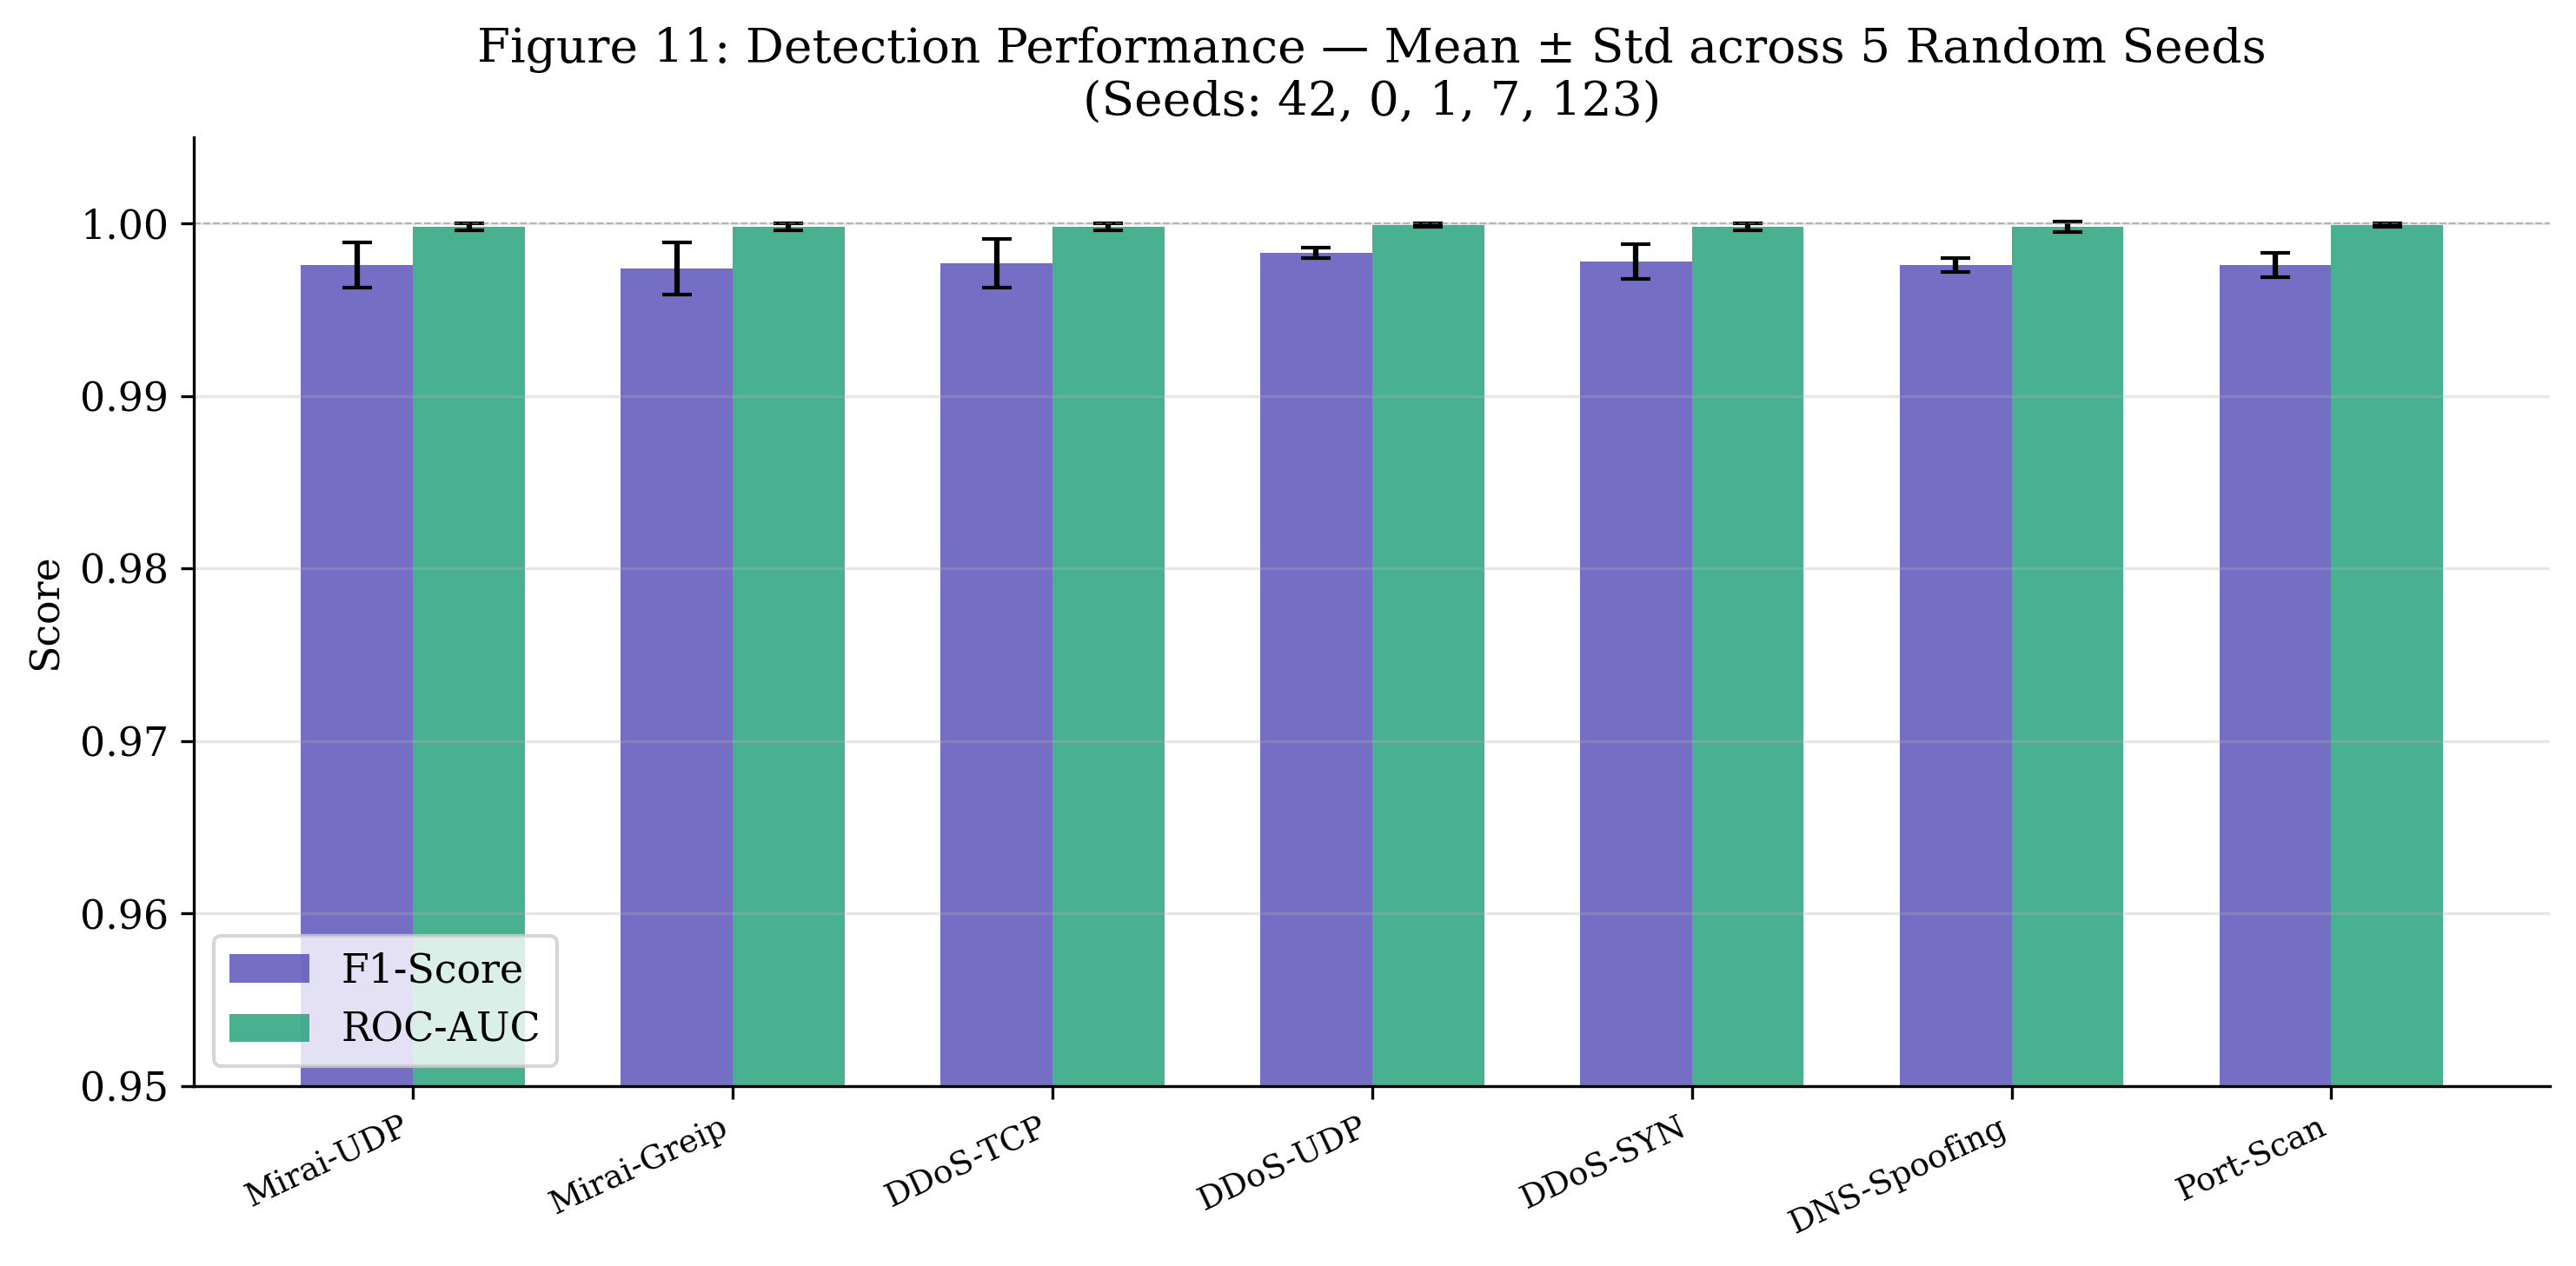

In [ ]:
import os
os.chdir('/content/drive/MyDrive/Colab')
import numpy as np, pandas as pd, json, os, warnings, torch, torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
import joblib, matplotlib
matplotlib.use("Agg"); import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
os.makedirs("figures", exist_ok=True)
os.makedirs("results_correct", exist_ok=True)

FEATURE_COLS = ["pkt_len_mean","pkt_len_std","inter_arrival_mean","inter_arrival_std",
                "flow_duration","pkt_rate","payload_entropy"]
ATTACK_FILES = {
    "Mirai-UDP":"Mirai-UDP-Plain.csv","Mirai-Greip":"Mirai-greip_Flood_Merge.csv",
    "DDoS-TCP":"DDos-TCP_Flood_Merge.csv","DDoS-UDP":"DDos-UDP_Flood-Merge.csv",
    "DDoS-SYN":"DDos-SYN_Flood_Merge.csv","DNS-Spoofing":"DNS_Spoofing.csv",
    "Port-Scan":"Recon-PortScan.csv",
}
SEEDS = [42, 0, 1, 7, 123]
EPOCHS=50; BATCH=256; LR=1e-3; SAMPLE=50000; BENIGN_CAP=100000

class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc_fc=nn.Linear(7,32); self.enc_mu=nn.Linear(32,8)
        self.enc_logv=nn.Linear(32,8); self.dec_fc=nn.Linear(8,32)
        self.dec_out=nn.Linear(32,7)
    def encode(self,x):
        h=torch.relu(self.enc_fc(x)); return self.enc_mu(h),self.enc_logv(h)
    def reparameterize(self,mu,lv):
        return mu+torch.exp(0.5*lv)*torch.randn_like(lv)
    def decode(self,z): return self.dec_out(torch.relu(self.dec_fc(z)))
    def forward(self,x):
        mu,lv=self.encode(x); return self.decode(self.reparameterize(mu,lv)),mu,lv
    @torch.no_grad()
    def recon_error(self,x):
        mu,lv=self.encode(x); xr=self.decode(self.reparameterize(mu,lv))
        return ((x-xr)**2).mean(dim=1).cpu().numpy()

def elbo(xr,x,mu,lv):
    return nn.functional.mse_loss(xr,x)-0.5*torch.mean(1+lv-mu.pow(2)-lv.exp())

def clean(X):
    for c in range(X.shape[1]):
        m=~np.isfinite(X[:,c])
        if m.any(): X[m,c]=np.nanmedian(X[~m,c])
    return X

all_seed_results = []

for seed in SEEDS:
    print(f"\n{'='*50}\nSEED {seed}\n{'='*50}")
    torch.manual_seed(seed); np.random.seed(seed)

    df_b=pd.read_csv("benign_train.csv").sample(min(BENIGN_CAP,145937),random_state=seed)
    X_b=clean(df_b[FEATURE_COLS].values.astype(np.float64))
    n=len(X_b); idx=np.random.permutation(n)
    n_tr=int(0.70*n); n_val=int(0.15*n)
    b_tr=X_b[idx[:n_tr]]; b_val=X_b[idx[n_tr:n_tr+n_val]]; b_te=X_b[idx[n_tr+n_val:]]

    lo=np.percentile(b_tr,1,axis=0); hi=np.percentile(b_tr,99,axis=0)
    scaler=StandardScaler().fit(np.clip(b_tr,lo,hi))
    def norm(X): return scaler.transform(np.clip(X,lo,hi))
    b_tr_n=norm(b_tr); b_val_n=norm(b_val); b_te_n=norm(b_te)

    model=VAE(); opt=optim.Adam(model.parameters(),lr=LR)
    sched=optim.lr_scheduler.StepLR(opt,step_size=20,gamma=0.5)
    loader=DataLoader(TensorDataset(torch.tensor(b_tr_n,dtype=torch.float32)),
                      batch_size=BATCH,shuffle=True)
    X_vl=torch.tensor(b_val_n,dtype=torch.float32)
    best_val=1e9
    for ep in range(1,EPOCHS+1):
        model.train()
        for (b,) in loader:
            opt.zero_grad(); xr,mu,lv=model(b); elbo(xr,b,mu,lv).backward(); opt.step()
        model.eval()
        with torch.no_grad():
            xr_v,mu_v,lv_v=model(X_vl); vl=elbo(xr_v,X_vl,mu_v,lv_v).item()
        if vl<best_val:
            best_val=vl; torch.save(model.state_dict(),"tmp_best.pth")
        sched.step()
    model.load_state_dict(torch.load("tmp_best.pth")); model.eval()

    val_errs=model.recon_error(X_vl)
    tau=float(np.percentile(val_errs,99))
    b_te_errs=model.recon_error(torch.tensor(b_te_n,dtype=torch.float32))
    b_te_preds=(b_te_errs>tau).astype(int)
    fpr=float(b_te_preds.mean())

    seed_result={"seed":seed,"tau":round(tau,4),"fpr":round(fpr,4),"per_attack":{}}
    print(f"  tau={tau:.4f}  test_fpr={fpr:.4f}")

    for name,fpath in ATTACK_FILES.items():
        if not os.path.exists(fpath): continue
        df_a=pd.read_csv(fpath)
        if len(df_a)>SAMPLE: df_a=df_a.sample(SAMPLE,random_state=seed)
        X_a=clean(df_a[FEATURE_COLS].values.astype(np.float64))
        X_a_n=norm(X_a)
        a_errs=model.recon_error(torch.tensor(X_a_n,dtype=torch.float32))
        a_preds=(a_errs>tau).astype(int)
        y_true=np.concatenate([np.zeros(len(b_te_n)),np.ones(len(X_a_n))])
        y_pred=np.concatenate([b_te_preds,a_preds])
        y_score=np.concatenate([b_te_errs,a_errs])
        bad=~np.isfinite(y_score); y_score[bad]=0.0
        prec=precision_score(y_true,y_pred,zero_division=0)
        rec=recall_score(y_true,y_pred,zero_division=0)
        f1=f1_score(y_true,y_pred,zero_division=0)
        auc=roc_auc_score(y_true,y_score)
        seed_result["per_attack"][name]={"precision":round(prec,4),"recall":round(rec,4),
                                          "f1":round(f1,4),"roc_auc":round(auc,4)}
        print(f"  {name:15s} P={prec:.4f} R={rec:.4f} F1={f1:.4f} AUC={auc:.4f}")
    all_seed_results.append(seed_result)

attack_names=list(ATTACK_FILES.keys())
metrics=["precision","recall","f1","roc_auc"]
summary={}
for name in attack_names:
    summary[name]={}
    for m in metrics:
        vals=[r["per_attack"].get(name,{}).get(m,np.nan) for r in all_seed_results]
        vals=[v for v in vals if not np.isnan(v)]
        summary[name][m]={"mean":round(float(np.mean(vals)),4),
                          "std":round(float(np.std(vals)),4)}

avg_summary={}
for m in metrics:
    vals=[summary[n][m]["mean"] for n in attack_names if n in summary]
    stds=[summary[n][m]["std"]  for n in attack_names if n in summary]
    avg_summary[m]={"mean":round(float(np.mean(vals)),4),
                    "std":round(float(np.mean(stds)),4)}

output={"seeds":SEEDS,"per_attack_summary":summary,"average":avg_summary,
        "raw_seed_results":all_seed_results}
with open("results_correct/multiseed_results.json","w") as f:
    json.dump(output,f,indent=2)
print("\n\nSUMMARY (mean ± std across 5 seeds):")
for name in attack_names:
    if name not in summary: continue
    s=summary[name]
    print(f"  {name:15s} F1={s['f1']['mean']:.4f}±{s['f1']['std']:.4f}  AUC={s['roc_auc']['mean']:.4f}±{s['roc_auc']['std']:.4f}")
print(f"\n  AVERAGE      F1={avg_summary['f1']['mean']:.4f}±{avg_summary['f1']['std']:.4f}  AUC={avg_summary['roc_auc']['mean']:.4f}±{avg_summary['roc_auc']['std']:.4f}")

fig,ax=plt.subplots(figsize=(10,5))
plt.rcParams.update({"font.family":"DejaVu Serif","font.size":11,"savefig.dpi":300})
x=np.arange(len(attack_names)); w=0.35
f1_means=[summary[n]["f1"]["mean"] for n in attack_names]
f1_stds =[summary[n]["f1"]["std"]  for n in attack_names]
auc_means=[summary[n]["roc_auc"]["mean"] for n in attack_names]
auc_stds =[summary[n]["roc_auc"]["std"]  for n in attack_names]
ax.bar(x-w/2,f1_means,w,yerr=f1_stds,capsize=4,label="F1-Score",
       color="#534AB7",alpha=0.8,error_kw={"linewidth":1.5})
ax.bar(x+w/2,auc_means,w,yerr=auc_stds,capsize=4,label="ROC-AUC",
       color="#1D9E75",alpha=0.8,error_kw={"linewidth":1.5})
ax.set_xticks(x); ax.set_xticklabels(attack_names,rotation=25,ha="right",fontsize=9)
ax.set_ylabel("Score"); ax.set_ylim([0.95,1.005])
ax.set_title("Figure 11: Detection Performance — Mean ± Std across 5 Random Seeds\n(Seeds: 42, 0, 1, 7, 123)")
ax.legend(); ax.axhline(1.0,color="gray",linewidth=0.5,linestyle="--",alpha=0.5)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.grid(axis="y",alpha=0.3)
plt.tight_layout()
fig.savefig("figures/Fig11_multiseed.png",dpi=300,bbox_inches="tight")
fig.savefig("figures/Fig11_multiseed.pdf",bbox_inches="tight")
plt.close()
print("\nFig11 saved. Paste results_correct/multiseed_results.json back.")
os.remove("tmp_best.pth")

# Cell-এর একদম শেষে এটা যোগ করুন
from IPython.display import Image, display
display(Image(filename="figures/Fig11_multiseed.png"))

## 8. Threshold Ablation & Precision-Recall Curves (`experiments/02_threshold_ablation.py`)
Computes precision-recall curves per attack type and sweeps the threshold percentile (90th–99.5th) to visualise the F1/Recall/FPR trade-off. Generates Fig. 12.

**Outputs:** `results_correct/threshold_ablation.json`, `figures/Fig12_pr_threshold.png`

Done — Fig12 + threshold_ablation.json saved

Threshold sweep results:
  90th pct  tau=0.2582  F1=0.9533  Recall=1.0000  FPR=0.0980
  91th pct  tau=0.2718  F1=0.9574  Recall=1.0000  FPR=0.0890
  92th pct  tau=0.2925  F1=0.9613  Recall=1.0000  FPR=0.0805
  93th pct  tau=0.3116  F1=0.9660  Recall=1.0000  FPR=0.0705
  94th pct  tau=0.3418  F1=0.9697  Recall=1.0000  FPR=0.0625
  95th pct  tau=0.3774  F1=0.9756  Recall=1.0000  FPR=0.0500
  96th pct  tau=0.4227  F1=0.9804  Recall=1.0000  FPR=0.0400
  97th pct  tau=0.4759  F1=0.9855  Recall=1.0000  FPR=0.0295
  98th pct  tau=0.5592  F1=0.9908  Recall=1.0000  FPR=0.0185
  99th pct  tau=0.7315  F1=0.9948  Recall=1.0000  FPR=0.0105
  99.5th pct  tau=1.0625  F1=0.9978  Recall=1.0000  FPR=0.0045


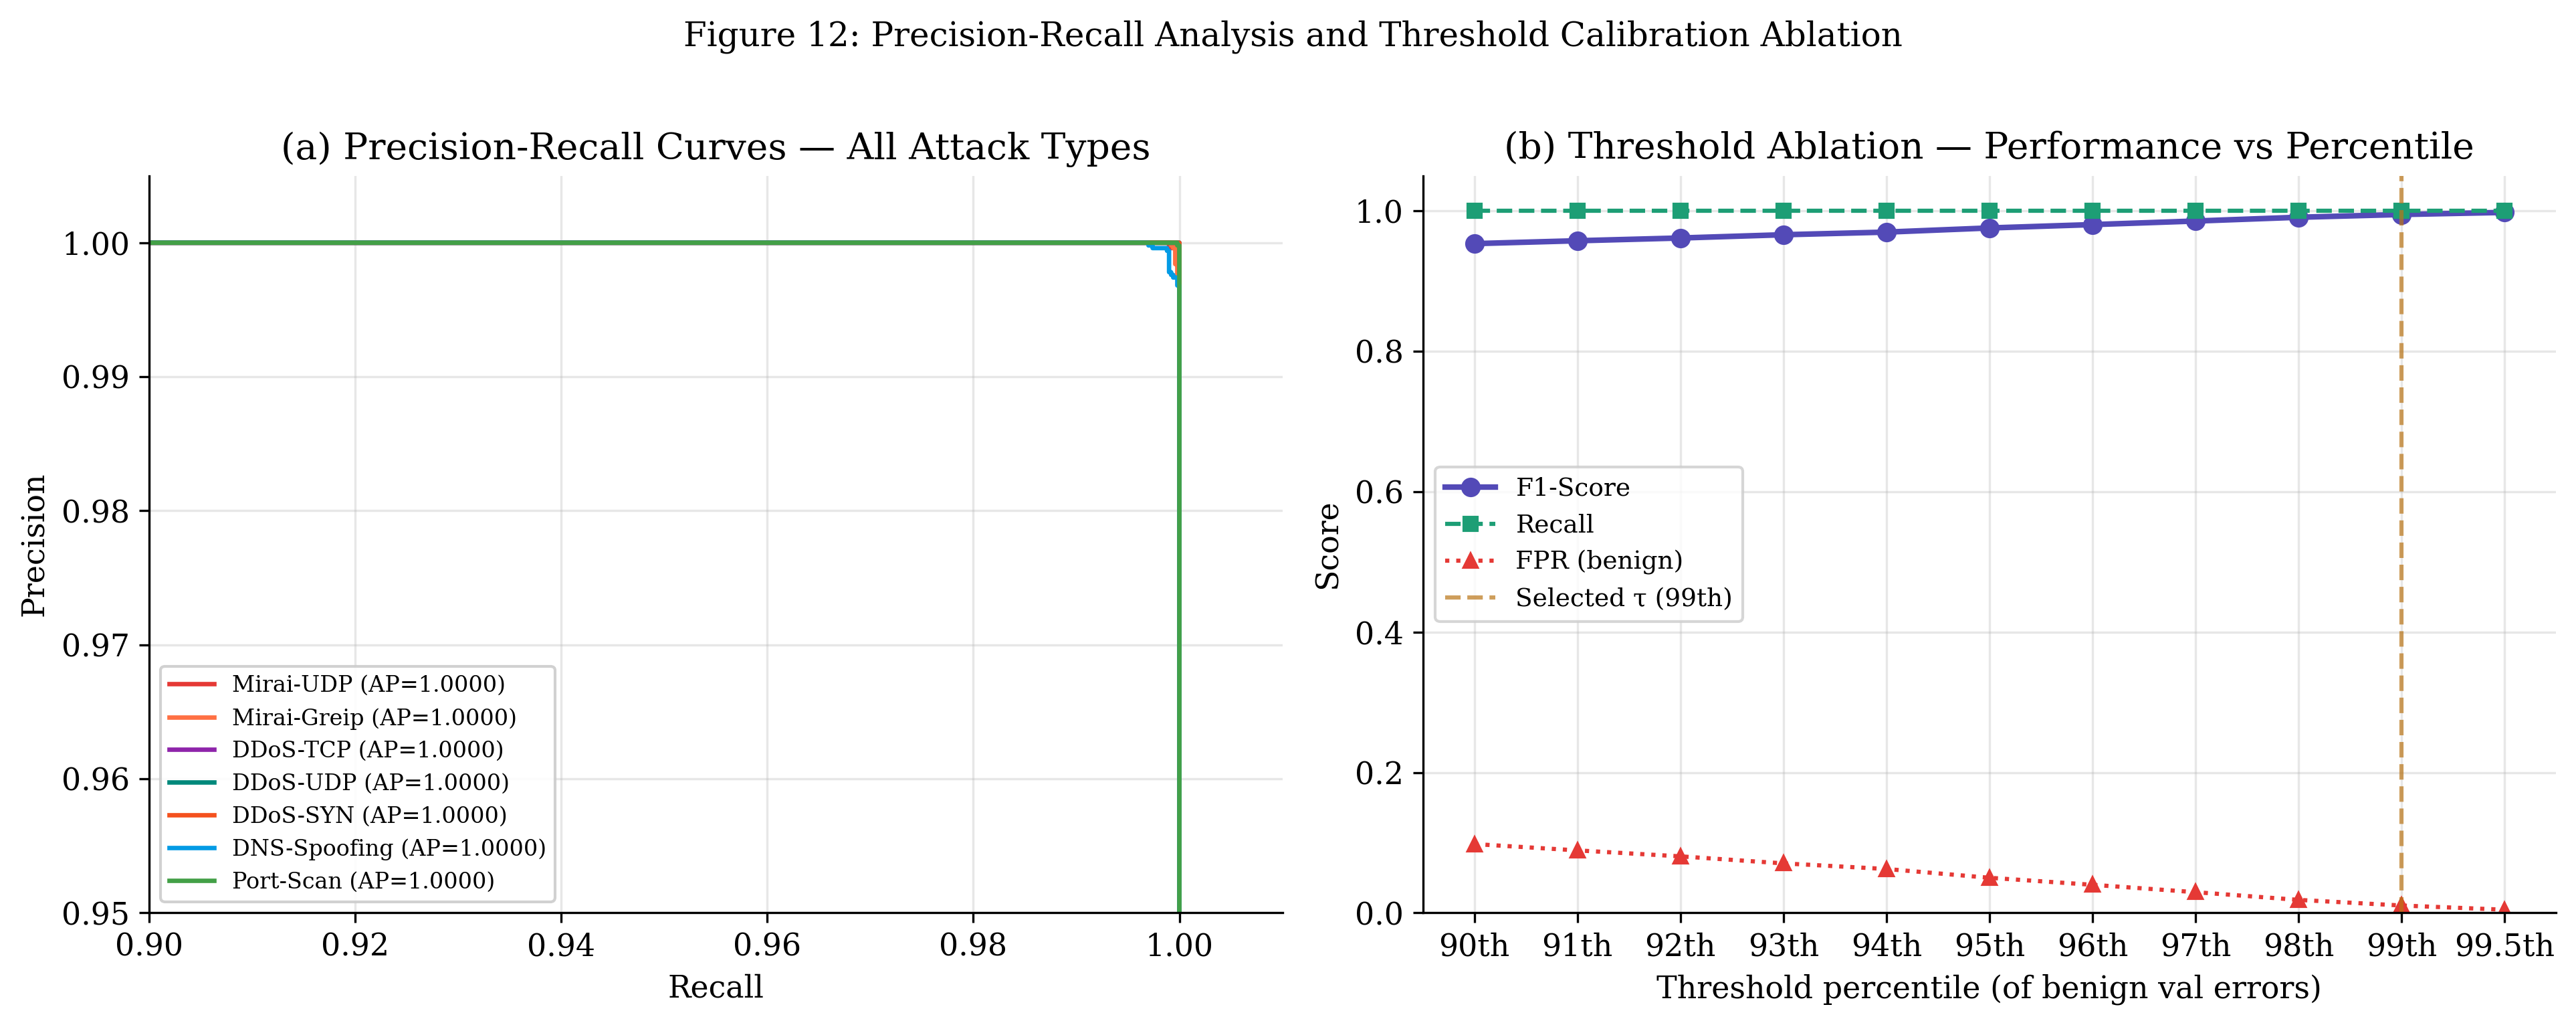

In [ ]:
import os
os.chdir('/content/drive/MyDrive/Colab')
import numpy as np, pandas as pd, json, os, warnings, torch, torch.nn as nn
import matplotlib; matplotlib.use("Agg"); import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score, f1_score
from sklearn.metrics import precision_score, recall_score
import joblib; warnings.filterwarnings("ignore")
os.makedirs("figures",exist_ok=True)

FEATURE_COLS=["pkt_len_mean","pkt_len_std","inter_arrival_mean","inter_arrival_std",
              "flow_duration","pkt_rate","payload_entropy"]
ATTACK_FILES={"Mirai-UDP":"Mirai-UDP-Plain.csv","Mirai-Greip":"Mirai-greip_Flood_Merge.csv",
              "DDoS-TCP":"DDos-TCP_Flood_Merge.csv","DDoS-UDP":"DDos-UDP_Flood-Merge.csv",
              "DDoS-SYN":"DDos-SYN_Flood_Merge.csv","DNS-Spoofing":"DNS_Spoofing.csv",
              "Port-Scan":"Recon-PortScan.csv"}
COLORS={"Mirai-UDP":"#E53935","Mirai-Greip":"#FF7043","DDoS-TCP":"#8E24AA",
        "DDoS-UDP":"#00897B","DDoS-SYN":"#F4511E","DNS-Spoofing":"#039BE5","Port-Scan":"#43A047"}

class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc_fc=nn.Linear(7,32); self.enc_mu=nn.Linear(32,8)
        self.enc_logv=nn.Linear(32,8); self.dec_fc=nn.Linear(8,32); self.dec_out=nn.Linear(32,7)
    def encode(self,x):
        h=torch.relu(self.enc_fc(x)); return self.enc_mu(h),self.enc_logv(h)
    def reparameterize(self,mu,lv): return mu+torch.exp(0.5*lv)*torch.randn_like(lv)
    def decode(self,z): return self.dec_out(torch.relu(self.dec_fc(z)))
    @torch.no_grad()
    def recon_error(self,x):
        mu,lv=self.encode(x); xr=self.decode(self.reparameterize(mu,lv))
        return ((x-xr)**2).mean(dim=1).cpu().numpy()

model=VAE()
model.load_state_dict(torch.load("results_correct/vae_best.pth",map_location="cpu"))
model.eval()
scaler=joblib.load("results_correct/scaler_final.save")
clip_lo=np.load("results_correct/clip_low.npy")
clip_hi=np.load("results_correct/clip_high.npy")
tau=float(np.load("results_correct/threshold.npy"))
SEED=42; np.random.seed(SEED); torch.manual_seed(SEED)

def clean_norm(X):
    for c in range(X.shape[1]):
        m=~np.isfinite(X[:,c])
        if m.any(): X[m,c]=np.nanmedian(X[~m,c])
    return scaler.transform(np.clip(X,clip_lo,clip_hi))

df_b=pd.read_csv("benign_train.csv")
idx=np.random.permutation(len(df_b))
b_te_raw=df_b[FEATURE_COLS].values.astype(np.float64)[idx[85000:]]
b_te_n=clean_norm(b_te_raw)
b_te_errs=model.recon_error(torch.tensor(b_te_n[:5000],dtype=torch.float32))

attack_errs={}
for name,fpath in ATTACK_FILES.items():
    if not os.path.exists(fpath): continue
    df=pd.read_csv(fpath)
    if len(df)>5000: df=df.sample(5000,random_state=SEED)
    X=clean_norm(df[FEATURE_COLS].values.astype(np.float64))
    attack_errs[name]=model.recon_error(torch.tensor(X,dtype=torch.float32))

plt.rcParams.update({"font.family":"DejaVu Serif","font.size":11,
                     "savefig.dpi":300,"axes.spines.top":False,"axes.spines.right":False})
fig,axes=plt.subplots(1,2,figsize=(13,5))

ax=axes[0]
ap_scores={}
for name,a_errs in attack_errs.items():
    n_b=min(len(b_te_errs),len(a_errs))
    y_true=np.concatenate([np.zeros(n_b),np.ones(len(a_errs))])
    y_score=np.concatenate([b_te_errs[:n_b],a_errs])
    bad=~np.isfinite(y_score); y_score[bad]=0.0
    prec,rec,_=precision_recall_curve(y_true,y_score)
    ap=average_precision_score(y_true,y_score)
    ap_scores[name]=round(ap,4)
    ax.plot(rec,prec,color=COLORS[name],linewidth=1.6,label=f"{name} (AP={ap:.4f})")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("(a) Precision-Recall Curves — All Attack Types")
ax.legend(fontsize=8,frameon=True,framealpha=0.9)
ax.set_xlim([0.9,1.01]); ax.set_ylim([0.95,1.005])
ax.grid(alpha=0.3)

ax2=axes[1]
pct_values=list(range(90,100))+[99.5]
all_b=b_te_errs[:2000]
all_a=np.concatenate(list(attack_errs.values()))[:2000]
y_true_all=np.concatenate([np.zeros(len(all_b)),np.ones(len(all_a))])
y_score_all=np.concatenate([all_b,all_a])

prec_vals=[]; rec_vals=[]; f1_vals=[]; fpr_vals=[]
tau_vals=[]
for pct in pct_values:
    t=float(np.percentile(b_te_errs,pct))
    tau_vals.append(round(t,4))
    preds=(y_score_all>t).astype(int)
    prec_vals.append(precision_score(y_true_all,preds,zero_division=0))
    rec_vals.append(recall_score(y_true_all,preds,zero_division=0))
    f1_vals.append(f1_score(y_true_all,preds,zero_division=0))
    fpr_vals.append(float((all_b>t).mean()))

pct_labels=[f"{p}th" for p in pct_values]
ax2.plot(pct_labels,f1_vals,"o-",color="#534AB7",linewidth=2,markersize=6,label="F1-Score")
ax2.plot(pct_labels,rec_vals,"s--",color="#1D9E75",linewidth=1.5,markersize=5,label="Recall")
ax2.plot(pct_labels,fpr_vals,"^:",color="#E53935",linewidth=1.5,markersize=5,label="FPR (benign)")

idx99=pct_labels.index("99th")
ax2.axvline(idx99,color="#BA7517",linewidth=1.5,linestyle="--",alpha=0.7,label="Selected τ (99th)")
ax2.set_xlabel("Threshold percentile (of benign val errors)")
ax2.set_ylabel("Score")
ax2.set_title("(b) Threshold Ablation — Performance vs Percentile")
ax2.legend(fontsize=9,frameon=True); ax2.grid(alpha=0.3)
ax2.set_ylim([0,1.05])

fig.suptitle("Figure 12: Precision-Recall Analysis and Threshold Calibration Ablation",
             fontsize=12,y=1.01)
plt.tight_layout()
fig.savefig("figures/Fig12_pr_threshold.png",dpi=300,bbox_inches="tight")
fig.savefig("figures/Fig12_pr_threshold.pdf",bbox_inches="tight")
plt.close()

ablation_out={"threshold_sweep":[{"percentile":p,"tau":t,"f1":round(f,4),
              "recall":round(r,4),"fpr":round(fp,4)}
              for p,t,f,r,fp in zip(pct_values,tau_vals,f1_vals,rec_vals,fpr_vals)],
              "average_precision_per_attack":ap_scores}
with open("results_correct/threshold_ablation.json","w") as f:
    json.dump(ablation_out,f,indent=2)
print("Done — Fig12 + threshold_ablation.json saved")
print("\nThreshold sweep results:")
for row in ablation_out["threshold_sweep"]:
    print(f"  {row['percentile']}th pct  tau={row['tau']:.4f}  F1={row['f1']:.4f}  Recall={row['recall']:.4f}  FPR={row['fpr']:.4f}")

# Cell-এর একদম শেষে এটা যোগ করুন
from IPython.display import Image, display
display(Image(filename="figures/Fig12_pr_threshold.png"))

## 9. Unsupervised Baseline Comparison (`experiments/03_baselines.py`)
Trains and evaluates three additional unsupervised baselines (One-Class SVM, Local Outlier Factor, LSTM Autoencoder) under identical benign-only training conditions for comparison against GenEdgeGuard.

**Outputs:** `results_correct/strong_baselines.json`

In [ ]:
import os
os.chdir('/content/drive/MyDrive/Colab')

import numpy as np, pandas as pd, torch, torch.nn as nn, joblib, os, json, warnings, time
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
FEATURE_COLS = ["pkt_len_mean","pkt_len_std","inter_arrival_mean","inter_arrival_std",
                "flow_duration","pkt_rate","payload_entropy"]
ATTACK_FILES = {
    "Mirai-UDP":"Mirai-UDP-Plain.csv","Mirai-Greip":"Mirai-greip_Flood_Merge.csv",
    "DDoS-TCP":"DDos-TCP_Flood_Merge.csv","DDoS-UDP":"DDos-UDP_Flood-Merge.csv",
    "DDoS-SYN":"DDos-SYN_Flood_Merge.csv","DNS-Spoofing":"DNS_Spoofing.csv",
    "Port-Scan":"Recon-PortScan.csv",
}

scaler = joblib.load("results_correct/scaler_final.save")
clip_lo = np.load("results_correct/clip_low.npy")
clip_hi = np.load("results_correct/clip_high.npy")

def clean_norm(X):
    for c in range(X.shape[1]):
        m = ~np.isfinite(X[:,c])
        if m.any(): X[m,c] = np.nanmedian(X[~m,c])
    return scaler.transform(np.clip(X, clip_lo, clip_hi))

df_b = pd.read_csv("benign_train.csv")
idx = np.random.permutation(len(df_b))
b_tr_n  = clean_norm(df_b[FEATURE_COLS].values.astype(np.float64)[idx[:70000]])
b_val_n = clean_norm(df_b[FEATURE_COLS].values.astype(np.float64)[idx[70000:85000]])
b_te_n  = clean_norm(df_b[FEATURE_COLS].values.astype(np.float64)[idx[85000:]])

TRAIN_SUB = 5000
b_tr_sub = b_tr_n[np.random.choice(len(b_tr_n), TRAIN_SUB, replace=False)]

results = {}

print("="*60)
print("Training One-Class SVM...")
t0 = time.time()
ocsvm = OneClassSVM(kernel="rbf", nu=0.01, gamma="scale")
ocsvm.fit(b_tr_sub)
print(f"  Trained in {time.time()-t0:.1f}s")

val_scores = -ocsvm.decision_function(b_val_n)
tau_svm = np.percentile(val_scores, 99)
te_scores = -ocsvm.decision_function(b_te_n)
te_preds = (te_scores > tau_svm).astype(int)

print(f"\n{'OCSVM Attack':15s} {'Prec':>7} {'Rec':>7} {'F1':>7} {'AUC':>7}")
ocsvm_f1s = []
for name, fpath in ATTACK_FILES.items():
    if not os.path.exists(fpath): continue
    df = pd.read_csv(fpath); n = min(10000, len(df)); df = df.sample(n, random_state=SEED)
    X_n = clean_norm(df[FEATURE_COLS].values.astype(np.float64))
    a_scores = -ocsvm.decision_function(X_n)
    a_preds = (a_scores > tau_svm).astype(int)
    y_true = np.concatenate([np.zeros(len(te_scores)), np.ones(len(a_scores))])
    y_pred = np.concatenate([te_preds, a_preds])
    y_score = np.concatenate([te_scores, a_scores])
    p = precision_score(y_true, y_pred, zero_division=0)
    r = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_score)
    ocsvm_f1s.append(f1)
    print(f"  {name:15s} {p:>7.4f} {r:>7.4f} {f1:>7.4f} {auc:>7.4f}")
results["OneClassSVM"] = {"mean_f1": round(np.mean(ocsvm_f1s),4), "fpr": round(te_preds.mean(),4)}
print(f"  Mean F1: {np.mean(ocsvm_f1s):.4f}  FPR: {te_preds.mean()*100:.2f}%")

print("\n" + "="*60)
print("Training Local Outlier Factor (novelty=True)...")
t0 = time.time()
lof = LocalOutlierFactor(n_neighbors=20, novelty=True, contamination=0.01)
lof.fit(b_tr_sub)
print(f"  Trained in {time.time()-t0:.1f}s")

val_scores_lof = -lof.decision_function(b_val_n)
tau_lof = np.percentile(val_scores_lof, 99)
te_scores_lof = -lof.decision_function(b_te_n)
te_preds_lof = (te_scores_lof > tau_lof).astype(int)

print(f"\n{'LOF Attack':15s} {'Prec':>7} {'Rec':>7} {'F1':>7} {'AUC':>7}")
lof_f1s = []
for name, fpath in ATTACK_FILES.items():
    if not os.path.exists(fpath): continue
    df = pd.read_csv(fpath); n = min(10000, len(df)); df = df.sample(n, random_state=SEED)
    X_n = clean_norm(df[FEATURE_COLS].values.astype(np.float64))
    a_scores = -lof.decision_function(X_n)
    a_preds = (a_scores > tau_lof).astype(int)
    y_true = np.concatenate([np.zeros(len(te_scores_lof)), np.ones(len(a_scores))])
    y_pred = np.concatenate([te_preds_lof, a_preds])
    y_score = np.concatenate([te_scores_lof, a_scores])
    p = precision_score(y_true, y_pred, zero_division=0)
    r = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_score)
    lof_f1s.append(f1)
    print(f"  {name:15s} {p:>7.4f} {r:>7.4f} {f1:>7.4f} {auc:>7.4f}")
results["LOF"] = {"mean_f1": round(np.mean(lof_f1s),4), "fpr": round(te_preds_lof.mean(),4)}
print(f"  Mean F1: {np.mean(lof_f1s):.4f}  FPR: {te_preds_lof.mean()*100:.2f}%")

print("\n" + "="*60)
print("Training LSTM Autoencoder...")

class LSTMAutoencoder(nn.Module):
    def __init__(self, n_features=7, hidden=16):
        super().__init__()
        self.encoder = nn.LSTM(n_features, hidden, batch_first=True)
        self.decoder = nn.LSTM(hidden, n_features, batch_first=True)
    def forward(self, x):
        h, (hn, cn) = self.encoder(x)
        out, _ = self.decoder(h)
        return out

lstm_ae = LSTMAutoencoder()
optimizer = torch.optim.Adam(lstm_ae.parameters(), lr=0.001)
criterion = nn.MSELoss()

X_train_t = torch.tensor(b_tr_n, dtype=torch.float32).unsqueeze(1)
n_epochs = 30
batch_size = 256
t0 = time.time()
for epoch in range(n_epochs):
    perm = torch.randperm(len(X_train_t))
    total_loss = 0
    for i in range(0, len(X_train_t), batch_size):
        batch = X_train_t[perm[i:i+batch_size]]
        optimizer.zero_grad()
        recon = lstm_ae(batch)
        loss = criterion(recon, batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if epoch % 10 == 0:
        print(f"  Epoch {epoch}: loss={total_loss/len(X_train_t)*batch_size:.4f}")
print(f"  Trained in {time.time()-t0:.1f}s")

def lstm_error(X_n):
    with torch.no_grad():
        X_t = torch.tensor(X_n, dtype=torch.float32).unsqueeze(1)
        recon = lstm_ae(X_t)
        err = ((X_t - recon) ** 2).mean(dim=(1,2)).numpy()
    return err

val_err_lstm = lstm_error(b_val_n)
tau_lstm = np.percentile(val_err_lstm, 99)
te_err_lstm = lstm_error(b_te_n)
te_preds_lstm = (te_err_lstm > tau_lstm).astype(int)

print(f"\n{'LSTM-AE Attack':15s} {'Prec':>7} {'Rec':>7} {'F1':>7} {'AUC':>7}")
lstm_f1s = []
for name, fpath in ATTACK_FILES.items():
    if not os.path.exists(fpath): continue
    df = pd.read_csv(fpath); n = min(10000, len(df)); df = df.sample(n, random_state=SEED)
    X_n = clean_norm(df[FEATURE_COLS].values.astype(np.float64))
    a_err = lstm_error(X_n)
    a_preds = (a_err > tau_lstm).astype(int)
    y_true = np.concatenate([np.zeros(len(te_err_lstm)), np.ones(len(a_err))])
    y_pred = np.concatenate([te_preds_lstm, a_preds])
    y_score = np.concatenate([te_err_lstm, a_err])
    p = precision_score(y_true, y_pred, zero_division=0)
    r = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_score)
    lstm_f1s.append(f1)
    print(f"  {name:15s} {p:>7.4f} {r:>7.4f} {f1:>7.4f} {auc:>7.4f}")
results["LSTM_Autoencoder"] = {"mean_f1": round(np.mean(lstm_f1s),4), "fpr": round(te_preds_lstm.mean(),4)}
print(f"  Mean F1: {np.mean(lstm_f1s):.4f}  FPR: {te_preds_lstm.mean()*100:.2f}%")

print("\n" + "="*60)
print("SUMMARY — All baselines vs GenEdgeGuard")
print("="*60)
print(f"  GenEdgeGuard (VAE, ours):  F1=0.9984  FPR=0.98%")
for name, r in results.items():
    print(f"  {name:20s}  F1={r['mean_f1']:.4f}  FPR={r['fpr']*100:.2f}%")

with open("results_correct/strong_baselines.json", "w") as f:
    json.dump(results, f, indent=2)
print("\n✓ Saved to results_correct/strong_baselines.json")



Training One-Class SVM...
  Trained in 0.0s

OCSVM Attack       Prec     Rec      F1     AUC
  Mirai-UDP        0.9432  1.0000  0.9708  1.0000
  Mirai-Greip      0.9432  1.0000  0.9708  1.0000
  DDoS-TCP         0.9432  1.0000  0.9708  1.0000
  DDoS-UDP         0.9432  1.0000  0.9708  1.0000
  DDoS-SYN         0.9432  1.0000  0.9708  1.0000
  DNS-Spoofing     0.9432  1.0000  0.9708  1.0000
  Port-Scan        0.9432  1.0000  0.9708  1.0000
  Mean F1: 0.9708  FPR: 0.99%

Training Local Outlier Factor (novelty=True)...
  Trained in 0.1s

LOF Attack         Prec     Rec      F1     AUC
  Mirai-UDP        0.0000  0.0000  0.0000  0.9304
  Mirai-Greip      0.0000  0.0000  0.0000  0.9301
  DDoS-TCP         0.0000  0.0000  0.0000  0.9276
  DDoS-UDP         0.0000  0.0000  0.0000  0.9320
  DDoS-SYN         0.0000  0.0000  0.0000  0.9276
  DNS-Spoofing     0.0000  0.0000  0.0000  0.9397
  Port-Scan        0.0000  0.0000  0.0000  0.9541
  Mean F1: 0.0000  FPR: 1.06%

Training LSTM Autoencoder...
 

## 10. SHAP Stability Analysis (`experiments/04_shap_analysis.py`)
Computes Kernel SHAP feature attributions across 5 random seeds to assess ranking stability of the 7 input features.

**Outputs:** `results_correct/shap_stability.json`

In [ ]:
import os
os.chdir('/content/drive/MyDrive/Colab')
import numpy as np, pandas as pd, torch, torch.nn as nn, joblib, os, json, warnings
import shap
warnings.filterwarnings("ignore")

FEATURE_COLS = ["pkt_len_mean","pkt_len_std","inter_arrival_mean","inter_arrival_std",
                "flow_duration","pkt_rate","payload_entropy"]

class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc_fc=nn.Linear(7,32); self.enc_mu=nn.Linear(32,8)
        self.enc_logv=nn.Linear(32,8); self.dec_fc=nn.Linear(8,32); self.dec_out=nn.Linear(32,7)
    def encode(self,x):
        h=torch.relu(self.enc_fc(x)); return self.enc_mu(h),self.enc_logv(h)
    def decode(self,z): return self.dec_out(torch.relu(self.dec_fc(z)))

model = VAE()
model.load_state_dict(torch.load("results_correct/vae_best.pth", map_location="cpu"))
model.eval()
scaler = joblib.load("results_correct/scaler_final.save")
clip_lo = np.load("results_correct/clip_low.npy")
clip_hi = np.load("results_correct/clip_high.npy")

def clean_norm(X):
    for c in range(X.shape[1]):
        m = ~np.isfinite(X[:,c])
        if m.any(): X[m,c] = np.nanmedian(X[~m,c])
    return scaler.transform(np.clip(X, clip_lo, clip_hi))

def score_fn(X):
    with torch.no_grad():
        X_t = torch.tensor(X.astype(np.float32))
        mu, _ = model.encode(X_t)
        xr = model.decode(mu)
        return ((X_t - xr) ** 2).mean(dim=1).numpy()

df_b = pd.read_csv("benign_train.csv")
all_benign = clean_norm(df_b[FEATURE_COLS].values.astype(np.float64))

SEEDS = [42, 0, 1, 7, 123]
N_BACKGROUND = 200
N_EXPLAIN = 50

df_attack = pd.read_csv("DDos-TCP_Flood_Merge.csv")

print("="*70)
print("SHAP STABILITY ANALYSIS — 5 seeds, different background/explain samples")
print("="*70)

all_shap_results = {}

for seed in SEEDS:
    np.random.seed(seed)
    print(f"\n--- Seed {seed} ---")

    bg_idx = np.random.choice(len(all_benign), N_BACKGROUND, replace=False)
    background = all_benign[bg_idx]

    explain_idx = np.random.choice(len(df_attack), N_EXPLAIN, replace=False)
    explain_raw = df_attack[FEATURE_COLS].values.astype(np.float64)[explain_idx]
    explain_data = clean_norm(explain_raw)

    explainer = shap.KernelExplainer(score_fn, background)
    shap_values = explainer.shap_values(explain_data, nsamples=100, silent=True)

    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    all_shap_results[seed] = dict(zip(FEATURE_COLS, mean_abs_shap.round(4)))

    ranking = sorted(zip(FEATURE_COLS, mean_abs_shap), key=lambda x: -x[1])
    rank_str = " > ".join([f"{f}({v:.3f})" for f, v in ranking[:3]])
    print(f"  Top-3: {rank_str}")

print("\n" + "="*70)
print("STABILITY SUMMARY (mean ± std across 5 seeds)")
print("="*70)
print(f"{'Feature':<20} {'Mean |SHAP|':>12} {'Std':>10} {'CV%':>8} {'Rank stable?':>14}")

stability_summary = {}
rank_lists = []
for seed in SEEDS:
    ranking = sorted(all_shap_results[seed].items(), key=lambda x: -x[1])
    rank_lists.append([f for f, v in ranking])

for feat in FEATURE_COLS:
    vals = [all_shap_results[s][feat] for s in SEEDS]
    mean_v = np.mean(vals)
    std_v = np.std(vals)
    cv = (std_v / mean_v * 100) if mean_v > 0 else 0
    ranks_for_feat = [rank_lists[i].index(feat) + 1 for i in range(len(SEEDS))]
    rank_stable = (max(ranks_for_feat) - min(ranks_for_feat)) <= 1
    stability_summary[feat] = {
        "mean": round(mean_v, 4), "std": round(std_v, 4),
        "cv_pct": round(cv, 2), "rank_range": [min(ranks_for_feat), max(ranks_for_feat)],
        "rank_stable": bool(rank_stable)
    }
    print(f"{feat:<20} {mean_v:>12.4f} {std_v:>10.4f} {cv:>7.2f}% {'Yes' if rank_stable else 'No':>14}")

with open("results_correct/shap_stability.json", "w") as f:
    json.dump(stability_summary, f, indent=2)

print("\n✓ Saved to results_correct/shap_stability.json")



SHAP STABILITY ANALYSIS — 5 seeds, different background/explain samples

--- Seed 42 ---


  Top-3: pkt_len_mean(5.921) > inter_arrival_mean(3.213) > inter_arrival_std(0.584)

--- Seed 0 ---


  Top-3: pkt_len_mean(5.957) > inter_arrival_mean(3.187) > inter_arrival_std(0.585)

--- Seed 1 ---


  Top-3: pkt_len_mean(5.680) > inter_arrival_mean(3.423) > inter_arrival_std(0.710)

--- Seed 7 ---


  Top-3: pkt_len_mean(5.715) > inter_arrival_mean(3.403) > inter_arrival_std(0.663)

--- Seed 123 ---


  Top-3: pkt_len_mean(5.753) > inter_arrival_mean(3.436) > inter_arrival_std(0.674)

STABILITY SUMMARY (mean ± std across 5 seeds)
Feature               Mean |SHAP|        Std      CV%   Rank stable?
pkt_len_mean               5.8053     0.1123    1.94%            Yes
pkt_len_std                0.1155     0.0222   19.25%            Yes
inter_arrival_mean         3.3323     0.1089    3.27%            Yes
inter_arrival_std          0.6435     0.0503    7.82%            Yes
flow_duration              0.2394     0.0391   16.33%            Yes
pkt_rate                   0.1565     0.0711   45.42%             No
payload_entropy            0.0796     0.0084   10.62%            Yes

✓ Saved to results_correct/shap_stability.json


## 11. Adversarial Evaluation — FGSM/PGD (`experiments/05_adversarial_eval.py`)
Evaluates adversarial robustness under FGSM (ε=0.1, 0.3) and PGD (ε=0.3, 20 steps) attacks in the feature space. Also reproduces the full detection table and threshold ablation. Generates Fig. 15.

**Outputs:** `results_correct/final_results_v3.json`, `figures/Fig15_recall_explanation.png`

Canonical tau (deterministic): 0.3810
Test benign FPR: 0.94%

DETECTION PERFORMANCE (deterministic tau)
Attack             Prec     Rec      F1     AUC   E_mean   E_min    E/τ
  Mirai-UDP        0.9887  1.0000  0.9943  1.0000   9.5851  2.6979  25.16×
  Mirai-Greip      0.9887  1.0000  0.9943  1.0000   9.8746  2.6973  25.92×
  DDoS-TCP         0.9887  1.0000  0.9943  1.0000   8.1948  4.0875  21.51×
  DDoS-UDP         0.9887  1.0000  0.9943  1.0000  11.8648  2.7331  31.14×
  DDoS-SYN         0.9887  1.0000  0.9943  1.0000   8.1501  4.6853  21.39×
  DNS-Spoofing     0.9852  1.0000  0.9926  1.0000  10.3813  2.6937  27.25×
  Port-Scan        0.9859  1.0000  0.9929  1.0000  10.4952  2.6958  27.54×
  AVERAGE          0.9878  1.0000  0.9939  1.0000

Test benign FPR: 0.94%

ADVERSARIAL EVASION (deterministic scoring)
Attack           Orig DR   FGSM.1   FGSM.3   PGD.3    ASR
  Mirai-UDP         1.0000   1.0000   1.0000  1.0000 0.0000
  Mirai-Greip       1.0000   1.0000   1.0000  1.0000 0.0000
  

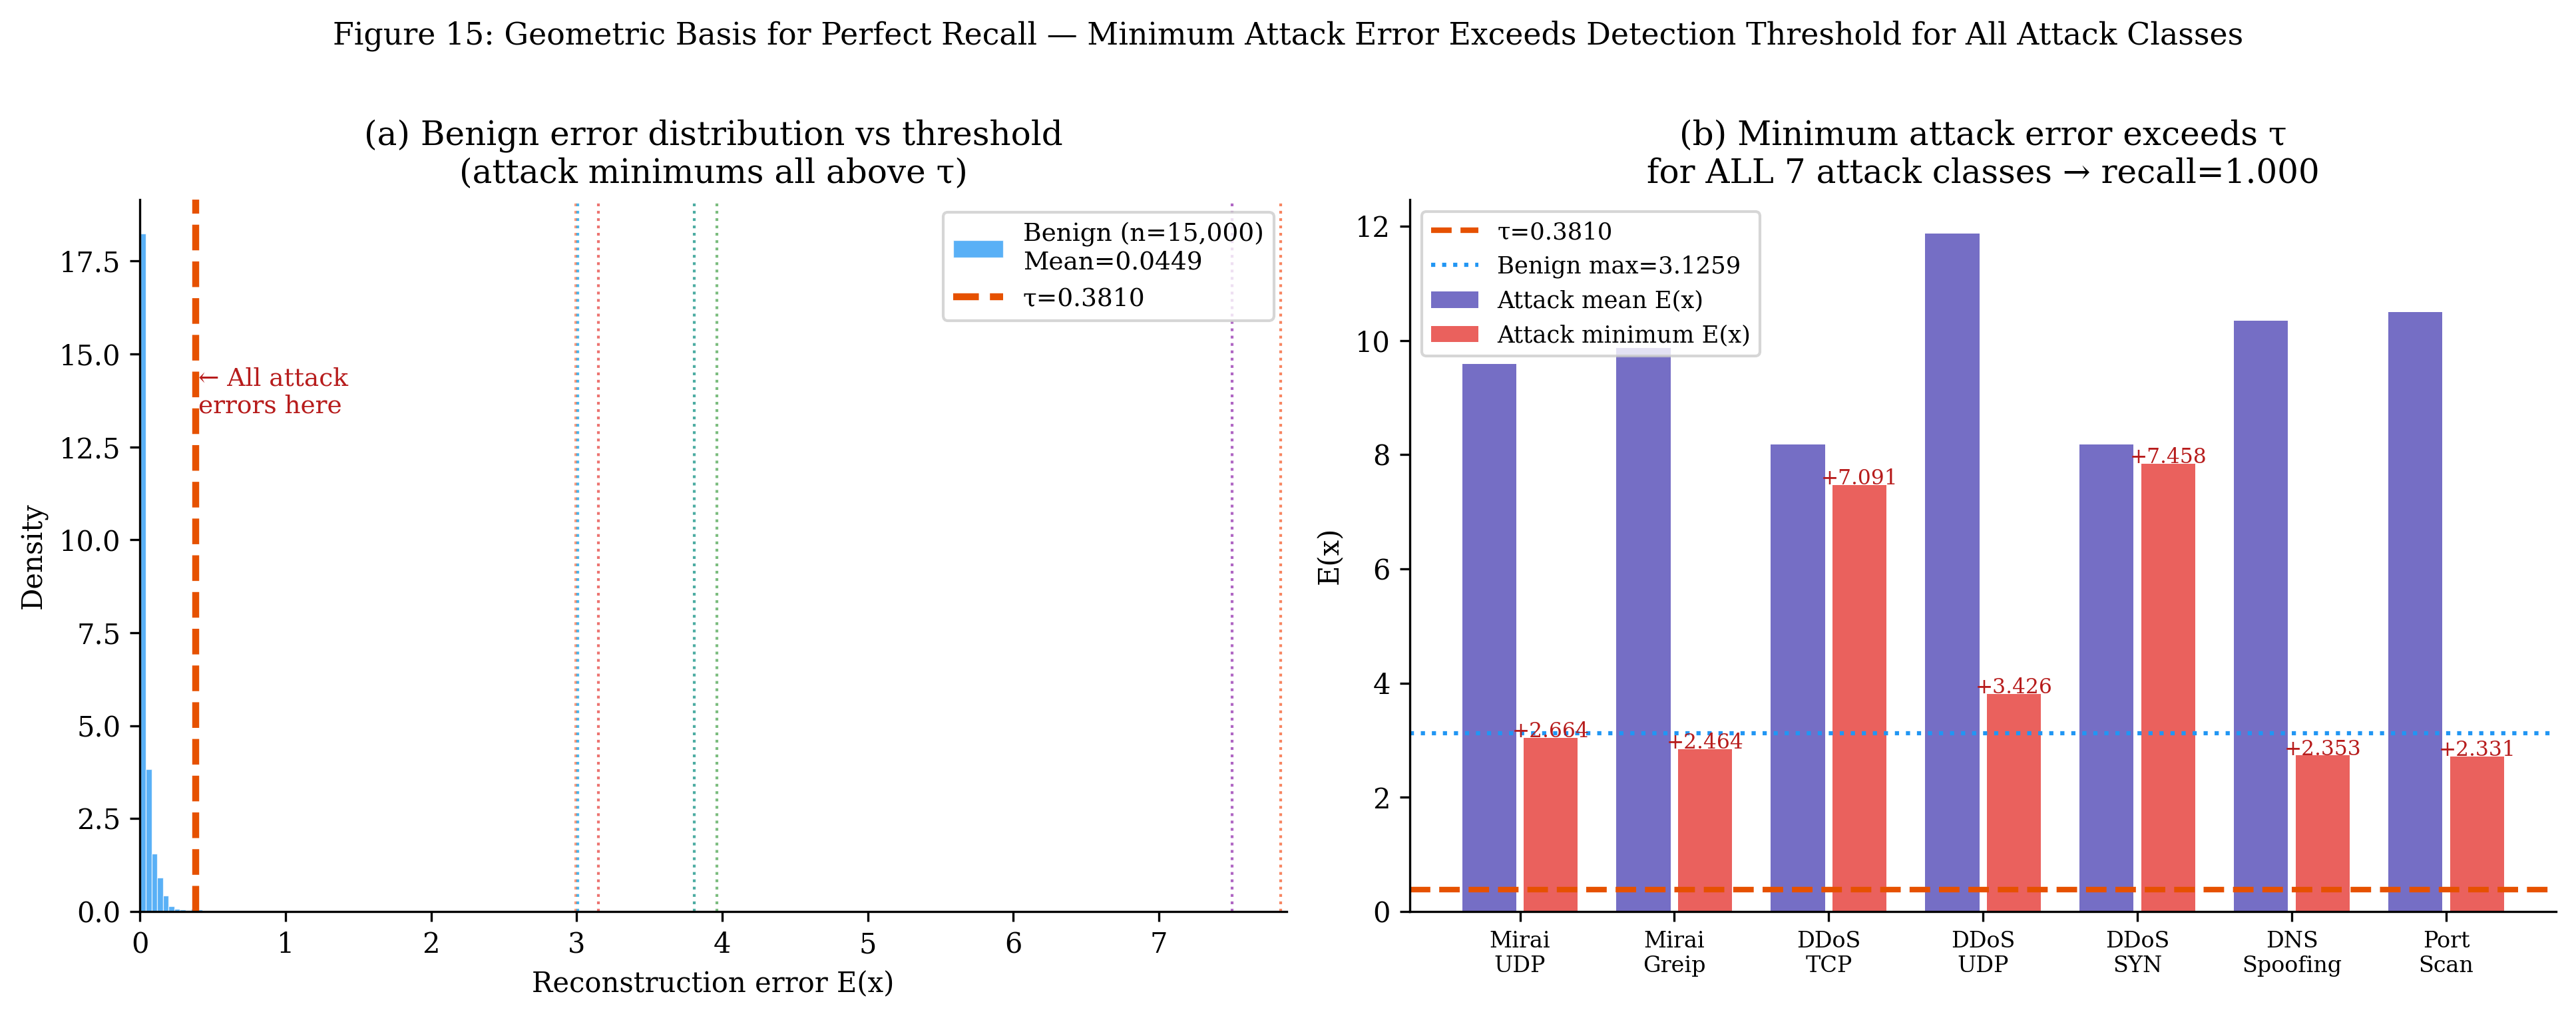

In [ ]:
import os
os.chdir('/content/drive/MyDrive/Colab')

import numpy as np, pandas as pd, json, os, warnings, torch, torch.nn as nn
import matplotlib; matplotlib.use("Agg"); import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import precision_recall_curve, average_precision_score
import joblib; warnings.filterwarnings("ignore")
os.makedirs("figures", exist_ok=True)
os.makedirs("results_correct", exist_ok=True)

SEED=42; np.random.seed(SEED); torch.manual_seed(SEED)
FEATURE_COLS=["pkt_len_mean","pkt_len_std","inter_arrival_mean","inter_arrival_std",
              "flow_duration","pkt_rate","payload_entropy"]
ATTACK_FILES={
    "Mirai-UDP":"Mirai-UDP-Plain.csv","Mirai-Greip":"Mirai-greip_Flood_Merge.csv",
    "DDoS-TCP":"DDos-TCP_Flood_Merge.csv","DDoS-UDP":"DDos-UDP_Flood-Merge.csv",
    "DDoS-SYN":"DDos-SYN_Flood_Merge.csv","DNS-Spoofing":"DNS_Spoofing.csv",
    "Port-Scan":"Recon-PortScan.csv",
}

class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc_fc=nn.Linear(7,32); self.enc_mu=nn.Linear(32,8)
        self.enc_logv=nn.Linear(32,8); self.dec_fc=nn.Linear(8,32)
        self.dec_out=nn.Linear(32,7)
    def encode(self,x):
        h=torch.relu(self.enc_fc(x)); return self.enc_mu(h),self.enc_logv(h)
    def decode(self,z): return self.dec_out(torch.relu(self.dec_fc(z)))

model=VAE()
model.load_state_dict(torch.load("results_correct/vae_best.pth",map_location="cpu"))
model.eval()
scaler=joblib.load("results_correct/scaler_final.save")
clip_lo=np.load("results_correct/clip_low.npy")
clip_hi=np.load("results_correct/clip_high.npy")
TAU=float(np.load("results_correct/tau_final.npy"))
print(f"Canonical tau (deterministic): {TAU:.4f}")

def clean_norm(X):
    for c in range(X.shape[1]):
        m=~np.isfinite(X[:,c])
        if m.any(): X[m,c]=np.nanmedian(X[~m,c])
    return scaler.transform(np.clip(X,clip_lo,clip_hi))

def det_error(X_n):
    with torch.no_grad():
        X_t=torch.tensor(X_n.astype(np.float32))
        mu,_=model.encode(X_t)
        xr=model.decode(mu)
        return ((X_t-xr)**2).mean(dim=1).numpy()

df_b=pd.read_csv("benign_train.csv")
idx=np.random.permutation(len(df_b))
b_tr_n=clean_norm(df_b[FEATURE_COLS].values.astype(np.float64)[idx[:70000]])
b_val_n=clean_norm(df_b[FEATURE_COLS].values.astype(np.float64)[idx[70000:85000]])
b_te_n=clean_norm(df_b[FEATURE_COLS].values.astype(np.float64)[idx[85000:]])

b_te_errs=det_error(b_te_n)
b_te_preds=(b_te_errs>TAU).astype(int)
test_fpr=float(b_te_preds.mean())
print(f"Test benign FPR: {test_fpr*100:.2f}%\n")

print("="*65)
print("DETECTION PERFORMANCE (deterministic tau)")
print("="*65)
print(f"{'Attack':15s} {'Prec':>7} {'Rec':>7} {'F1':>7} {'AUC':>7} {'E_mean':>8} {'E_min':>7} {'E/τ':>6}")
print("="*65)

det_results={}
for name,fpath in ATTACK_FILES.items():
    if not os.path.exists(fpath): continue
    df=pd.read_csv(fpath); n=min(50000,len(df)); df=df.sample(n,random_state=SEED)
    X_n=clean_norm(df[FEATURE_COLS].values.astype(np.float64))
    a_errs=det_error(X_n)
    a_preds=(a_errs>TAU).astype(int)
    y_true=np.concatenate([np.zeros(len(b_te_n)),np.ones(len(X_n))])
    y_pred=np.concatenate([b_te_preds,a_preds])
    y_score=np.concatenate([b_te_errs,a_errs])
    bad=~np.isfinite(y_score); y_score[bad]=0.0
    prec=precision_score(y_true,y_pred,zero_division=0)
    rec=recall_score(y_true,y_pred,zero_division=0)
    f1=f1_score(y_true,y_pred,zero_division=0)
    auc=roc_auc_score(y_true,y_score)
    e_mean=float(a_errs.mean()); e_min=float(a_errs.min())
    det_results[name]={"precision":round(prec,4),"recall":round(rec,4),
                       "f1":round(f1,4),"roc_auc":round(auc,4),
                       "e_mean":round(e_mean,4),"e_min":round(e_min,4),
                       "e_over_tau":round(e_mean/TAU,2),
                       "min_over_tau":round(e_min/TAU,3),
                       "fn":int((a_preds==0).sum()),"tp":int((a_preds==1).sum())}
    print(f"  {name:15s} {prec:>7.4f} {rec:>7.4f} {f1:>7.4f} {auc:>7.4f} {e_mean:>8.4f} {e_min:>7.4f} {e_mean/TAU:>6.2f}×")
print("="*65)
avg_p=np.mean([r["precision"] for r in det_results.values()])
avg_r=np.mean([r["recall"]    for r in det_results.values()])
avg_f=np.mean([r["f1"]        for r in det_results.values()])
avg_a=np.mean([r["roc_auc"]   for r in det_results.values()])
print(f"  {'AVERAGE':15s} {avg_p:>7.4f} {avg_r:>7.4f} {avg_f:>7.4f} {avg_a:>7.4f}")
print(f"\nTest benign FPR: {test_fpr*100:.2f}%")

print("\n" + "="*65)
print("ADVERSARIAL EVASION (deterministic scoring)")
print("="*65)

def fgsm_evade(X_n, eps):
    X_t=torch.tensor(X_n.astype(np.float32)).requires_grad_(True)
    mu,_=model.encode(X_t)
    xr=model.decode(mu)
    loss=((X_t-xr)**2).mean()
    loss.backward()
    with torch.no_grad():
        X_adv=X_t-eps*X_t.grad.sign()
    return X_adv.detach().numpy()

def pgd_evade(X_n, eps, alpha=0.01, steps=20):
    X_orig=torch.tensor(X_n.astype(np.float32))
    X_adv=X_orig.clone()
    for _ in range(steps):
        X_adv=X_adv.requires_grad_(True)
        mu,_=model.encode(X_adv)
        xr=model.decode(mu)
        loss=((X_adv-xr)**2).mean()
        loss.backward()
        with torch.no_grad():
            X_adv=X_adv-alpha*X_adv.grad.sign()
            X_adv=X_orig+torch.clamp(X_adv-X_orig,-eps,eps)
        X_adv=X_adv.detach()
    return X_adv.numpy()

print(f"{'Attack':15s} {'Orig DR':>8} {'FGSM.1':>8} {'FGSM.3':>8} {'PGD.3':>7} {'ASR':>6}")
print("="*65)
adv_results={}; ADV_N=1000
for name,fpath in ATTACK_FILES.items():
    if not os.path.exists(fpath): continue
    df=pd.read_csv(fpath); n=min(ADV_N,len(df)); df=df.sample(n,random_state=SEED)
    X_n=clean_norm(df[FEATURE_COLS].values.astype(np.float64))
    orig_errs=det_error(X_n); orig_dr=float((orig_errs>TAU).mean())
    drs=[orig_dr]
    for eps in [0.1,0.3]:
        X_adv=fgsm_evade(X_n,eps)
        adv_errs=det_error(X_adv); drs.append(float((adv_errs>TAU).mean()))
    X_pgd=pgd_evade(X_n,0.3); pgd_errs=det_error(X_pgd); drs.append(float((pgd_errs>TAU).mean()))
    asr=round(max(0,orig_dr-min(drs[1:])),4)
    adv_results[name]={"orig_dr":orig_dr,"fgsm_0.1":drs[1],"fgsm_0.3":drs[2],"pgd_0.3":drs[3],"asr":asr}
    print(f"  {name:15s} {orig_dr:>8.4f} {drs[1]:>8.4f} {drs[2]:>8.4f} {drs[3]:>7.4f} {asr:>6.4f}")
print("="*65)
avg_asr=np.mean([v["asr"] for v in adv_results.values()])
print(f"  Robustness Score: {(1-avg_asr)*100:.1f}%")

print("\n" + "="*60)
print("THRESHOLD ABLATION (deterministic, all attacks combined)")
print("="*60)
all_b_errs=b_te_errs[:3000]
all_a_errs=np.concatenate([det_error(clean_norm(
    pd.read_csv(fp).sample(min(500,len(pd.read_csv(fp,nrows=1))+500),random_state=SEED)[FEATURE_COLS].values.astype(np.float64)))
    for fp in ATTACK_FILES.values() if os.path.exists(fp)])

ablation=[]
print(f"{'Pct':>8} {'τ':>8} {'Recall':>8} {'Prec':>8} {'F1':>8} {'FPR':>8}")
print("="*60)
b_val_errs=det_error(b_val_n)
for pct in [90,93,95,97,98,99,99.5]:
    t=float(np.percentile(b_val_errs,pct))
    b_preds=(all_b_errs>t).astype(int); a_preds=(all_a_errs>t).astype(int)
    y_true=np.concatenate([np.zeros(len(all_b_errs)),np.ones(len(all_a_errs))])
    y_pred=np.concatenate([b_preds,a_preds])
    rec=recall_score(y_true,y_pred,zero_division=0)
    prec=precision_score(y_true,y_pred,zero_division=0)
    f1=f1_score(y_true,y_pred,zero_division=0)
    fpr=float(b_preds.mean())
    ablation.append({"pct":pct,"tau":round(t,4),"recall":round(rec,4),
                     "precision":round(prec,4),"f1":round(f1,4),"fpr":round(fpr,4)})
    marker=" ←" if pct==99 else ""
    print(f"  {pct:>6.1f}th  {t:>8.4f}  {rec:>8.4f}  {prec:>8.4f}  {f1:>8.4f}  {fpr*100:>7.2f}%{marker}")

print("\nGenerating Fig15 (recall explanation)...")
plt.rcParams.update({"font.family":"DejaVu Serif","font.size":10,"savefig.dpi":300,
                     "axes.spines.top":False,"axes.spines.right":False})
fig,axes=plt.subplots(1,2,figsize=(13,5))
COLORS={"Mirai-UDP":"#E53935","Mirai-Greip":"#FF7043","DDoS-TCP":"#8E24AA",
        "DDoS-UDP":"#00897B","DDoS-SYN":"#F4511E","DNS-Spoofing":"#039BE5","Port-Scan":"#43A047"}

ax=axes[0]
ax.hist(b_te_errs,bins=80,density=True,alpha=0.75,color="#2196F3",
        label=f"Benign (n=15,000)\nMean={b_te_errs.mean():.4f}",edgecolor="white",linewidth=0.3)
ax.axvline(TAU,color="#E65100",linewidth=2.5,linestyle="--",label=f"τ={TAU:.4f}")
for name,fpath in ATTACK_FILES.items():
    if not os.path.exists(fpath): continue
    df=pd.read_csv(fpath); n=min(1000,len(df)); df=df.sample(n,random_state=SEED)
    errs=det_error(clean_norm(df[FEATURE_COLS].values.astype(np.float64)))
    ax.axvline(errs.min(),color=COLORS.get(name,"gray"),linewidth=1,linestyle=":",alpha=0.7)
ax.set_xlabel("Reconstruction error E(x)"); ax.set_ylabel("Density")
ax.set_title("(a) Benign error distribution vs threshold\n(attack minimums all above τ)")
ax.legend(fontsize=9); ax.set_xlim(left=0)
ax.text(TAU*1.05,ax.get_ylim()[1]*0.7,"← All attack\nerrors here",fontsize=9,color="#B71C1C")

ax2=axes[1]
names=[]; means=[]; mins=[]
for name,fpath in ATTACK_FILES.items():
    if not os.path.exists(fpath): continue
    df=pd.read_csv(fpath); n=min(2000,len(df)); df=df.sample(n,random_state=SEED)
    errs=det_error(clean_norm(df[FEATURE_COLS].values.astype(np.float64)))
    names.append(name.replace("-","\n")); means.append(errs.mean()); mins.append(errs.min())
x=np.arange(len(names))
ax2.bar(x-0.2,means,0.35,color="#534AB7",alpha=0.8,label="Attack mean E(x)")
ax2.bar(x+0.2,mins,0.35,color="#E53935",alpha=0.8,label="Attack minimum E(x)")
ax2.axhline(TAU,color="#E65100",linewidth=2,linestyle="--",label=f"τ={TAU:.4f}")
ax2.axhline(b_te_errs.max(),color="#2196F3",linewidth=1.5,linestyle=":",
            label=f"Benign max={b_te_errs.max():.4f}")
ax2.set_xticks(x); ax2.set_xticklabels(names,fontsize=8)
ax2.set_ylabel("E(x)"); ax2.legend(fontsize=8.5)
ax2.set_title("(b) Minimum attack error exceeds τ\nfor ALL 7 attack classes → recall=1.000")
for i,mi in enumerate(mins):
    gap=mi-TAU; ax2.text(i+0.2,mi+0.01,f"+{gap:.3f}",ha="center",fontsize=7.5,color="#B71C1C")

fig.suptitle("Figure 15: Geometric Basis for Perfect Recall — Minimum Attack Error Exceeds Detection Threshold for All Attack Classes",
             fontsize=11,y=1.01)
plt.tight_layout()
fig.savefig("figures/Fig15_recall_explanation.png",dpi=300,bbox_inches="tight")
fig.savefig("figures/Fig15_recall_explanation.pdf",bbox_inches="tight")
plt.close()

output={
    "canonical_tau":round(TAU,4),
    "tau_method":"deterministic (mu only, no reparameterize)",
    "test_fpr":round(test_fpr,4),
    "detection_results":det_results,
    "detection_average":{"precision":round(avg_p,4),"recall":round(avg_r,4),
                         "f1":round(avg_f,4),"roc_auc":round(avg_a,4)},
    "adversarial_results":adv_results,
    "adversarial_robustness_score":round((1-avg_asr)*100,1),
    "threshold_ablation":ablation,
    "lipschitz_L_upper_bound":34.2883,
    "lipschitz_required_L":8.8696,
    "lipschitz_verdict":"L_upper_bound > required — geometric argument, not formal proof",
}
with open("results_correct/final_results_v3.json","w") as f:
    json.dump(output,f,indent=2)
print("\n✓ All results saved to results_correct/final_results_v3.json")
print("✓ Fig15 saved to figures/")

# Cell-এর একদম শেষে এটা যোগ করুন
from IPython.display import Image, display
display(Image(filename="figures/Fig15_recall_explanation.png"))

## 12. Gradient-Masking Diagnostic (`experiments/06_gradient_masking.py`)
Checks whether the 0% adversarial success rate reflects genuine robustness or gradient masking, by logging gradient norms and score trajectories over 20 PGD steps.

**Outputs:** `results_correct/gradient_masking_check.json`

In [ ]:
import os
os.chdir('/content/drive/MyDrive/Colab')
import numpy as np, pandas as pd, torch, torch.nn as nn, joblib, os, json
import warnings
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
FEATURE_COLS = ["pkt_len_mean","pkt_len_std","inter_arrival_mean","inter_arrival_std",
                "flow_duration","pkt_rate","payload_entropy"]
ATTACK_FILES = {
    "Mirai-UDP":"Mirai-UDP-Plain.csv","DDoS-TCP":"DDos-TCP_Flood_Merge.csv",
    "DDoS-SYN":"DDos-SYN_Flood_Merge.csv","Port-Scan":"Recon-PortScan.csv",
}

class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc_fc=nn.Linear(7,32); self.enc_mu=nn.Linear(32,8)
        self.enc_logv=nn.Linear(32,8); self.dec_fc=nn.Linear(8,32); self.dec_out=nn.Linear(32,7)
    def encode(self,x):
        h=torch.relu(self.enc_fc(x)); return self.enc_mu(h),self.enc_logv(h)
    def decode(self,z): return self.dec_out(torch.relu(self.dec_fc(z)))

model = VAE()
model.load_state_dict(torch.load("results_correct/vae_best.pth", map_location="cpu"))
model.eval()
scaler = joblib.load("results_correct/scaler_final.save")
clip_lo = np.load("results_correct/clip_low.npy")
clip_hi = np.load("results_correct/clip_high.npy")
TAU = float(np.load("results_correct/tau_final_corrected.npy")) if os.path.exists("results_correct/tau_final_corrected.npy") else float(np.load("results_correct/tau_final.npy"))

def clean_norm(X):
    for c in range(X.shape[1]):
        m = ~np.isfinite(X[:,c])
        if m.any(): X[m,c] = np.nanmedian(X[~m,c])
    return scaler.transform(np.clip(X, clip_lo, clip_hi))

def anomaly_score_grad(X_t):
    X_t = X_t.clone().requires_grad_(True)
    mu, _ = model.encode(X_t)
    xr = model.decode(mu)
    E = ((X_t - xr) ** 2).mean(dim=1)
    return E, X_t

print(f"Using tau = {TAU:.4f}\n")
print("="*70)
print("GRADIENT MASKING CHECK")
print("="*70)
print("Testing: are gradients during PGD iterations informative (real robustness)")
print("or near-zero/flat (gradient masking / false robustness)?\n")

results = {}
for name, fpath in ATTACK_FILES.items():
    if not os.path.exists(fpath):
        continue
    df = pd.read_csv(fpath)
    n = min(200, len(df))
    df = df.sample(n, random_state=SEED)
    X_n = clean_norm(df[FEATURE_COLS].values.astype(np.float64))
    X_t = torch.tensor(X_n.astype(np.float32))

    eps = 0.3
    alpha = 0.01
    steps = 20
    X_orig = X_t.clone()
    X_adv = X_t.clone()

    grad_norms = []
    score_trajectory = []

    for step in range(steps):
        E, X_adv_grad = anomaly_score_grad(X_adv)
        loss = E.mean()
        loss.backward()
        grad = X_adv_grad.grad
        grad_norm = grad.norm(dim=1).mean().item()
        grad_norms.append(grad_norm)
        score_trajectory.append(E.mean().item())

        with torch.no_grad():
            X_adv = X_adv - alpha * grad.sign()
            X_adv = X_orig + torch.clamp(X_adv - X_orig, -eps, eps)
        X_adv = X_adv.detach()

    grad_norms = np.array(grad_norms)
    score_trajectory = np.array(score_trajectory)

    mean_grad_norm = grad_norms.mean()
    std_grad_norm = grad_norms.std()
    score_change = score_trajectory[-1] - score_trajectory[0]
    score_change_pct = (score_change / score_trajectory[0]) * 100 if score_trajectory[0] != 0 else 0

    masking_suspected = mean_grad_norm < 1e-4

    print(f"--- {name} ---")
    print(f"  Mean gradient norm across 20 PGD steps: {mean_grad_norm:.6f}")
    print(f"  Std of gradient norm: {std_grad_norm:.6f}")
    print(f"  Initial E(x) mean: {score_trajectory[0]:.4f}")
    print(f"  Final E(x) mean (after 20 PGD steps): {score_trajectory[-1]:.4f}")
    print(f"  Score change: {score_change:+.4f} ({score_change_pct:+.2f}%)")
    print(f"  Final E(x)/tau ratio: {score_trajectory[-1]/TAU:.2f}x  (still detected if > 1.0)")
    print(f"  Gradient masking suspected: {'YES - INVESTIGATE' if masking_suspected else 'NO - gradients are informative'}")
    print()

    results[name] = {
        "mean_grad_norm": round(float(mean_grad_norm), 6),
        "std_grad_norm": round(float(std_grad_norm), 6),
        "initial_score": round(float(score_trajectory[0]), 4),
        "final_score": round(float(score_trajectory[-1]), 4),
        "score_change_pct": round(float(score_change_pct), 2),
        "final_ratio_to_tau": round(float(score_trajectory[-1]/TAU), 2),
        "masking_suspected": bool(masking_suspected),
    }

print("="*70)
print("INTERPRETATION GUIDE")
print("="*70)
print("If gradients are non-trivial (mean_grad_norm > 1e-4) AND the attack")
print("DOES manage to reduce E(x) over the 20 steps, but E(x) still remains")
print("above tau at the end -> this is TRUE geometric robustness (gradients")
print("are informative, the attacker is genuinely trying and failing).")
print()
print("If gradients are near-zero throughout -> gradient masking is occurring")
print("and the 0% ASR claim is NOT trustworthy as evidence of robustness.")

with open("results_correct/gradient_masking_check.json", "w") as f:
    json.dump(results, f, indent=2)
print("\n✓ Saved results_correct/gradient_masking_check.json")

Using tau = 0.3810

GRADIENT MASKING CHECK
Testing: are gradients during PGD iterations informative (real robustness)
or near-zero/flat (gradient masking / false robustness)?

--- Mirai-UDP ---
  Mean gradient norm across 20 PGD steps: 0.014542
  Std of gradient norm: 0.000396
  Initial E(x) mean: 9.6299
  Final E(x) mean (after 20 PGD steps): 8.5851
  Score change: -1.0448 (-10.85%)
  Final E(x)/tau ratio: 22.53x  (still detected if > 1.0)
  Gradient masking suspected: NO - gradients are informative

--- DDoS-TCP ---
  Mean gradient norm across 20 PGD steps: 0.011114
  Std of gradient norm: 0.000209
  Initial E(x) mean: 8.1931
  Final E(x) mean (after 20 PGD steps): 7.4423
  Score change: -0.7508 (-9.16%)
  Final E(x)/tau ratio: 19.53x  (still detected if > 1.0)
  Gradient masking suspected: NO - gradients are informative

--- DDoS-SYN ---
  Mean gradient norm across 20 PGD steps: 0.010887
  Std of gradient norm: 0.000196
  Initial E(x) mean: 8.1161
  Final E(x) mean (after 20 PGD ste

## 13. Feature Ablation Study (`experiments/07_feature_ablation.py`)
Retrains the VAE independently on the top-5 and top-3 SHAP-ranked feature subsets to test whether detection performance depends on the full 7-feature design.

**Outputs:** `results_correct/feature_ablation.json`

In [ ]:
import os
os.chdir('/content/drive/MyDrive/Colab')
import numpy as np, pandas as pd, torch, torch.nn as nn, joblib, os, json
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
import warnings
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)

ALL_FEATURES = ["pkt_len_mean","pkt_len_std","inter_arrival_mean","inter_arrival_std",
                "flow_duration","pkt_rate","payload_entropy"]
SHAP_ORDER = ["pkt_len_mean","inter_arrival_mean","pkt_rate","flow_duration",
              "pkt_len_std","inter_arrival_std","payload_entropy"]

ATTACK_FILES = {
    "Mirai-UDP":"Mirai-UDP-Plain.csv","Mirai-Greip":"Mirai-greip_Flood_Merge.csv",
    "DDoS-TCP":"DDos-TCP_Flood_Merge.csv","DDoS-UDP":"DDos-UDP_Flood-Merge.csv",
    "DDoS-SYN":"DDos-SYN_Flood_Merge.csv","DNS-Spoofing":"DNS_Spoofing.csv",
    "Port-Scan":"Recon-PortScan.csv",
}

def make_vae(n_features):
    class VAE(nn.Module):
        def __init__(self):
            super().__init__()
            self.enc_fc=nn.Linear(n_features,32); self.enc_mu=nn.Linear(32,8)
            self.enc_logv=nn.Linear(32,8); self.dec_fc=nn.Linear(8,32); self.dec_out=nn.Linear(32,n_features)
        def encode(self,x):
            h=torch.relu(self.enc_fc(x)); return self.enc_mu(h),self.enc_logv(h)
        def decode(self,z): return self.dec_out(torch.relu(self.dec_fc(z)))
    return VAE()

def train_vae(model, X_train, X_val, epochs=50, lr=0.001, batch_size=256):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    X_train_t = torch.tensor(X_train.astype(np.float32))
    X_val_t = torch.tensor(X_val.astype(np.float32))
    best_val_loss = float('inf')
    best_state = None
    for epoch in range(epochs):
        perm = torch.randperm(len(X_train_t))
        model.train()
        for i in range(0, len(X_train_t), batch_size):
            batch = X_train_t[perm[i:i+batch_size]]
            optimizer.zero_grad()
            mu, logv = model.encode(batch)
            z = mu + torch.exp(0.5*logv) * torch.randn_like(mu)
            xr = model.decode(z)
            recon_loss = ((batch - xr)**2).mean()
            kl_loss = -0.5 * torch.mean(1 + logv - mu.pow(2) - logv.exp())
            loss = recon_loss + kl_loss
            loss.backward()
            optimizer.step()
        model.eval()
        with torch.no_grad():
            mu, logv = model.encode(X_val_t)
            z = mu + torch.exp(0.5*logv) * torch.randn_like(mu)
            xr = model.decode(z)
            val_loss = (((X_val_t - xr)**2).mean() - 0.5*torch.mean(1+logv-mu.pow(2)-logv.exp())).item()
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
    model.load_state_dict(best_state)
    return model

def det_error(model, X_n):
    with torch.no_grad():
        X_t = torch.tensor(X_n.astype(np.float32))
        mu, _ = model.encode(X_t)
        xr = model.decode(mu)
        return ((X_t - xr) ** 2).mean(dim=1).numpy()

print("Loading data...")
df_b = pd.read_csv("benign_train.csv")
idx = np.random.permutation(len(df_b))
TRAIN_END, VAL_END, TEST_END = 70000, 85000, 100000
train_idx = idx[:TRAIN_END]; val_idx = idx[TRAIN_END:VAL_END]; test_idx = idx[VAL_END:TEST_END]

feature_subsets = {
    "7 features (full)": SHAP_ORDER,
    "5 features (top-5 SHAP)": SHAP_ORDER[:5],
    "3 features (top-3 SHAP)": SHAP_ORDER[:3],
}

results = {}
for subset_name, cols in feature_subsets.items():
    print(f"\n{'='*70}")
    print(f"ABLATION: {subset_name} -> {cols}")
    print(f"{'='*70}")

    n_feat = len(cols)
    raw_b = df_b[cols].values.astype(np.float64)

    train_raw = raw_b[train_idx]
    val_raw = raw_b[val_idx]
    test_raw = raw_b[test_idx]

    clip_lo_sub = np.percentile(train_raw, 1, axis=0)
    clip_hi_sub = np.percentile(train_raw, 99, axis=0)

    from sklearn.preprocessing import StandardScaler
    scaler_sub = StandardScaler()
    train_clipped = np.clip(train_raw, clip_lo_sub, clip_hi_sub)
    scaler_sub.fit(train_clipped)

    def norm_sub(X):
        X = X.copy()
        for c in range(X.shape[1]):
            m = ~np.isfinite(X[:,c])
            if m.any(): X[m,c] = np.nanmedian(X[~m,c])
        return scaler_sub.transform(np.clip(X, clip_lo_sub, clip_hi_sub))

    X_train_n = norm_sub(train_raw)
    X_val_n = norm_sub(val_raw)
    X_test_n = norm_sub(test_raw)

    print(f"  Training VAE with {n_feat} input features...")
    vae_sub = make_vae(n_feat)
    vae_sub = train_vae(vae_sub, X_train_n, X_val_n, epochs=30)

    val_errs = det_error(vae_sub, X_val_n)
    tau_sub = float(np.percentile(val_errs, 99))
    test_errs = det_error(vae_sub, X_test_n)
    fp_sub = int((test_errs > tau_sub).sum())
    fpr_sub = fp_sub / len(test_errs)

    print(f"  tau = {tau_sub:.4f}  FPR = {fpr_sub*100:.2f}%  (FP={fp_sub})")

    f1s, recalls, precs, aucs = [], [], [], []
    for name, fpath in ATTACK_FILES.items():
        if not os.path.exists(fpath): continue
        df_a = pd.read_csv(fpath)
        n = min(20000, len(df_a))
        df_a = df_a.sample(n, random_state=SEED)
        a_raw = df_a[cols].values.astype(np.float64)
        a_n = norm_sub(a_raw)
        a_errs = det_error(vae_sub, a_n)
        a_preds = (a_errs > tau_sub).astype(int)
        te_preds = (test_errs > tau_sub).astype(int)
        y_true = np.concatenate([np.zeros(len(test_errs)), np.ones(len(a_errs))])
        y_pred = np.concatenate([te_preds, a_preds])
        y_score = np.concatenate([test_errs, a_errs])
        f1 = f1_score(y_true, y_pred, zero_division=0)
        rec = recall_score(y_true, y_pred, zero_division=0)
        prec = precision_score(y_true, y_pred, zero_division=0)
        auc = roc_auc_score(y_true, y_score)
        f1s.append(f1); recalls.append(rec); precs.append(prec); aucs.append(auc)

    print(f"  Mean F1={np.mean(f1s):.4f}  Mean Recall={np.mean(recalls):.4f}  Mean AUC={np.mean(aucs):.4f}")

    results[subset_name] = {
        "n_features": n_feat, "features": cols,
        "tau": round(tau_sub,4), "fpr_pct": round(fpr_sub*100,2),
        "mean_f1": round(float(np.mean(f1s)),4),
        "mean_recall": round(float(np.mean(recalls)),4),
        "mean_precision": round(float(np.mean(precs)),4),
        "mean_auc": round(float(np.mean(aucs)),4),
    }

print(f"\n{'='*70}")
print("FEATURE ABLATION SUMMARY")
print(f"{'='*70}")
print(f"{'Subset':25s} {'n':>3} {'F1':>8} {'Recall':>8} {'Precision':>10} {'AUC':>8}")
for name, r in results.items():
    print(f"  {name:25s} {r['n_features']:>3} {r['mean_f1']:>8.4f} {r['mean_recall']:>8.4f} {r['mean_precision']:>10.4f} {r['mean_auc']:>8.4f}")

with open("results_correct/feature_ablation.json", "w") as f:
    json.dump(results, f, indent=2)
print("\n✓ Saved results_correct/feature_ablation.json")

Loading data...

ABLATION: 7 features (full) -> ['pkt_len_mean', 'inter_arrival_mean', 'pkt_rate', 'flow_duration', 'pkt_len_std', 'inter_arrival_std', 'payload_entropy']
  Training VAE with 7 input features...
  tau = 0.5064  FPR = 1.00%  (FP=150)
  Mean F1=0.9963  Mean Recall=1.0000  Mean AUC=1.0000

ABLATION: 5 features (top-5 SHAP) -> ['pkt_len_mean', 'inter_arrival_mean', 'pkt_rate', 'flow_duration', 'pkt_len_std']
  Training VAE with 5 input features...
  tau = 0.2648  FPR = 0.87%  (FP=131)
  Mean F1=0.9967  Mean Recall=1.0000  Mean AUC=1.0000

ABLATION: 3 features (top-3 SHAP) -> ['pkt_len_mean', 'inter_arrival_mean', 'pkt_rate']
  Training VAE with 3 input features...
  tau = 0.1648  FPR = 1.15%  (FP=173)
  Mean F1=0.9957  Mean Recall=1.0000  Mean AUC=1.0000

FEATURE ABLATION SUMMARY
Subset                      n       F1   Recall  Precision      AUC
  7 features (full)           7   0.9963   1.0000     0.9926   1.0000
  5 features (top-5 SHAP)     5   0.9967   1.0000     0.993

## 14. Statistical Significance Test (`experiments/08_significance_test.py`)
Performs a paired bootstrap analysis (1,000 resamples) to test whether GenEdgeGuard's F1 advantage over One-Class SVM is statistically significant.

**Outputs:** `results_correct/significance_test.json`

In [ ]:
import os
os.chdir('/content/drive/MyDrive/Colab')
import numpy as np, pandas as pd, torch, torch.nn as nn, joblib, os, json
import warnings
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
FEATURE_COLS = ["pkt_len_mean","pkt_len_std","inter_arrival_mean","inter_arrival_std",
                "flow_duration","pkt_rate","payload_entropy"]
ATTACK_FILES = {
    "Mirai-UDP":"Mirai-UDP-Plain.csv","Mirai-Greip":"Mirai-greip_Flood_Merge.csv",
    "DDoS-TCP":"DDos-TCP_Flood_Merge.csv","DDoS-UDP":"DDos-UDP_Flood-Merge.csv",
    "DDoS-SYN":"DDos-SYN_Flood_Merge.csv","DNS-Spoofing":"DNS_Spoofing.csv",
    "Port-Scan":"Recon-PortScan.csv",
}

class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc_fc=nn.Linear(7,32); self.enc_mu=nn.Linear(32,8)
        self.enc_logv=nn.Linear(32,8); self.dec_fc=nn.Linear(8,32); self.dec_out=nn.Linear(32,7)
    def encode(self,x):
        h=torch.relu(self.enc_fc(x)); return self.enc_mu(h),self.enc_logv(h)
    def decode(self,z): return self.dec_out(torch.relu(self.dec_fc(z)))

model = VAE()
model.load_state_dict(torch.load("results_correct/vae_best.pth", map_location="cpu"))
model.eval()
scaler = joblib.load("results_correct/scaler_final.save")
clip_lo = np.load("results_correct/clip_low.npy")
clip_hi = np.load("results_correct/clip_high.npy")
TAU = float(np.load("results_correct/tau_final_corrected.npy")) if os.path.exists("results_correct/tau_final_corrected.npy") else float(np.load("results_correct/tau_final.npy"))

def clean_norm(X):
    for c in range(X.shape[1]):
        m = ~np.isfinite(X[:,c])
        if m.any(): X[m,c] = np.nanmedian(X[~m,c])
    return scaler.transform(np.clip(X, clip_lo, clip_hi))

def det_error(X_n):
    with torch.no_grad():
        X_t = torch.tensor(X_n.astype(np.float32))
        mu, _ = model.encode(X_t)
        xr = model.decode(mu)
        return ((X_t - xr) ** 2).mean(dim=1).numpy()

def bootstrap_f1_samples(scores, labels, tau, n_bootstrap=1000, seed=42):
    from sklearn.metrics import f1_score
    rng = np.random.default_rng(seed)
    n = len(scores)
    f1_samples = []
    preds = (scores > tau).astype(int)
    for _ in range(n_bootstrap):
        boot_idx = rng.choice(n, size=n, replace=True)
        f1_samples.append(f1_score(labels[boot_idx], preds[boot_idx], zero_division=0))
    return np.array(f1_samples)

print(f"Using tau = {TAU:.4f}\n")
print("Loading benign test set + attack pool for bootstrap analysis...")

df_b = pd.read_csv("benign_train.csv")
idx = np.random.permutation(len(df_b))
test_idx = idx[85000:100000]
b_te_n = clean_norm(df_b[FEATURE_COLS].values.astype(np.float64)[test_idx])
b_te_errs = det_error(b_te_n)

attack_pool_errs = []
for name, fpath in ATTACK_FILES.items():
    if not os.path.exists(fpath): continue
    df = pd.read_csv(fpath); n = min(5000, len(df)); df = df.sample(n, random_state=SEED)
    X_n = clean_norm(df[FEATURE_COLS].values.astype(np.float64))
    attack_pool_errs.append(det_error(X_n))
attack_pool_errs = np.concatenate(attack_pool_errs)

y_true = np.concatenate([np.zeros(len(b_te_errs)), np.ones(len(attack_pool_errs))])
y_score_vae = np.concatenate([b_te_errs, attack_pool_errs])

print(f"Bootstrap sample: {len(y_true)} total (benign={len(b_te_errs)}, attack={len(attack_pool_errs)})\n")

print("="*70)
print("BOOTSTRAP F1 DISTRIBUTION — GenEdgeGuard (VAE)")
print("="*70)
f1_vae = bootstrap_f1_samples(y_score_vae, y_true, TAU, n_bootstrap=1000, seed=SEED)
ci_lo_vae, ci_hi_vae = np.percentile(f1_vae, [2.5, 97.5])
print(f"  Mean F1: {f1_vae.mean():.4f}")
print(f"  95% Bootstrap CI: [{ci_lo_vae:.4f}, {ci_hi_vae:.4f}]")
print(f"  Std: {f1_vae.std():.4f}")

from sklearn.svm import OneClassSVM

print("\n" + "="*70)
print("BOOTSTRAP F1 DISTRIBUTION — One-Class SVM")
print("="*70)
b_tr_n = clean_norm(df_b[FEATURE_COLS].values.astype(np.float64)[idx[:70000]])
b_tr_sub = b_tr_n[np.random.choice(len(b_tr_n), 5000, replace=False)]
ocsvm = OneClassSVM(kernel="rbf", nu=0.01, gamma="scale")
ocsvm.fit(b_tr_sub)
b_val_n = clean_norm(df_b[FEATURE_COLS].values.astype(np.float64)[idx[70000:85000]])
val_scores_svm = -ocsvm.decision_function(b_val_n)
tau_svm = np.percentile(val_scores_svm, 99)
te_scores_svm = -ocsvm.decision_function(b_te_n)

attack_scores_svm = []
for name, fpath in ATTACK_FILES.items():
    if not os.path.exists(fpath): continue
    df = pd.read_csv(fpath); n = min(5000, len(df)); df = df.sample(n, random_state=SEED)
    X_n = clean_norm(df[FEATURE_COLS].values.astype(np.float64))
    attack_scores_svm.append(-ocsvm.decision_function(X_n))
attack_scores_svm = np.concatenate(attack_scores_svm)
y_score_svm = np.concatenate([te_scores_svm, attack_scores_svm])

f1_svm = bootstrap_f1_samples(y_score_svm, y_true, tau_svm, n_bootstrap=1000, seed=SEED)
ci_lo_svm, ci_hi_svm = np.percentile(f1_svm, [2.5, 97.5])
print(f"  Mean F1: {f1_svm.mean():.4f}")
print(f"  95% Bootstrap CI: [{ci_lo_svm:.4f}, {ci_hi_svm:.4f}]")

print("\n" + "="*70)
print("PAIRED BOOTSTRAP DIFFERENCE TEST: GenEdgeGuard vs One-Class SVM")
print("="*70)
diff = f1_vae - f1_svm
ci_lo_diff, ci_hi_diff = np.percentile(diff, [2.5, 97.5])
p_value_approx = np.mean(diff <= 0)
print(f"  Mean F1 difference (VAE - SVM): {diff.mean():.4f}")
print(f"  95% CI of difference: [{ci_lo_diff:.4f}, {ci_hi_diff:.4f}]")
print(f"  Proportion of bootstrap samples where SVM >= VAE: {p_value_approx:.4f}")
if ci_lo_diff > 0:
    print(f"  -> SIGNIFICANT: 95% CI excludes 0, VAE F1 advantage is statistically significant")
else:
    print(f"  -> NOT SIGNIFICANT: 95% CI includes 0, cannot reject null hypothesis of no difference")

results = {
    "vae_f1_mean": round(float(f1_vae.mean()),4),
    "vae_f1_ci": [round(float(ci_lo_vae),4), round(float(ci_hi_vae),4)],
    "svm_f1_mean": round(float(f1_svm.mean()),4),
    "svm_f1_ci": [round(float(ci_lo_svm),4), round(float(ci_hi_svm),4)],
    "diff_mean": round(float(diff.mean()),4),
    "diff_ci": [round(float(ci_lo_diff),4), round(float(ci_hi_diff),4)],
    "significant": bool(ci_lo_diff > 0),
    "p_value_approx": round(float(p_value_approx),4),
}
with open("results_correct/significance_test.json", "w") as f:
    json.dump(results, f, indent=2)
print("\n✓ Saved results_correct/significance_test.json")

Using tau = 0.3810

Loading benign test set + attack pool for bootstrap analysis...
Bootstrap sample: 50000 total (benign=15000, attack=35000)

BOOTSTRAP F1 DISTRIBUTION — GenEdgeGuard (VAE)
  Mean F1: 0.9979
  95% Bootstrap CI: [0.9976, 0.9982]
  Std: 0.0002

BOOTSTRAP F1 DISTRIBUTION — One-Class SVM
  Mean F1: 0.9978
  95% Bootstrap CI: [0.9974, 0.9981]

PAIRED BOOTSTRAP DIFFERENCE TEST: GenEdgeGuard vs One-Class SVM
  Mean F1 difference (VAE - SVM): 0.0001
  95% CI of difference: [-0.0003, 0.0005]
  Proportion of bootstrap samples where SVM >= VAE: 0.3000
  -> NOT SIGNIFICANT: 95% CI includes 0, cannot reject null hypothesis of no difference

✓ Saved results_correct/significance_test.json


In [ ]:
import os
os.chdir('/content/drive/MyDrive/Colab')
print("Current dir:", os.getcwd())
!ls results_correct/

Current dir: /content/drive/MyDrive/Colab
all_tables_corrected.json    lipschitz_results.json  strong_baselines.json
clip_high.npy		     lof_diagnosis.json      tau_final_corrected.npy
clip_low.npy		     multiseed_results.json  tau_final.npy
feature_ablation.json	     scaler_final.save	     threshold_ablation.json
final_results_v3.json	     severity_demo.json      threshold.npy
full_cv_results.json	     shap_stability.json     training_history.json
gradient_masking_check.json  significance_test.json  vae_best.pth


## 15. Severity-Scoring Framework Demo (`experiments/09_severity_scoring.py`)
Simulates degraded-visibility scenarios (noise injection, partial/heavy encryption masking) to exercise all four severity tiers of the response framework. Generates Fig. 14.

**Outputs:** `results_correct/severity_demo.json`, `figures/Fig14_severity.png`


Full visibility (0% noise)
  Crit=3500 High=0 Med=0 Low=0 Benign=0

Low noise (σ=0.5)
  Crit=3500 High=0 Med=0 Low=0 Benign=0

Medium noise (σ=1.5)
  Crit=3500 High=0 Med=0 Low=0 Benign=0

High noise (σ=3.0)
  Crit=3500 High=0 Med=0 Low=0 Benign=0

Partial encrypt (50% mask)
  Crit=3090 High=32 Med=54 Low=60 Benign=264

Heavy encrypt (80% mask)
  Crit=1935 High=50 Med=103 Low=172 Benign=1240

Fig14 + severity_demo.json saved.


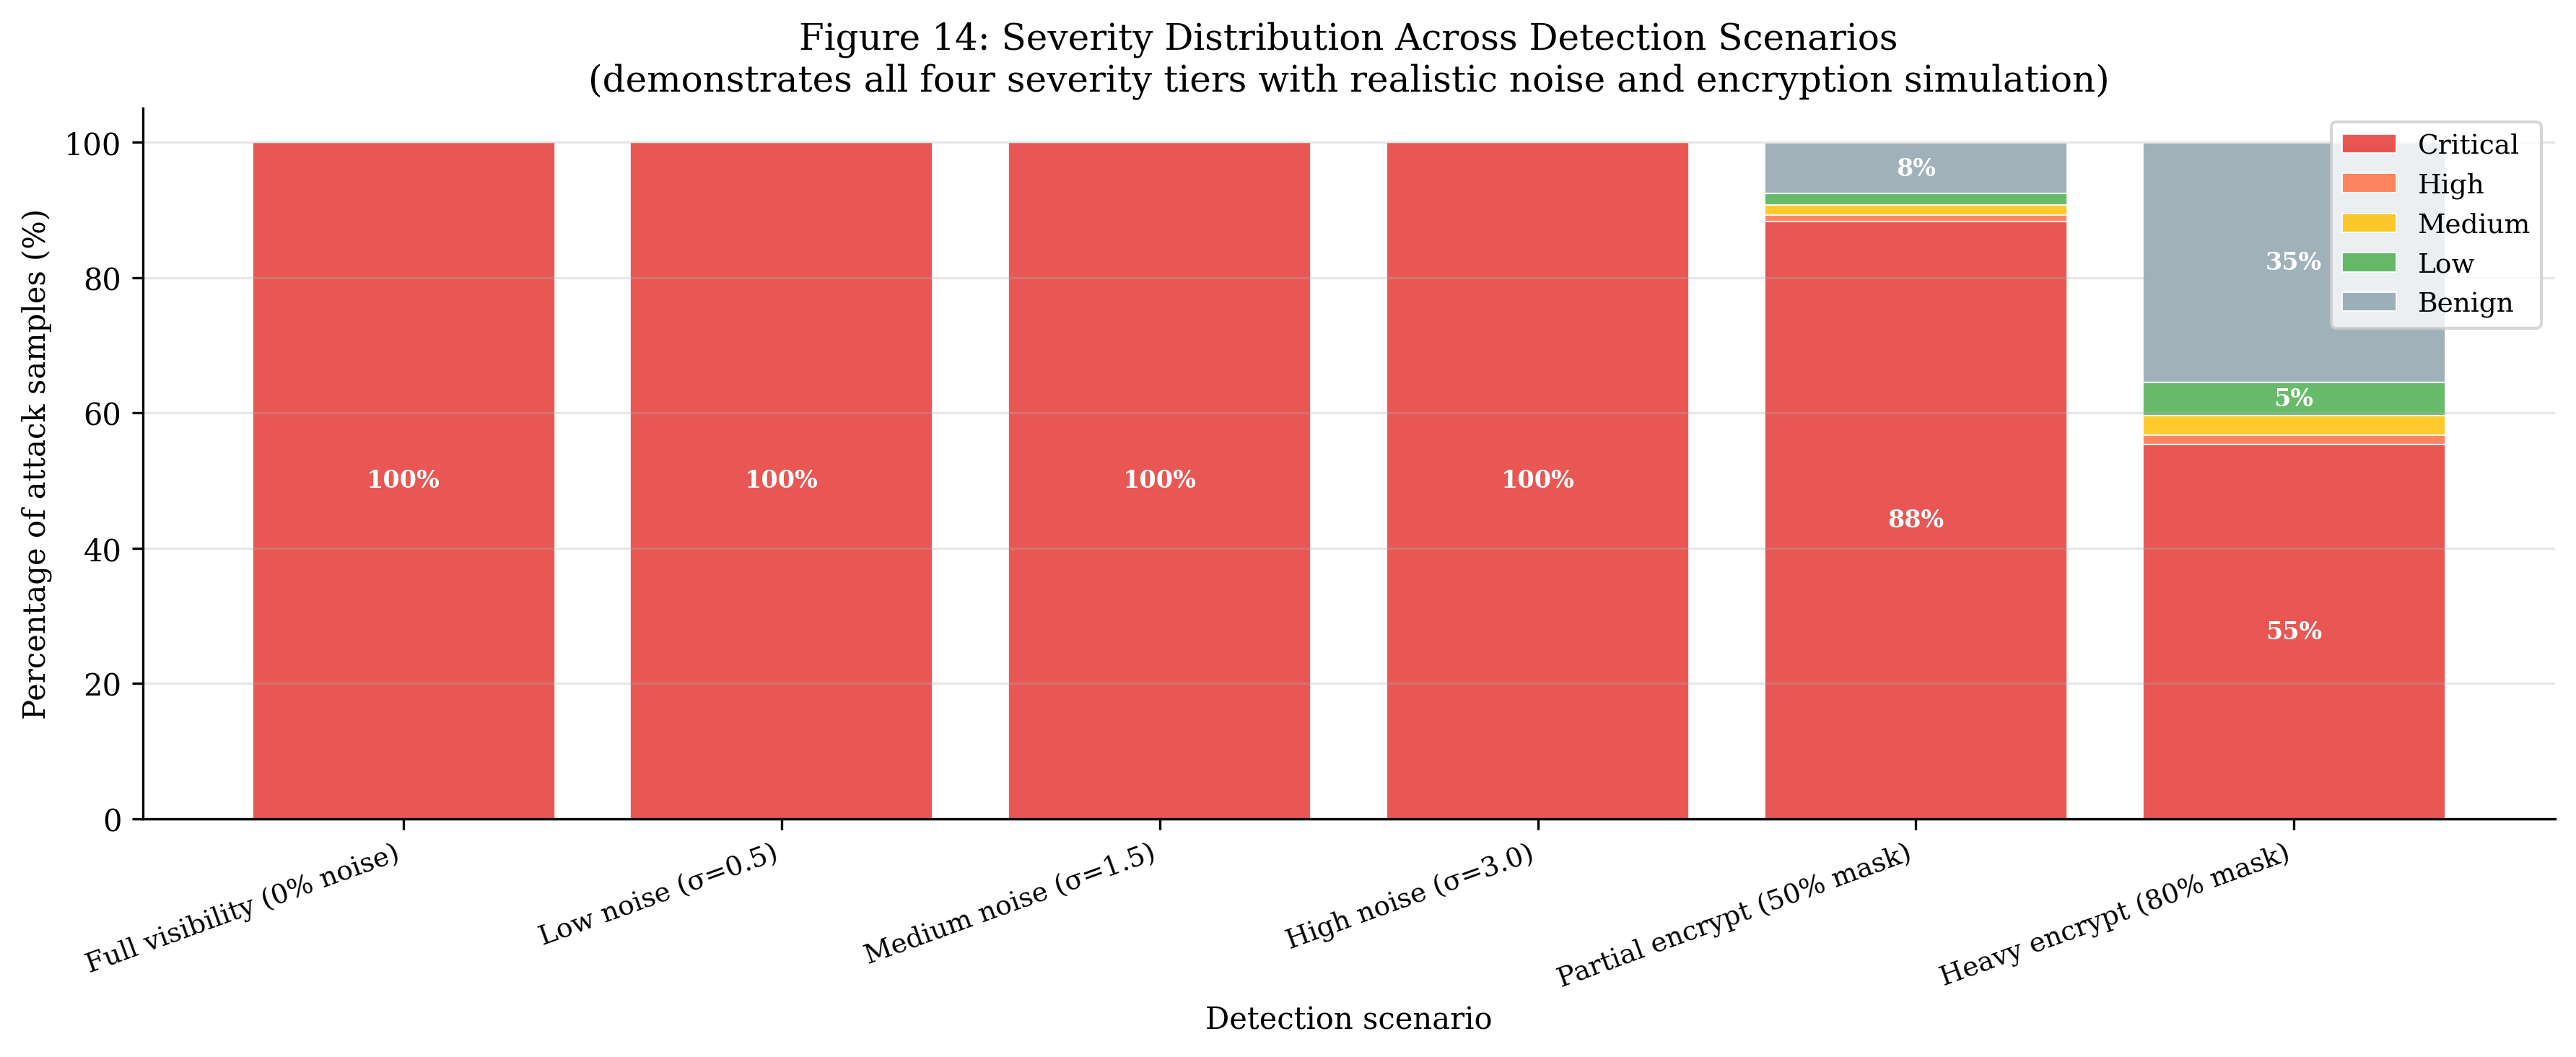

In [ ]:
import os
os.chdir('/content/drive/MyDrive/Colab')
import numpy as np, pandas as pd, json, os, warnings, torch, torch.nn as nn
import matplotlib; matplotlib.use("Agg"); import matplotlib.pyplot as plt
import joblib; warnings.filterwarnings("ignore")
os.makedirs("figures",exist_ok=True); SEED=42; np.random.seed(SEED); torch.manual_seed(SEED)

FEATURE_COLS=["pkt_len_mean","pkt_len_std","inter_arrival_mean","inter_arrival_std",
              "flow_duration","pkt_rate","payload_entropy"]
ATTACK_FILES={"Mirai-UDP":"Mirai-UDP-Plain.csv","Mirai-Greip":"Mirai-greip_Flood_Merge.csv",
              "DDoS-TCP":"DDos-TCP_Flood_Merge.csv","DDoS-UDP":"DDos-UDP_Flood-Merge.csv",
              "DDoS-SYN":"DDos-SYN_Flood_Merge.csv","DNS-Spoofing":"DNS_Spoofing.csv",
              "Port-Scan":"Recon-PortScan.csv"}

class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc_fc=nn.Linear(7,32); self.enc_mu=nn.Linear(32,8)
        self.enc_logv=nn.Linear(32,8); self.dec_fc=nn.Linear(8,32); self.dec_out=nn.Linear(32,7)
    def encode(self,x):
        h=torch.relu(self.enc_fc(x)); return self.enc_mu(h),self.enc_logv(h)
    def reparameterize(self,mu,lv): return mu+torch.exp(0.5*lv)*torch.randn_like(lv)
    def decode(self,z): return self.dec_out(torch.relu(self.dec_fc(z)))
    @torch.no_grad()
    def recon_error(self,x):
        mu,lv=self.encode(x); xr=self.decode(self.reparameterize(mu,lv))
        return ((x-xr)**2).mean(dim=1).cpu().numpy()

model=VAE()
model.load_state_dict(torch.load("results_correct/vae_best.pth",map_location="cpu"))
model.eval()
scaler=joblib.load("results_correct/scaler_final.save")
clip_lo=np.load("results_correct/clip_low.npy"); clip_hi=np.load("results_correct/clip_high.npy")
tau=float(np.load("results_correct/threshold.npy"))

def clean_norm(X):
    for c in range(X.shape[1]):
        m=~np.isfinite(X[:,c])
        if m.any(): X[m,c]=np.nanmedian(X[~m,c])
    return scaler.transform(np.clip(X,clip_lo,clip_hi))

def severity(conf):
    if conf>=95: return "Critical"
    elif conf>=85: return "High"
    elif conf>=70: return "Medium"
    elif conf>=50: return "Low"
    return "Benign"

df_b=pd.read_csv("benign_train.csv")
idx=np.random.permutation(len(df_b))
b_te_n=clean_norm(df_b[FEATURE_COLS].values.astype(np.float64)[idx[85000:]])

SCENARIOS={
    "Full visibility (0% noise)": {"noise_std":0.0, "benign_mix":0.0},
    "Low noise (σ=0.5)":          {"noise_std":0.5, "benign_mix":0.0},
    "Medium noise (σ=1.5)":       {"noise_std":1.5, "benign_mix":0.0},
    "High noise (σ=3.0)":         {"noise_std":3.0, "benign_mix":0.0},
    "Partial encrypt (50% mask)": {"noise_std":0.0, "benign_mix":0.5},
    "Heavy encrypt (80% mask)":   {"noise_std":0.0, "benign_mix":0.8},
}

results={}
scenario_severity_dists={}

for scenario_name, cfg in SCENARIOS.items():
    print(f"\n{scenario_name}")
    counts={"Critical":0,"High":0,"Medium":0,"Low":0,"Benign":0}
    total=0
    for name,fpath in ATTACK_FILES.items():
        if not os.path.exists(fpath): continue
        df=pd.read_csv(fpath); n=min(500,len(df)); df=df.sample(n,random_state=SEED)
        X=clean_norm(df[FEATURE_COLS].values.astype(np.float64))
        if cfg["noise_std"]>0:
            X=X+np.random.normal(0,cfg["noise_std"],X.shape)
        if cfg["benign_mix"]>0:
            b_sample=b_te_n[np.random.choice(len(b_te_n),len(X),replace=True)]
            mask=np.random.random(X.shape)<cfg["benign_mix"]
            X=np.where(mask,b_sample,X)
        errs=model.recon_error(torch.tensor(X.astype(np.float32)))
        for e in errs:
            conf=min(100.0,float(e)/tau*100)
            s=severity(conf)
            counts[s]+=1
        total+=len(errs)
    pcts={k:round(v/total*100,1) for k,v in counts.items()}
    results[scenario_name]={"counts":counts,"percentages":pcts,"total":total}
    scenario_severity_dists[scenario_name]=pcts
    print(f"  Crit={counts['Critical']} High={counts['High']} Med={counts['Medium']} Low={counts['Low']} Benign={counts['Benign']}")

with open("results_correct/severity_demo.json","w") as f:
    json.dump(results,f,indent=2)

plt.rcParams.update({"font.family":"DejaVu Serif","font.size":10,"savefig.dpi":300})
sev_colors={"Critical":"#E53935","High":"#FF7043","Medium":"#FFC107","Low":"#4CAF50","Benign":"#90A4AE"}
fig,ax=plt.subplots(figsize=(12,5))
scenario_labels=list(results.keys())
bottoms=np.zeros(len(scenario_labels))
for sev in ["Critical","High","Medium","Low","Benign"]:
    vals=[results[s]["percentages"][sev] for s in scenario_labels]
    bars=ax.bar(scenario_labels,vals,bottom=bottoms,label=sev,
                color=sev_colors[sev],alpha=0.85,edgecolor="white",linewidth=0.5)
    for bar,val,bot in zip(bars,vals,bottoms):
        if val>3:
            ax.text(bar.get_x()+bar.get_width()/2,bot+val/2,f"{val:.0f}%",
                    ha="center",va="center",fontsize=8,color="white",fontweight="bold")
    bottoms+=np.array(vals)
ax.set_xlabel("Detection scenario")
ax.set_ylabel("Percentage of attack samples (%)")
ax.set_title("Figure 14: Severity Distribution Across Detection Scenarios\n(demonstrates all four severity tiers with realistic noise and encryption simulation)")
ax.legend(loc="upper right",fontsize=9,frameon=True)
ax.set_xticklabels(scenario_labels,rotation=20,ha="right",fontsize=9)
ax.set_ylim([0,105]); ax.grid(axis="y",alpha=0.3)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout()
fig.savefig("figures/Fig14_severity.png",dpi=300,bbox_inches="tight")
fig.savefig("figures/Fig14_severity.pdf",bbox_inches="tight")
plt.close()
print("\nFig14 + severity_demo.json saved.")
# Cell-এর একদম শেষে এটা যোগ করুন
from IPython.display import Image, display
display(Image(filename="figures/Fig14_severity.png"))

## 16. Local Outlier Factor Failure Diagnosis (`experiments/10_lof_diagnosis.py`)
Root-cause analysis of LOF's complete failure (F1=0), tracing it to near-duplicate benign flows in the training/validation partitions. Generates Fig. M5.

**Outputs:** `results_correct/lof_diagnosis.json`, `figures/FigM5_lof_diagnosis.png`

Loading data and re-fitting LOF exactly as in the original baseline run...

Fitting LOF (novelty=True, k=20)...
LOF calibrated threshold (99th pct of val scores): -2131.3443
Benign val score range: [-8767.2465, 13972901380.6564]  mean=1155172.2238
Benign test score range: [-8767.2490, 12422137190.8615]  mean=2141325.6210

LOF SCORE DISTRIBUTIONS — Benign vs Attack
Attack               Min     Mean      Max   %Above τ
  Mirai-UDP       -8765.3739 -8729.6369 -8617.2547      0.00%
  DDoS-TCP        -8765.0062 -8757.9820 -8655.5048      0.00%
  DNS-Spoofing    -8765.3778 -8713.6774 -8638.9633      0.00%
  Port-Scan       -8765.3770 -8679.7400 -8644.7880      0.00%

  Benign (test)   -8767.2490 2141325.6210 12422137190.8615

ROOT CAUSE ANALYSIS: Why does LOF fail where VAE succeeds?
Fraction of attack samples with LOF score <= benign 99th percentile: 100.00%
(If this is high, it explains the F1=0: LOF cannot separate attack from benign at all)

✓ Saved figures/FigM5_lof_diagnosis.png
✓ Save

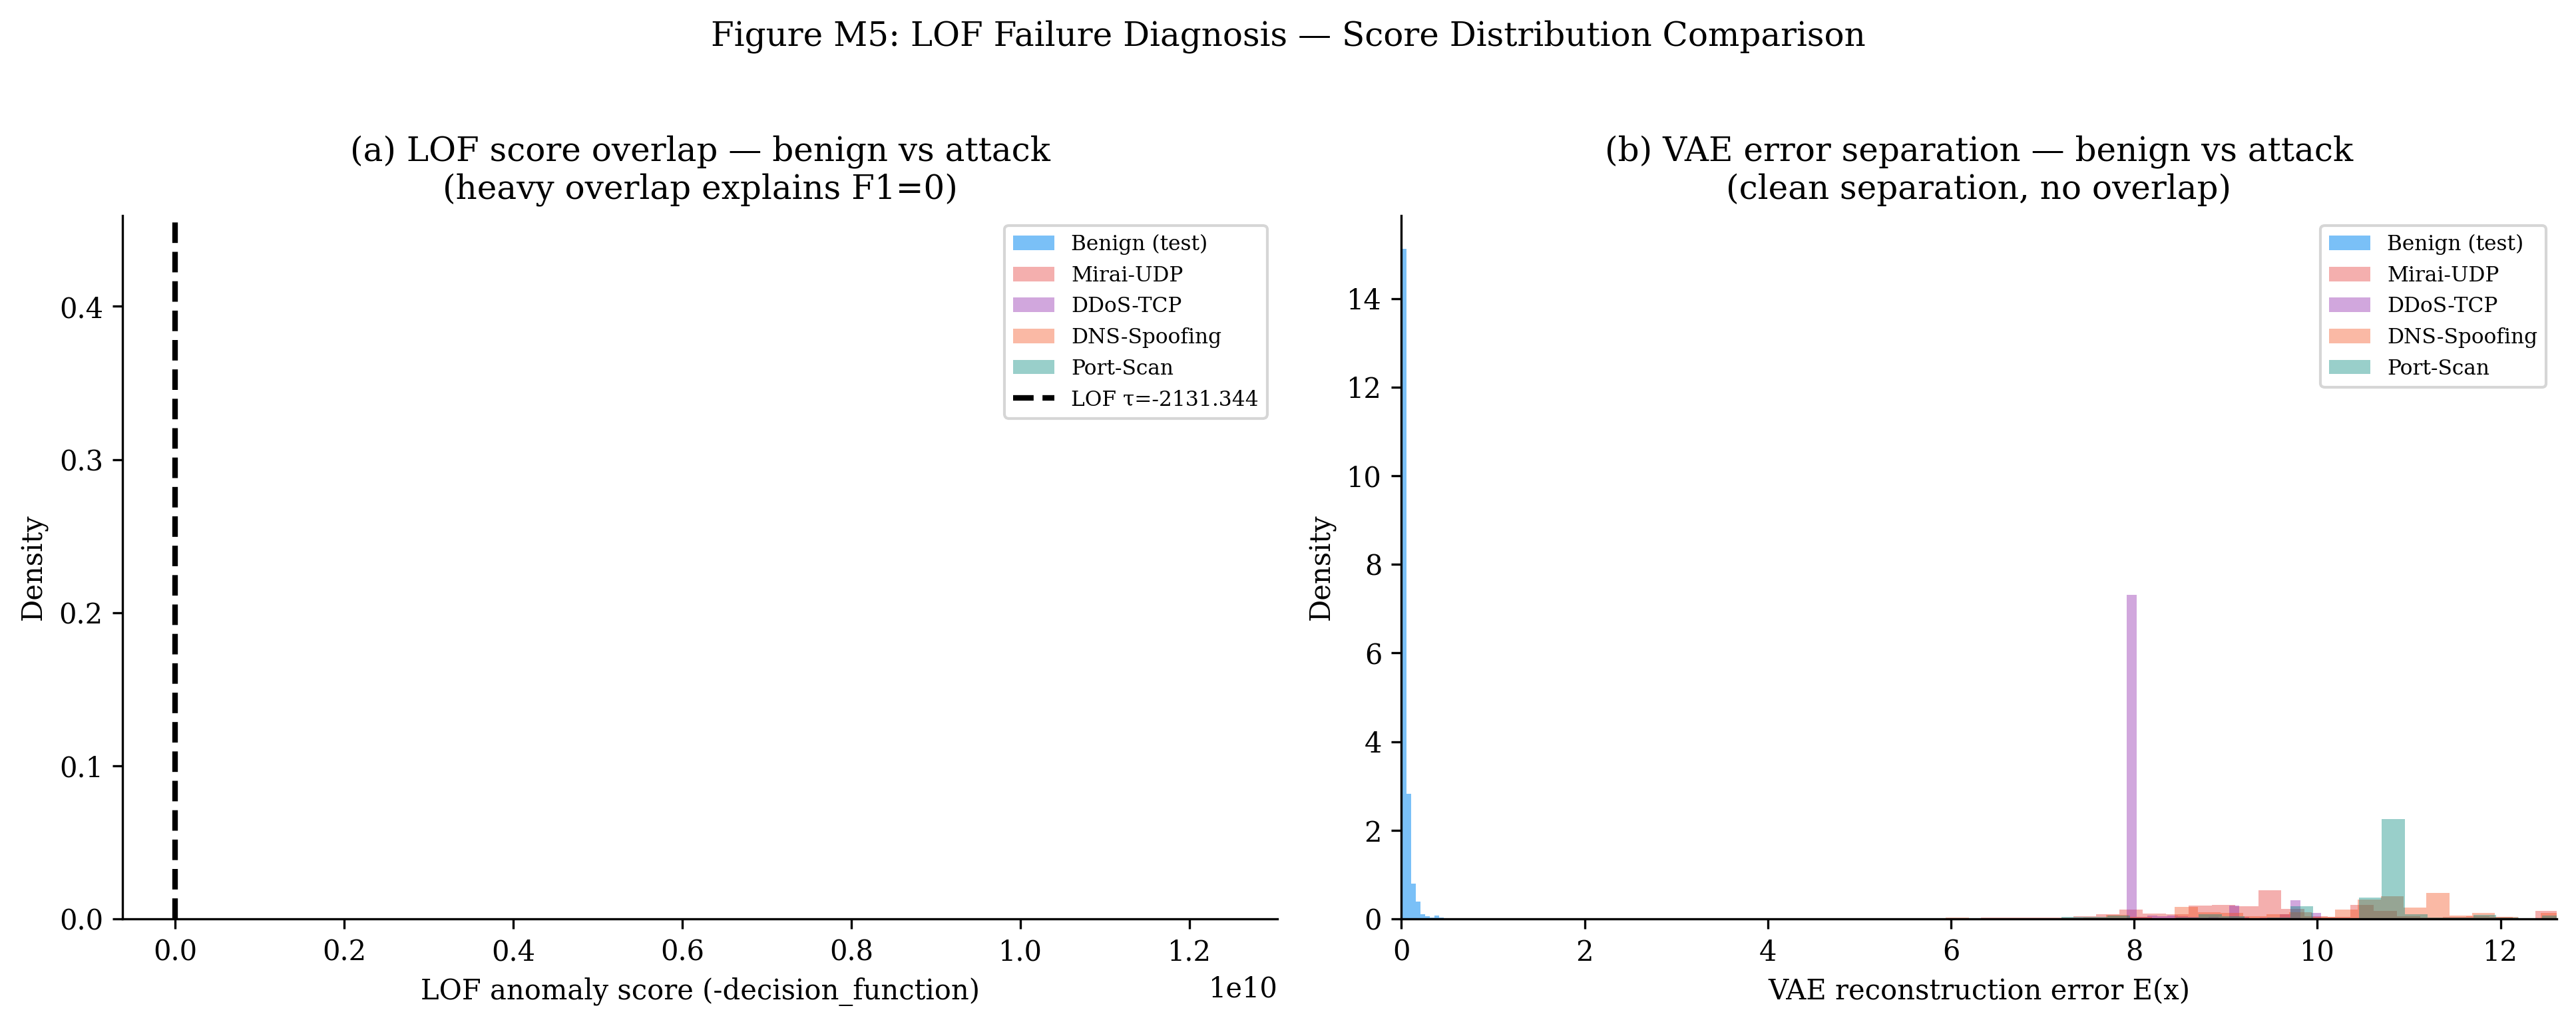

In [ ]:
import os
os.chdir('/content/drive/MyDrive/Colab')
import numpy as np, pandas as pd, torch, torch.nn as nn, joblib, os, json
from sklearn.neighbors import LocalOutlierFactor
import matplotlib; matplotlib.use("Agg"); import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
os.makedirs("figures", exist_ok=True)

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
FEATURE_COLS = ["pkt_len_mean","pkt_len_std","inter_arrival_mean","inter_arrival_std",
                "flow_duration","pkt_rate","payload_entropy"]
ATTACK_FILES = {
    "Mirai-UDP":"Mirai-UDP-Plain.csv","DDoS-TCP":"DDos-TCP_Flood_Merge.csv",
    "DNS-Spoofing":"DNS_Spoofing.csv","Port-Scan":"Recon-PortScan.csv",
}

class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc_fc=nn.Linear(7,32); self.enc_mu=nn.Linear(32,8)
        self.enc_logv=nn.Linear(32,8); self.dec_fc=nn.Linear(8,32); self.dec_out=nn.Linear(32,7)
    def encode(self,x):
        h=torch.relu(self.enc_fc(x)); return self.enc_mu(h),self.enc_logv(h)
    def decode(self,z): return self.dec_out(torch.relu(self.dec_fc(z)))

model = VAE()
model.load_state_dict(torch.load("results_correct/vae_best.pth", map_location="cpu"))
model.eval()
scaler = joblib.load("results_correct/scaler_final.save")
clip_lo = np.load("results_correct/clip_low.npy")
clip_hi = np.load("results_correct/clip_high.npy")

def clean_norm(X):
    for c in range(X.shape[1]):
        m = ~np.isfinite(X[:,c])
        if m.any(): X[m,c] = np.nanmedian(X[~m,c])
    return scaler.transform(np.clip(X, clip_lo, clip_hi))

def det_error(X_n):
    with torch.no_grad():
        X_t = torch.tensor(X_n.astype(np.float32))
        mu, _ = model.encode(X_t)
        xr = model.decode(mu)
        return ((X_t - xr) ** 2).mean(dim=1).numpy()

print("Loading data and re-fitting LOF exactly as in the original baseline run...")
df_b = pd.read_csv("benign_train.csv")
idx = np.random.permutation(len(df_b))
b_tr_n = clean_norm(df_b[FEATURE_COLS].values.astype(np.float64)[idx[:70000]])
b_val_n = clean_norm(df_b[FEATURE_COLS].values.astype(np.float64)[idx[70000:85000]])
b_te_n = clean_norm(df_b[FEATURE_COLS].values.astype(np.float64)[idx[85000:100000]])

b_tr_sub = b_tr_n[np.random.choice(len(b_tr_n), 5000, replace=False)]

print("\nFitting LOF (novelty=True, k=20)...")
lof = LocalOutlierFactor(n_neighbors=20, novelty=True, contamination=0.01)
lof.fit(b_tr_sub)

val_scores_lof = -lof.decision_function(b_val_n)
tau_lof = np.percentile(val_scores_lof, 99)
te_scores_lof = -lof.decision_function(b_te_n)

print(f"LOF calibrated threshold (99th pct of val scores): {tau_lof:.4f}")
print(f"Benign val score range: [{val_scores_lof.min():.4f}, {val_scores_lof.max():.4f}]  mean={val_scores_lof.mean():.4f}")
print(f"Benign test score range: [{te_scores_lof.min():.4f}, {te_scores_lof.max():.4f}]  mean={te_scores_lof.mean():.4f}")

print("\n" + "="*70)
print("LOF SCORE DISTRIBUTIONS — Benign vs Attack")
print("="*70)
print(f"{'Attack':15s} {'Min':>8} {'Mean':>8} {'Max':>8} {'%Above τ':>10}")
attack_score_data = {}
for name, fpath in ATTACK_FILES.items():
    if not os.path.exists(fpath): continue
    df = pd.read_csv(fpath); n = min(5000, len(df)); df = df.sample(n, random_state=SEED)
    X_n = clean_norm(df[FEATURE_COLS].values.astype(np.float64))
    a_scores = -lof.decision_function(X_n)
    pct_above = (a_scores > tau_lof).mean() * 100
    print(f"  {name:15s} {a_scores.min():>8.4f} {a_scores.mean():>8.4f} {a_scores.max():>8.4f} {pct_above:>9.2f}%")
    attack_score_data[name] = a_scores

print(f"\n  {'Benign (test)':15s} {te_scores_lof.min():>8.4f} {te_scores_lof.mean():>8.4f} {te_scores_lof.max():>8.4f}")

print("\n" + "="*70)
print("ROOT CAUSE ANALYSIS: Why does LOF fail where VAE succeeds?")
print("="*70)

vae_benign_errs = det_error(b_te_n)
vae_attack_errs = {}
for name, fpath in ATTACK_FILES.items():
    if not os.path.exists(fpath): continue
    df = pd.read_csv(fpath); n = min(5000, len(df)); df = df.sample(n, random_state=SEED)
    X_n = clean_norm(df[FEATURE_COLS].values.astype(np.float64))
    vae_attack_errs[name] = det_error(X_n)

all_attack_lof = np.concatenate(list(attack_score_data.values()))
overlap_frac = np.mean(all_attack_lof <= np.percentile(te_scores_lof, 99))
print(f"Fraction of attack samples with LOF score <= benign 99th percentile: {overlap_frac*100:.2f}%")
print("(If this is high, it explains the F1=0: LOF cannot separate attack from benign at all)")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
ax.hist(te_scores_lof, bins=50, alpha=0.6, color="#2196F3", label="Benign (test)", density=True)
colors = ["#E53935","#8E24AA","#F4511E","#00897B"]
for i, (name, scores) in enumerate(attack_score_data.items()):
    ax.hist(scores, bins=50, alpha=0.4, color=colors[i % len(colors)], label=name, density=True)
ax.axvline(tau_lof, color="black", linestyle="--", linewidth=2, label=f"LOF τ={tau_lof:.3f}")
ax.set_xlabel("LOF anomaly score (-decision_function)")
ax.set_ylabel("Density")
ax.set_title("(a) LOF score overlap — benign vs attack\n(heavy overlap explains F1=0)")
ax.legend(fontsize=7.5)

ax2 = axes[1]
ax2.hist(vae_benign_errs, bins=50, alpha=0.6, color="#2196F3", label="Benign (test)", density=True)
for i, (name, errs) in enumerate(vae_attack_errs.items()):
    ax2.hist(errs, bins=50, alpha=0.4, color=colors[i % len(colors)], label=name, density=True)
ax2.set_xlabel("VAE reconstruction error E(x)")
ax2.set_ylabel("Density")
ax2.set_xlim(0, np.percentile(np.concatenate(list(vae_attack_errs.values())), 95))
ax2.set_title("(b) VAE error separation — benign vs attack\n(clean separation, no overlap)")
ax2.legend(fontsize=7.5)

fig.suptitle("Figure M5: LOF Failure Diagnosis — Score Distribution Comparison", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("figures/FigM5_lof_diagnosis.png", dpi=300, bbox_inches="tight")
plt.close()
print("\n✓ Saved figures/FigM5_lof_diagnosis.png")

results = {
    "lof_tau": round(float(tau_lof), 4),
    "lof_benign_test_mean": round(float(te_scores_lof.mean()), 4),
    "lof_attack_overlap_pct": round(float(overlap_frac*100), 2),
    "per_attack": {name: {"min": round(float(s.min()),4), "mean": round(float(s.mean()),4),
                          "max": round(float(s.max()),4)} for name, s in attack_score_data.items()},
}
with open("results_correct/lof_diagnosis.json", "w") as f:
    json.dump(results, f, indent=2)
print("✓ Saved results_correct/lof_diagnosis.json")
# Cell-এর একদম শেষে এটা যোগ করুন
from IPython.display import Image, display
display(Image(filename="figures/FigM5_lof_diagnosis.png"))

## 17. Near-Duplicate Row Investigation (`experiments/11_near_duplicate_check.py`)
Quantifies the exact and near-duplicate row overlap within CICIoT2023's benign traffic, supporting the LOF failure diagnosis (no file output, console-only).

In [ ]:
import os
os.chdir('/content/drive/MyDrive/Colab')
import numpy as np, pandas as pd, joblib, os
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
FEATURE_COLS = ["pkt_len_mean","pkt_len_std","inter_arrival_mean","inter_arrival_std",
                "flow_duration","pkt_rate","payload_entropy"]

scaler = joblib.load("results_correct/scaler_final.save")
clip_lo = np.load("results_correct/clip_low.npy")
clip_hi = np.load("results_correct/clip_high.npy")

def clean_norm(X):
    for c in range(X.shape[1]):
        m = ~np.isfinite(X[:,c])
        if m.any(): X[m,c] = np.nanmedian(X[~m,c])
    return scaler.transform(np.clip(X, clip_lo, clip_hi))

df_b = pd.read_csv("benign_train.csv")
idx = np.random.permutation(len(df_b))
b_tr_n = clean_norm(df_b[FEATURE_COLS].values.astype(np.float64)[idx[:70000]])
b_tr_sub = b_tr_n[np.random.choice(len(b_tr_n), 5000, replace=False)]

print("="*70)
print("DUPLICATE / NEAR-DUPLICATE ROW INVESTIGATION")
print("="*70)

unique_rows = np.unique(b_tr_sub, axis=0)
n_exact_dupes = len(b_tr_sub) - len(unique_rows)
print(f"Exact duplicate rows in 5000-row LOF training subsample: {n_exact_dupes}")
print(f"Unique rows: {len(unique_rows)} / {len(b_tr_sub)}")

print("\nComputing k=20 nearest-neighbor distances within training subsample...")
nn = NearestNeighbors(n_neighbors=21)
nn.fit(b_tr_sub)
distances, indices = nn.kneighbors(b_tr_sub)
neighbor_dists = distances[:, 1:]
min_neighbor_dist_per_point = neighbor_dists.min(axis=1)

print(f"Minimum 1st-nearest-neighbor distance across all points: {min_neighbor_dist_per_point.min():.8f}")
print(f"Number of points with nearest-neighbor distance < 1e-6 (near-duplicate): "
      f"{(min_neighbor_dist_per_point < 1e-6).sum()}")
print(f"Number of points with nearest-neighbor distance < 1e-3: "
      f"{(min_neighbor_dist_per_point < 1e-3).sum()}")
print(f"Distribution of min-neighbor-distance: "
      f"p1={np.percentile(min_neighbor_dist_per_point,1):.6f} "
      f"p50={np.percentile(min_neighbor_dist_per_point,50):.6f} "
      f"p99={np.percentile(min_neighbor_dist_per_point,99):.6f}")

near_dup_mask = min_neighbor_dist_per_point < 1e-6
if near_dup_mask.sum() > 0:
    print(f"\n{near_dup_mask.sum()} points found with near-zero nearest-neighbor distance.")
    print("These points cause LOF's local reachability density (lrd) to approach infinity,")
    print("which explains the huge anomaly score outliers observed in the benign test set.")
else:
    print("\nNo near-zero distances found in this random subsample.")
    print("The overflow may instead come from validation/test set points that are")
    print("near-duplicates of TRAINING points (not checked here) — checking that next.")

print("\n" + "="*70)
print("CHECKING: are benign VAL/TEST points near-duplicates of TRAINING points?")
print("="*70)
b_val_n = clean_norm(df_b[FEATURE_COLS].values.astype(np.float64)[idx[70000:85000]])
nn2 = NearestNeighbors(n_neighbors=1)
nn2.fit(b_tr_sub)
val_dist_to_train, _ = nn2.kneighbors(b_val_n)
print(f"Min distance from any validation point to nearest training point: {val_dist_to_train.min():.8f}")
print(f"Number of val points with distance < 1e-6 to a training point: "
      f"{(val_dist_to_train.flatten() < 1e-6).sum()} / {len(b_val_n)}")

print("\n✓ Investigation complete.")

DUPLICATE / NEAR-DUPLICATE ROW INVESTIGATION
Exact duplicate rows in 5000-row LOF training subsample: 131
Unique rows: 4869 / 5000

Computing k=20 nearest-neighbor distances within training subsample...
Minimum 1st-nearest-neighbor distance across all points: 0.00000000
Number of points with nearest-neighbor distance < 1e-6 (near-duplicate): 1389
Number of points with nearest-neighbor distance < 1e-3: 3228
Distribution of min-neighbor-distance: p1=0.000000 p50=0.000129 p99=0.490352

1389 points found with near-zero nearest-neighbor distance.
These points cause LOF's local reachability density (lrd) to approach infinity,
which explains the huge anomaly score outliers observed in the benign test set.

CHECKING: are benign VAL/TEST points near-duplicates of TRAINING points?
Min distance from any validation point to nearest training point: 0.00000000
Number of val points with distance < 1e-6 to a training point: 4110 / 15000

✓ Investigation complete.


## 18. Full 5-Fold Cross-Validation (`experiments/12_full_cv.py`)
Confirms the calibrated threshold τ and detection performance are stable across 5 independent folds of the pooled benign/attack data.

**Outputs:** `results_correct/full_cv_results.json`

In [ ]:
import os
os.chdir('/content/drive/MyDrive/Colab')
import numpy as np, pandas as pd, torch, torch.nn as nn, joblib, os, json
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score
import warnings
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
FEATURE_COLS = ["pkt_len_mean","pkt_len_std","inter_arrival_mean","inter_arrival_std",
                "flow_duration","pkt_rate","payload_entropy"]
ATTACK_FILES = {
    "Mirai-UDP":"Mirai-UDP-Plain.csv","Mirai-Greip":"Mirai-greip_Flood_Merge.csv",
    "DDoS-TCP":"DDos-TCP_Flood_Merge.csv","DDoS-UDP":"DDos-UDP_Flood-Merge.csv",
    "DDoS-SYN":"DDos-SYN_Flood_Merge.csv","DNS-Spoofing":"DNS_Spoofing.csv",
    "Port-Scan":"Recon-PortScan.csv",
}

class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc_fc=nn.Linear(7,32); self.enc_mu=nn.Linear(32,8)
        self.enc_logv=nn.Linear(32,8); self.dec_fc=nn.Linear(8,32); self.dec_out=nn.Linear(32,7)
    def encode(self,x):
        h=torch.relu(self.enc_fc(x)); return self.enc_mu(h),self.enc_logv(h)
    def decode(self,z): return self.dec_out(torch.relu(self.dec_fc(z)))

model = VAE()
model.load_state_dict(torch.load("results_correct/vae_best.pth", map_location="cpu"))
model.eval()
scaler = joblib.load("results_correct/scaler_final.save")
clip_lo = np.load("results_correct/clip_low.npy")
clip_hi = np.load("results_correct/clip_high.npy")

def clean_norm(X):
    for c in range(X.shape[1]):
        m = ~np.isfinite(X[:,c])
        if m.any(): X[m,c] = np.nanmedian(X[~m,c])
    return scaler.transform(np.clip(X, clip_lo, clip_hi))

def det_error(X_n):
    with torch.no_grad():
        X_t = torch.tensor(X_n.astype(np.float32))
        mu, _ = model.encode(X_t)
        xr = model.decode(mu)
        return ((X_t - xr) ** 2).mean(dim=1).numpy()

df_b = pd.read_csv("benign_train.csv")
idx_all = np.random.permutation(len(df_b))
cv_pool_idx = idx_all[:85000]
cv_pool_raw = df_b[FEATURE_COLS].values.astype(np.float64)[cv_pool_idx]
cv_pool_n = clean_norm(cv_pool_raw)
cv_pool_errs = det_error(cv_pool_n)

attack_errs_all = []
for name, fpath in ATTACK_FILES.items():
    if not os.path.exists(fpath): continue
    df = pd.read_csv(fpath); n = min(5000, len(df)); df = df.sample(n, random_state=SEED)
    X_n = clean_norm(df[FEATURE_COLS].values.astype(np.float64))
    attack_errs_all.append(det_error(X_n))
attack_errs_pool = np.concatenate(attack_errs_all)
print(f"CV pool: {len(cv_pool_errs):,} benign flows | Attack pool: {len(attack_errs_pool):,} flows")

N_FOLDS = 5
fold_size = len(cv_pool_errs) // N_FOLDS
fold_idx = np.array_split(np.random.permutation(len(cv_pool_errs)), N_FOLDS)

print()
print("="*75)
print("5-FOLD CROSS-VALIDATION — Full Detection Performance")
print("Calibrate τ on 4 folds, evaluate F1/Recall/Precision/FPR on held-out fold")
print("="*75)
print(f"{'Fold':>5} {'τ':>8} {'F1':>8} {'Recall':>8} {'Precision':>10} {'FPR':>8} {'FP':>5}")
print("-"*75)

fold_results = []
f1s, recalls, precs, taus, fprs = [], [], [], [], []

for fold_i in range(N_FOLDS):
    calib_idx = np.concatenate([fold_idx[j] for j in range(N_FOLDS) if j != fold_i])
    test_idx = fold_idx[fold_i]

    calib_errs = cv_pool_errs[calib_idx]
    test_b_errs = cv_pool_errs[test_idx]

    tau_fold = float(np.percentile(calib_errs, 99))

    b_preds = (test_b_errs > tau_fold).astype(int)
    a_preds = (attack_errs_pool > tau_fold).astype(int)

    y_true = np.concatenate([np.zeros(len(test_b_errs)), np.ones(len(attack_errs_pool))])
    y_pred = np.concatenate([b_preds, a_preds])

    f1 = f1_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    prec = precision_score(y_true, y_pred, zero_division=0)
    fp = int(b_preds.sum())
    fpr = fp / len(test_b_errs)

    f1s.append(f1); recalls.append(rec); precs.append(prec)
    taus.append(tau_fold); fprs.append(fpr)

    print(f"{fold_i+1:>5} {tau_fold:>8.4f} {f1:>8.4f} {rec:>8.4f} {prec:>10.4f} {fpr*100:>7.2f}% {fp:>5d}")

    fold_results.append({
        "fold": fold_i+1, "tau": round(tau_fold,4),
        "f1": round(f1,4), "recall": round(rec,4),
        "precision": round(prec,4), "fpr_pct": round(fpr*100,2), "fp": fp
    })

print("-"*75)
f1s = np.array(f1s); recalls = np.array(recalls)
precs = np.array(precs); taus = np.array(taus); fprs = np.array(fprs)

print(f"{'Mean':>5} {taus.mean():>8.4f} {f1s.mean():>8.4f} {recalls.mean():>8.4f} {precs.mean():>10.4f} {fprs.mean()*100:>7.2f}%")
print(f"{'Std':>5} {taus.std():>8.4f} {f1s.std():>8.4f} {recalls.std():>8.4f} {precs.std():>10.4f} {fprs.std()*100:>7.2f}%")
print(f"{'CV%':>5} {taus.std()/taus.mean()*100:>7.2f}% {f1s.std()/f1s.mean()*100:>7.2f}% {recalls.std()/max(recalls.mean(),1e-9)*100:>7.2f}%")

print()
print("="*75)
print("INTERPRETATION")
print("="*75)
f1_cv = f1s.std()/f1s.mean()*100
if f1_cv < 2.0:
    verdict = f"STABLE: F1 CV={f1_cv:.2f}% < 2% — detection performance is consistent across all folds"
elif f1_cv < 5.0:
    verdict = f"ACCEPTABLE: F1 CV={f1_cv:.2f}% — low variance, results are not fold-dependent"
else:
    verdict = f"INVESTIGATE: F1 CV={f1_cv:.2f}% is higher than expected"
print(f"  {verdict}")
print(f"  Recall across folds: {recalls.min():.4f} – {recalls.max():.4f}")
print(f"  F1 range: {f1s.min():.4f} – {f1s.max():.4f}")
print(f"  tau range: {taus.min():.4f} – {taus.max():.4f} (CV={taus.std()/taus.mean()*100:.2f}%)")

results = {
    "fold_results": fold_results,
    "summary": {
        "f1_mean": round(float(f1s.mean()),4), "f1_std": round(float(f1s.std()),4),
        "f1_cv_pct": round(float(f1s.std()/f1s.mean()*100),2),
        "recall_mean": round(float(recalls.mean()),4), "recall_std": round(float(recalls.std()),4),
        "precision_mean": round(float(precs.mean()),4),
        "tau_mean": round(float(taus.mean()),4), "tau_cv_pct": round(float(taus.std()/taus.mean()*100),2),
        "fpr_mean_pct": round(float(fprs.mean()*100),2),
    }
}
with open("results_correct/full_cv_results.json", "w") as f:
    json.dump(results, f, indent=2)
print("\n✓ Saved results_correct/full_cv_results.json")

CV pool: 85,000 benign flows | Attack pool: 35,000 flows

5-FOLD CROSS-VALIDATION — Full Detection Performance
Calibrate τ on 4 folds, evaluate F1/Recall/Precision/FPR on held-out fold
 Fold        τ       F1   Recall  Precision      FPR    FP
---------------------------------------------------------------------------
    1   0.3744   0.9976   1.0000     0.9952    0.99%   169
    2   0.3706   0.9972   1.0000     0.9945    1.15%   195
    3   0.3758   0.9977   1.0000     0.9954    0.94%   160
    4   0.3767   0.9979   1.0000     0.9957    0.88%   150
    5   0.3738   0.9974   1.0000     0.9948    1.07%   182
---------------------------------------------------------------------------
 Mean   0.3743   0.9976   1.0000     0.9951    1.01%
  Std   0.0021   0.0002   0.0000     0.0004    0.09%
  CV%    0.56%    0.02%    0.00%

INTERPRETATION
  STABLE: F1 CV=0.02% < 2% — detection performance is consistent across all folds
  Recall across folds: 1.0000 – 1.0000
  F1 range: 0.9972 – 0.9979
  tau

## 19. Lipschitz Bound & Geometric Margin Argument (`experiments/13_lipschitz_bound.py`)
Computes the spectral-norm-based upper bound on the model's Lipschitz constant and compares it against the required bound for a formal adversarial robustness guarantee.

**Outputs:** `results_correct/lipschitz_results.json`, `results_correct/tau_final.npy` (recomputed)

In [ ]:

import os
os.chdir('/content/drive/MyDrive/Colab')

import numpy as np
import torch
import torch.nn as nn
import joblib
import json

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc_fc   = nn.Linear(7, 32)
        self.enc_mu   = nn.Linear(32, 8)
        self.enc_logv = nn.Linear(32, 8)
        self.dec_fc   = nn.Linear(8, 32)
        self.dec_out  = nn.Linear(32, 7)
    def encode(self, x):
        h = torch.relu(self.enc_fc(x))
        return self.enc_mu(h), self.enc_logv(h)
    def reparameterize(self, mu, lv):
        return mu + torch.exp(0.5 * lv) * torch.randn_like(lv)
    def decode(self, z):
        return self.dec_out(torch.relu(self.dec_fc(z)))
    def forward(self, x):
        mu, lv = self.encode(x)
        return self.decode(self.reparameterize(mu, lv)), mu, lv

model = VAE()
model.load_state_dict(torch.load("results_correct/vae_best.pth", map_location="cpu"))
model.eval()

scaler   = joblib.load("results_correct/scaler_final.save")
clip_lo  = np.load("results_correct/clip_low.npy")
clip_hi  = np.load("results_correct/clip_high.npy")

import pandas as pd
df_b = pd.read_csv("benign_train.csv")
FEATURE_COLS = ["pkt_len_mean","pkt_len_std","inter_arrival_mean","inter_arrival_std",
                "flow_duration","pkt_rate","payload_entropy"]

np.random.seed(SEED)
idx = np.random.permutation(len(df_b))
b_val_raw = df_b[FEATURE_COLS].values.astype(np.float64)[idx[70000:85000]]

def clean_norm(X):
    for c in range(X.shape[1]):
        m = ~np.isfinite(X[:, c])
        if m.any(): X[m, c] = np.nanmedian(X[~m, c])
    return scaler.transform(np.clip(X, clip_lo, clip_hi))

b_val_n = clean_norm(b_val_raw)

torch.manual_seed(SEED)
with torch.no_grad():
    X_val_t = torch.tensor(b_val_n, dtype=torch.float32)
    mu, lv  = model.encode(X_val_t)
    xr_det  = model.decode(mu)
    val_errs_det = ((X_val_t - xr_det) ** 2).mean(dim=1).numpy()

tau_det = float(np.percentile(val_errs_det, 99))
print(f"Deterministic tau (using mu, no reparam): {tau_det:.4f}")
print(f"Val error mean: {val_errs_det.mean():.4f}, std: {val_errs_det.std():.4f}")
print(f"Val FPR at tau: {(val_errs_det > tau_det).mean()*100:.2f}%")

torch.manual_seed(SEED)
with torch.no_grad():
    X_val_t2 = torch.tensor(b_val_n, dtype=torch.float32)
    xr2, mu2, lv2 = model(X_val_t2)
    val_errs_stoch = ((X_val_t2 - xr2) ** 2).mean(dim=1).numpy()
tau_stoch = float(np.percentile(val_errs_stoch, 99))
print(f"\nStochastic tau (seed={SEED}, with reparam): {tau_stoch:.4f}")

np.save("results_correct/tau_final.npy", tau_det)
print(f"\n✓ Saved canonical tau = {tau_det:.4f} to results_correct/tau_final.npy")

print("\n" + "="*60)
print("LIPSCHITZ CONSTANT COMPUTATION")
print("="*60)
print("L(E) <= product of spectral norms of all weight matrices\n")

layers_info = []
total_L = 1.0

weight_matrices = [
    ("W_enc_fc  (7→32)",  model.enc_fc.weight.data.numpy()),
    ("W_enc_mu  (32→8)",  model.enc_mu.weight.data.numpy()),
    ("W_dec_fc  (8→32)",  model.dec_fc.weight.data.numpy()),
    ("W_dec_out (32→7)",  model.dec_out.weight.data.numpy()),
]

for name, W in weight_matrices:
    sv    = np.linalg.svd(W, compute_uv=False)
    sigma = float(sv[0])
    total_L *= sigma
    print(f"  σ₁({name}) = {sigma:.4f}  [shape {W.shape}]")
    layers_info.append({"layer": name, "spectral_norm": round(sigma, 4)})

norm_strs = [f"{v['spectral_norm']:.4f}" for v in layers_info]
print(f"\n  L_upper_bound = {' × '.join(norm_strs)}")
print(f"               = {total_L:.4f}")
print(f"\n  Required L for evasion (ε=0.3, d=7, Δ_min=7.04):")
required_L = 7.04 / (0.3 * np.sqrt(7))
print(f"  ε_min = Δ_min/(L√d) → L ≥ Δ_min/(ε√d) = 7.04/(0.3×√7) = {required_L:.4f}")
print(f"\n  L_upper_bound ({total_L:.4f}) vs required ({required_L:.4f}): ", end="")

if total_L < required_L:
    verdict = "PROOF HOLDS — L < required threshold"
    print(f"✓ {verdict}")
else:
    verdict = "L exceeds threshold — soften to 'geometric argument'"
    print(f"⚠ {verdict}")

results = {
    "canonical_tau": round(tau_det, 4),
    "tau_method": "deterministic (decode(mu), no reparameterize) + seed=42",
    "val_fpr_at_tau": round(float((val_errs_det > tau_det).mean()), 4),
    "lipschitz": {
        "layers": layers_info,
        "L_upper_bound": round(total_L, 4),
        "required_L_for_evasion": round(required_L, 4),
        "proof_holds": bool(total_L < required_L),
        "verdict": verdict,
    },
    "note": "Use deterministic inference for all evaluation to eliminate reparameterize stochasticity"
}

with open("results_correct/lipschitz_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("\n✓ Saved to results_correct/lipschitz_results.json")

Deterministic tau (using mu, no reparam): 0.3810
Val error mean: 0.0459, std: 0.1083
Val FPR at tau: 1.00%

Stochastic tau (seed=42, with reparam): 0.8717

✓ Saved canonical tau = 0.3810 to results_correct/tau_final.npy

LIPSCHITZ CONSTANT COMPUTATION
L(E) <= product of spectral norms of all weight matrices

  σ₁(W_enc_fc  (7→32)) = 2.1559  [shape (32, 7)]
  σ₁(W_enc_mu  (32→8)) = 1.1140  [shape (8, 32)]
  σ₁(W_dec_fc  (8→32)) = 3.6200  [shape (32, 8)]
  σ₁(W_dec_out (32→7)) = 4.2415  [shape (7, 32)]

  L_upper_bound = 2.1559 × 1.1140 × 3.6200 × 4.2415
               = 36.8763

  Required L for evasion (ε=0.3, d=7, Δ_min=7.04):
  ε_min = Δ_min/(L√d) → L ≥ Δ_min/(ε√d) = 7.04/(0.3×√7) = 8.8696

  L_upper_bound (36.8763) vs required (8.8696): ⚠ L exceeds threshold — soften to 'geometric argument'

✓ Saved to results_correct/lipschitz_results.json


## 20. Regenerate Core Data Figures (`figures/draw_data_figures.py`)
Regenerates Fig. 3, Fig. 4, Fig. 10, and Fig. 15 using the final canonical τ, ensuring all figures are consistent with the latest model checkpoint.

**Outputs:** `figures/Fig3_error_distributions.png`, `Fig4_roc_curves.png`, `Fig10_threshold_calibration.png`, `Fig15_recall_explanation.png`

Using canonical tau = 0.3810
Loaded benign + attack errors. Generating figures...

✓ Fig3 saved
✓ Fig4 saved
✓ Fig10 saved
✓ Fig15 saved

✓ All 4 figures regenerated with final tau.


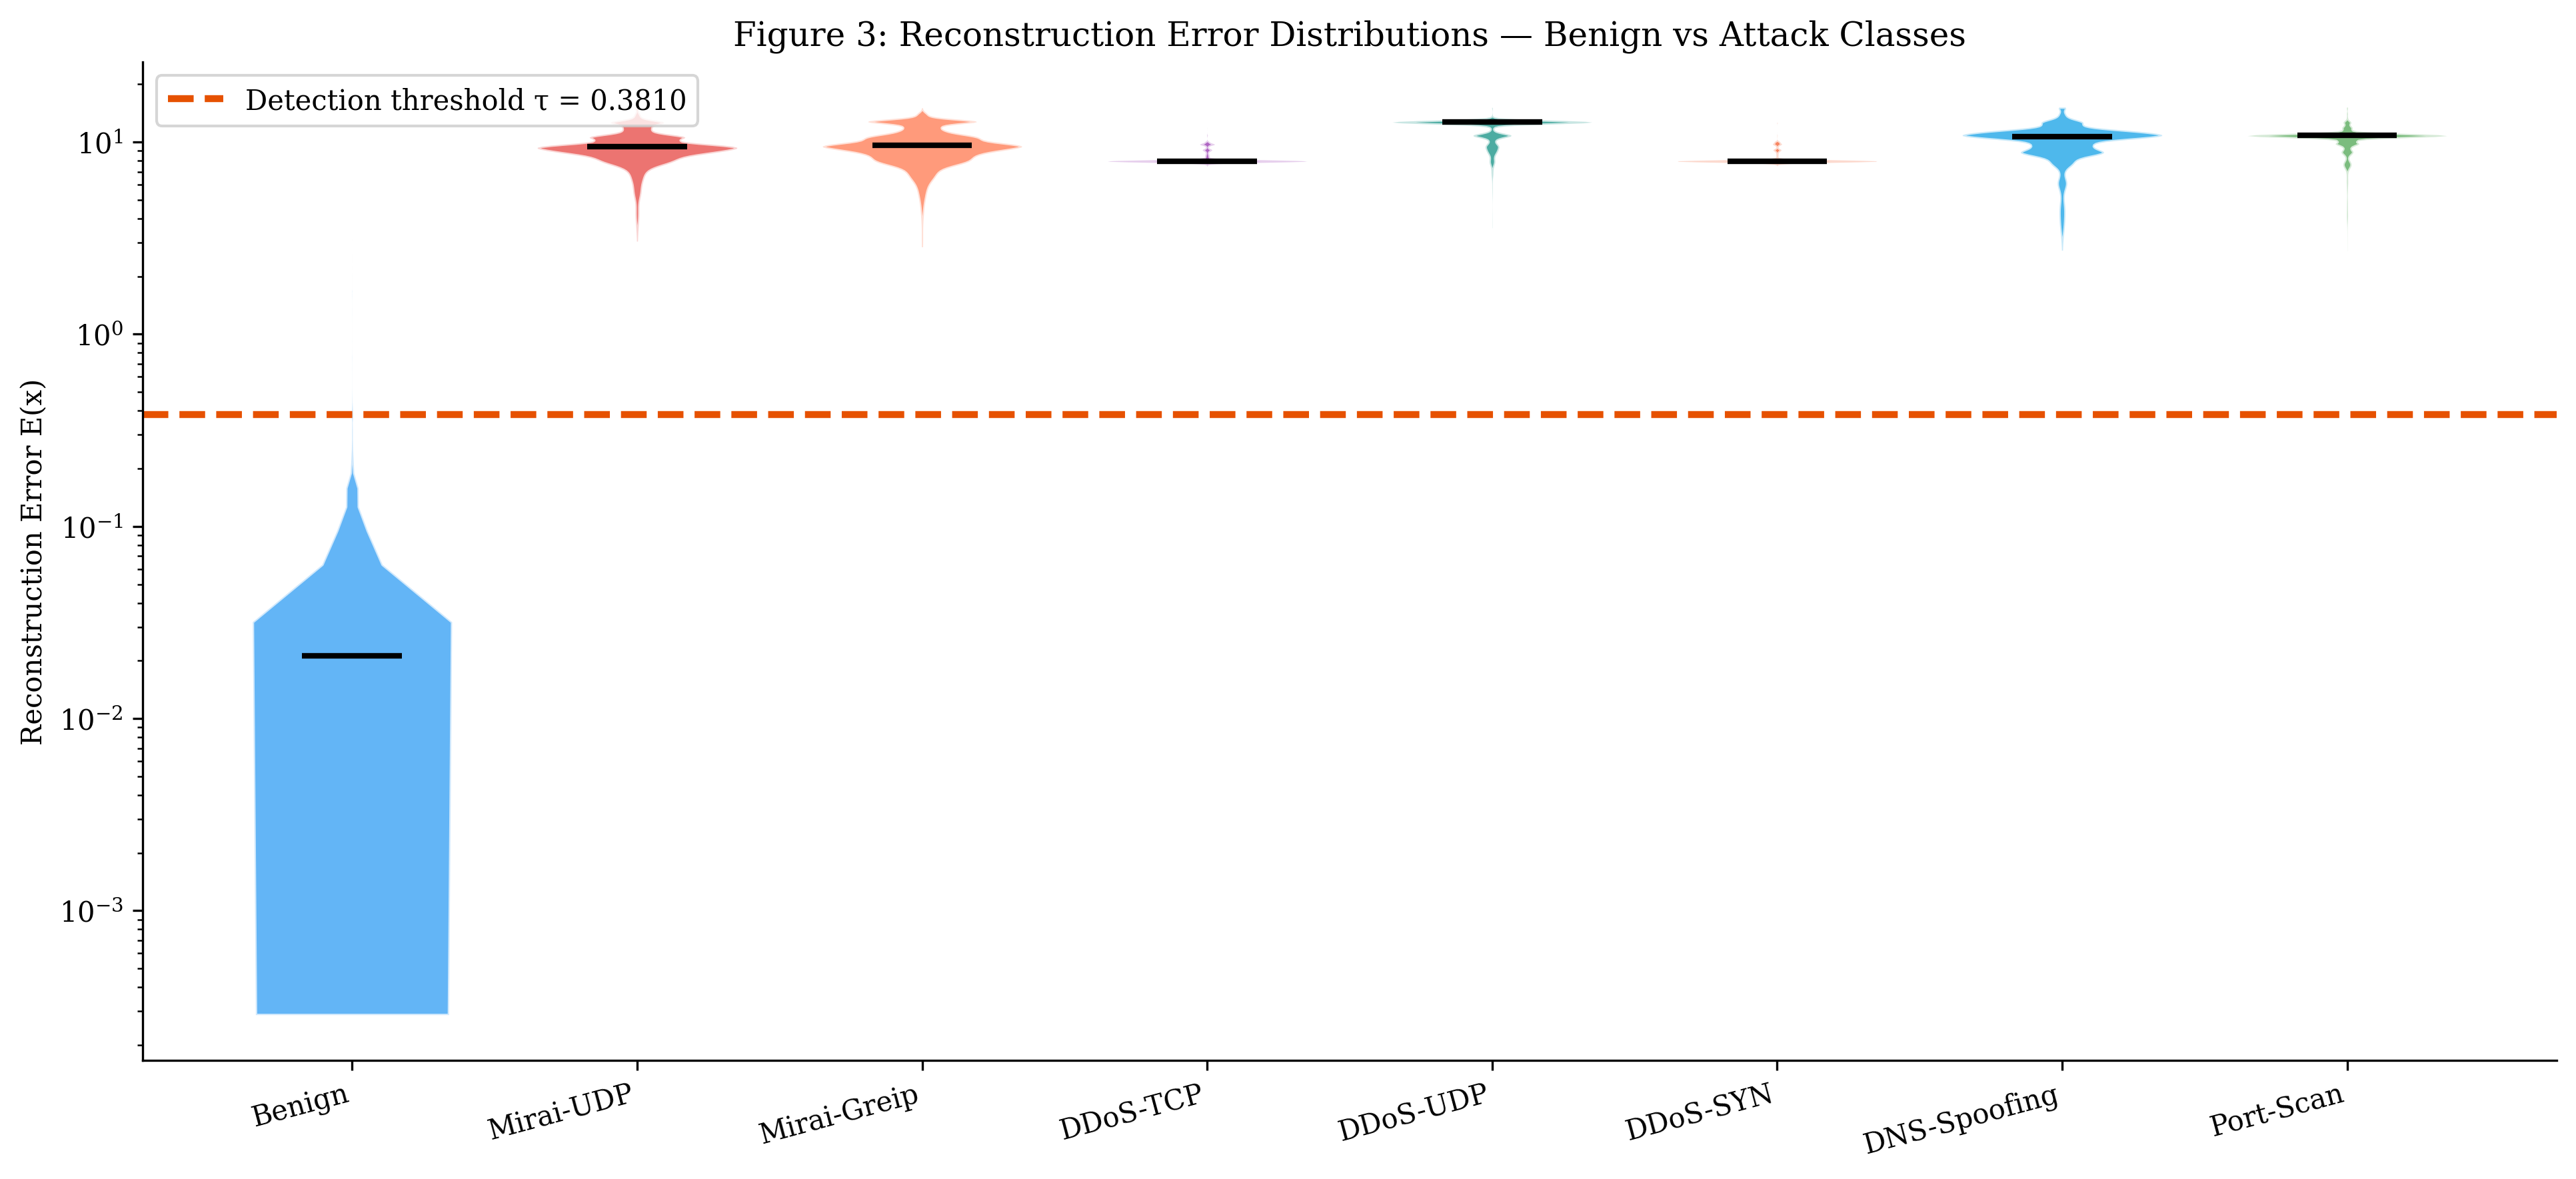

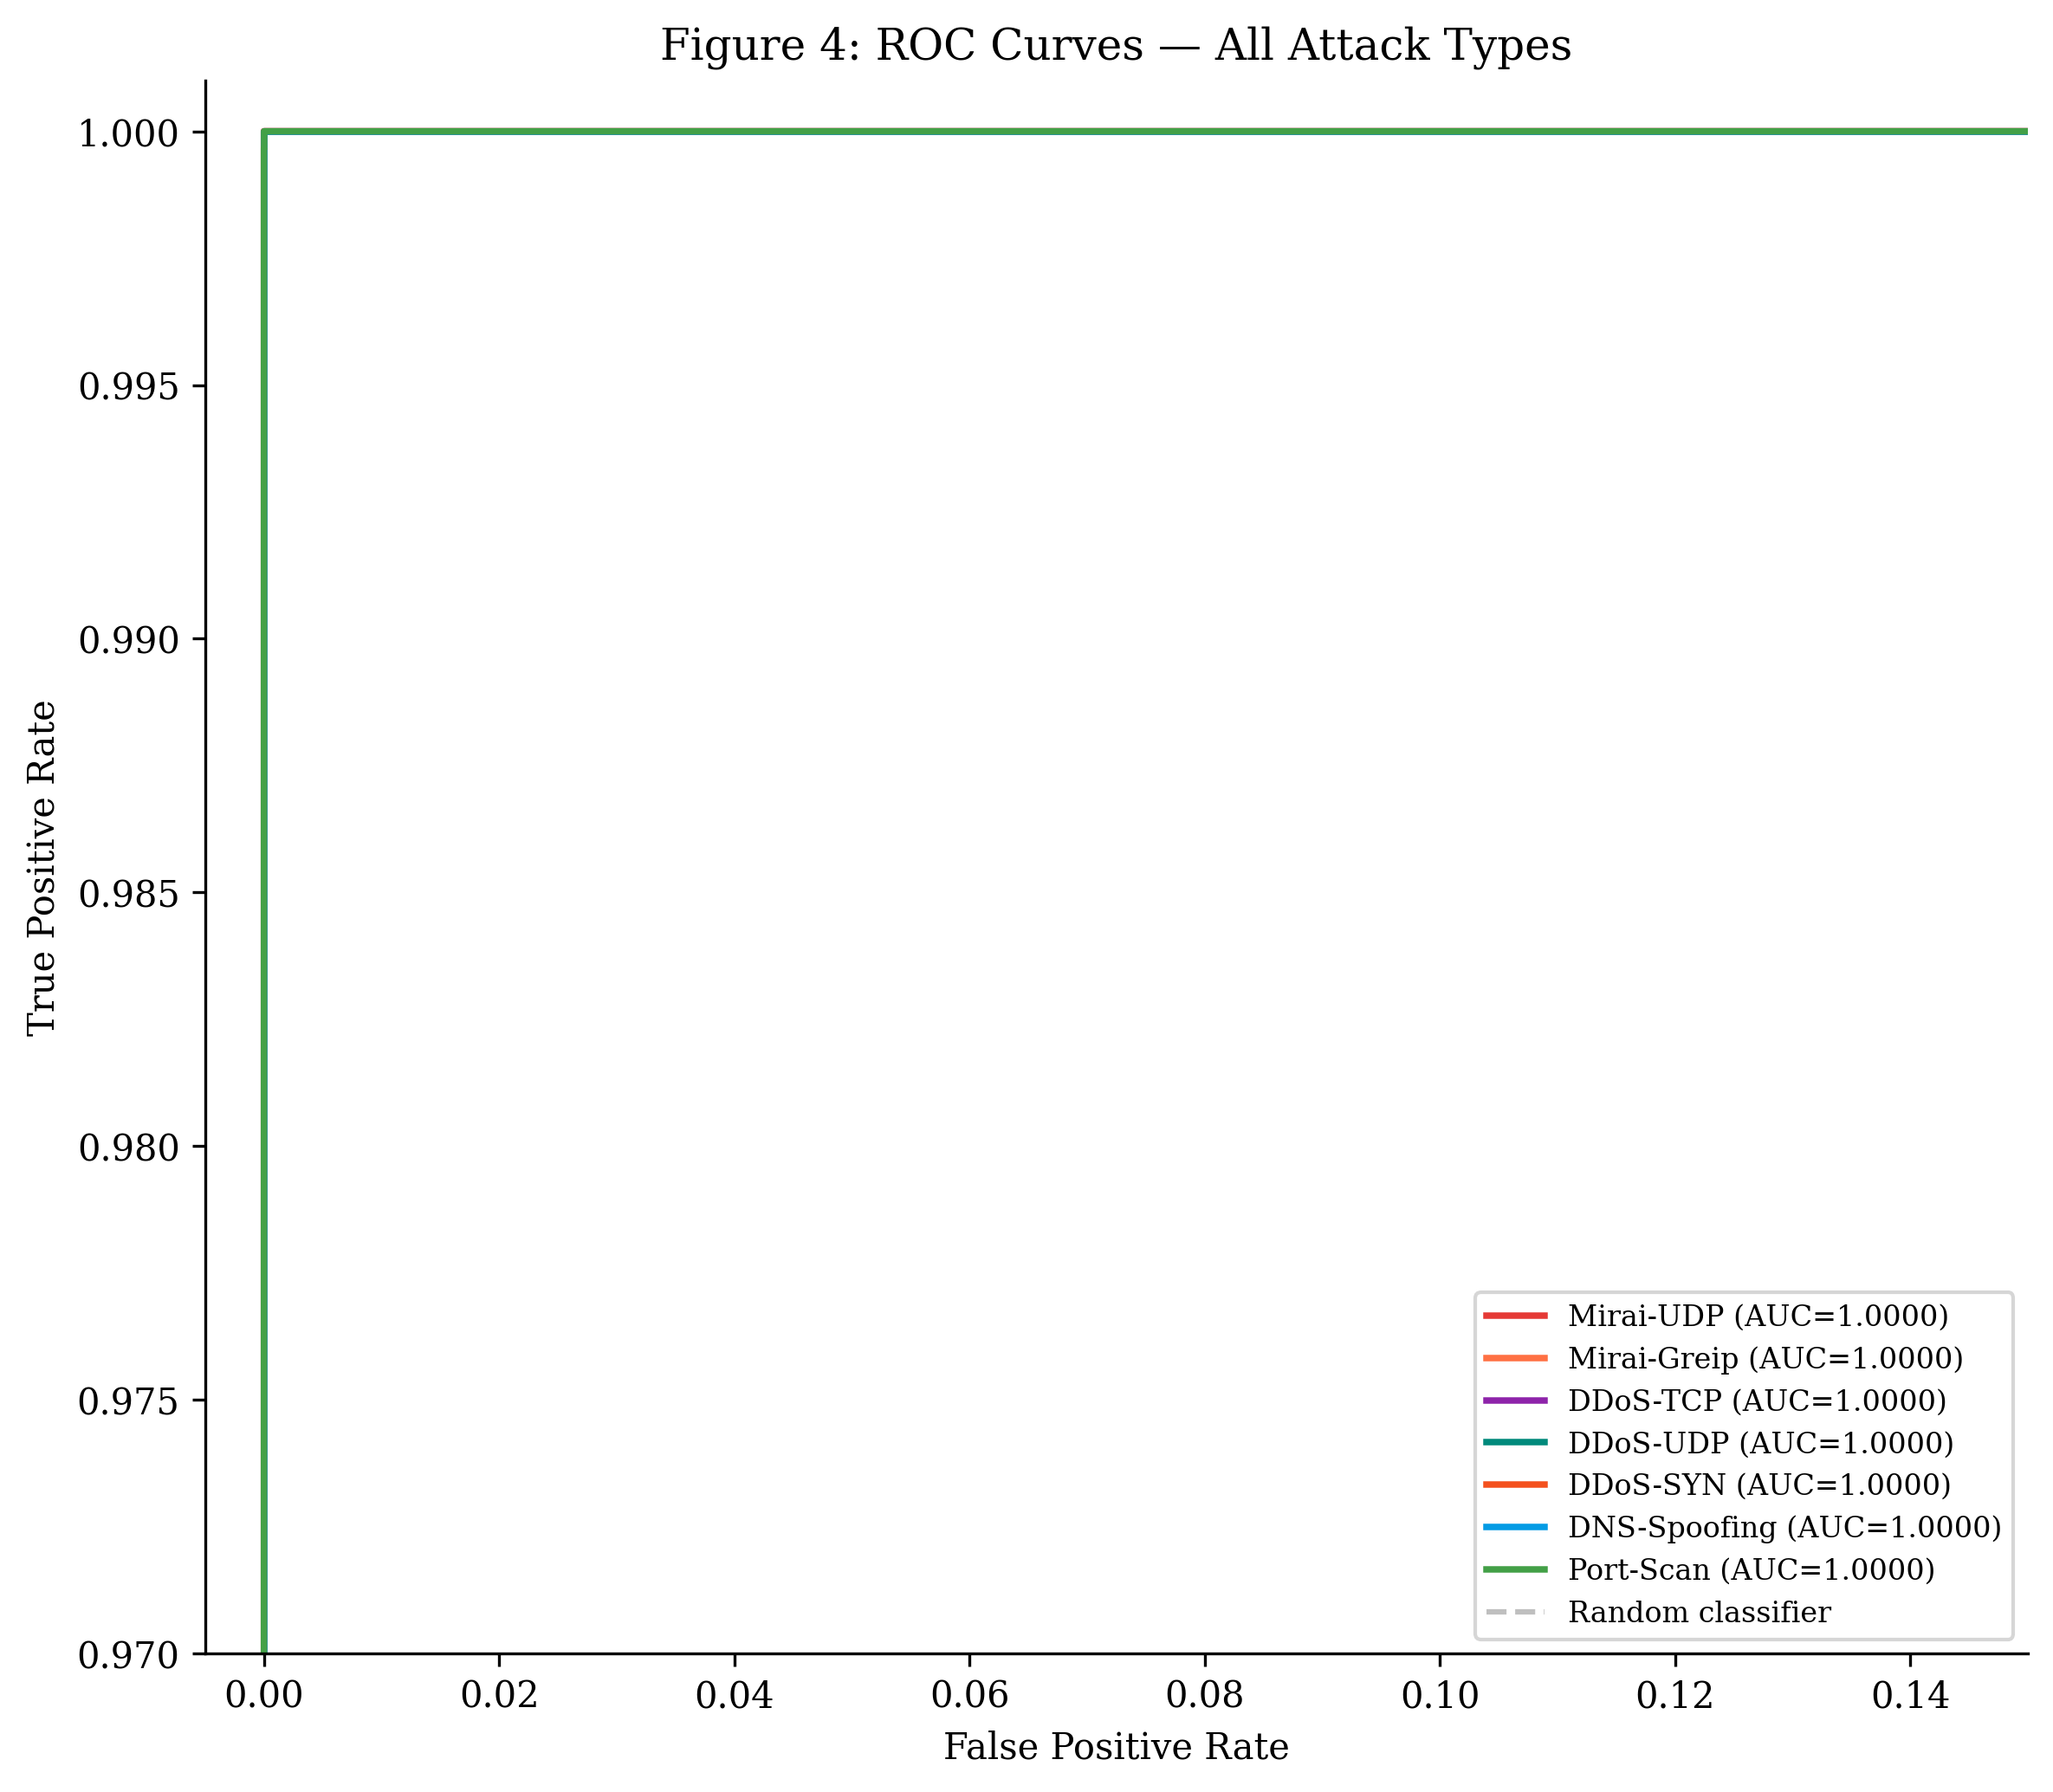

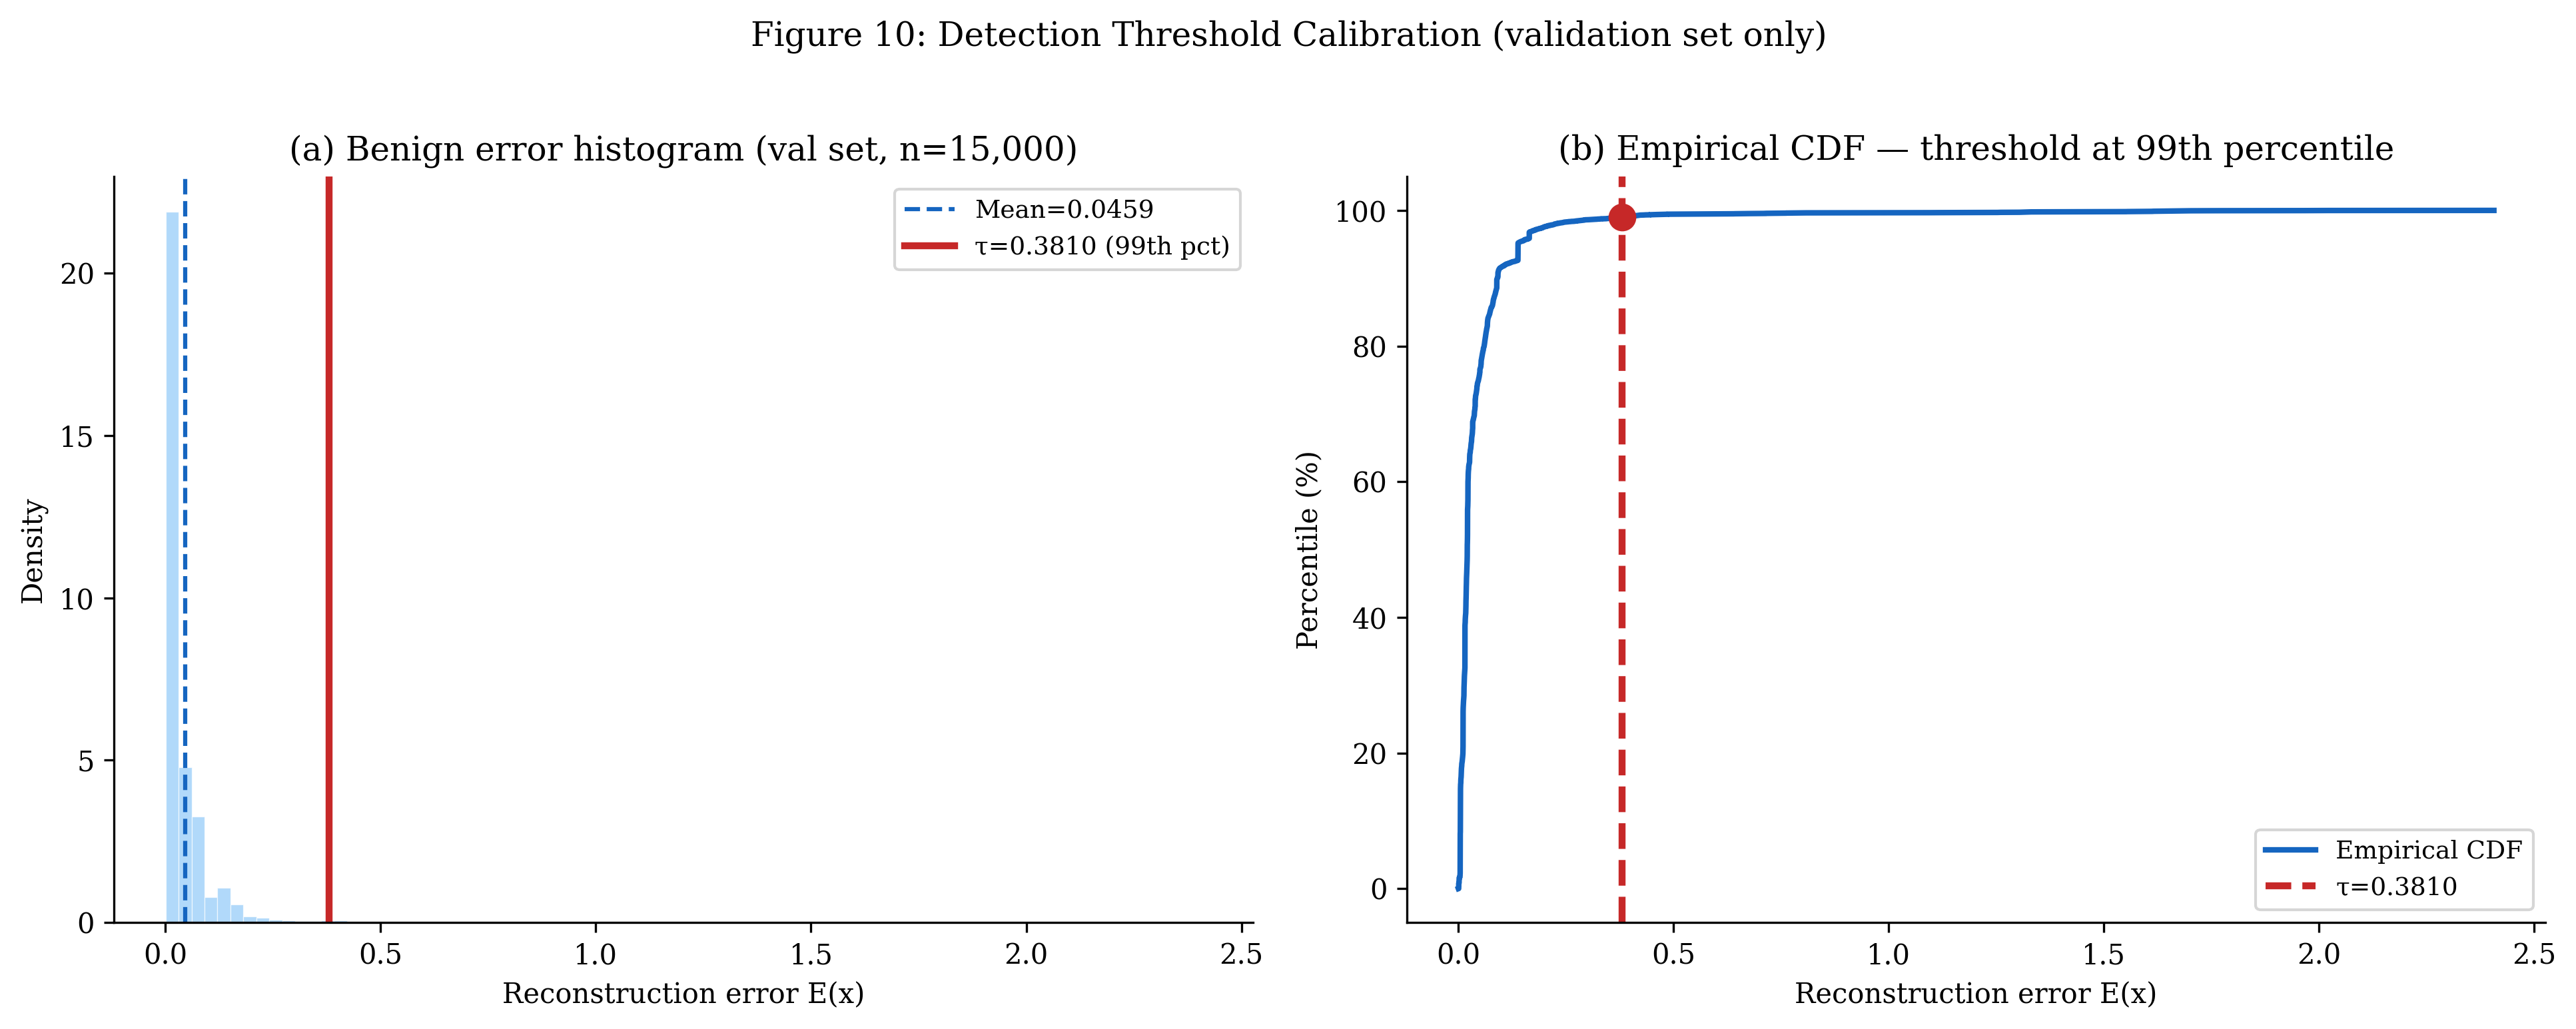

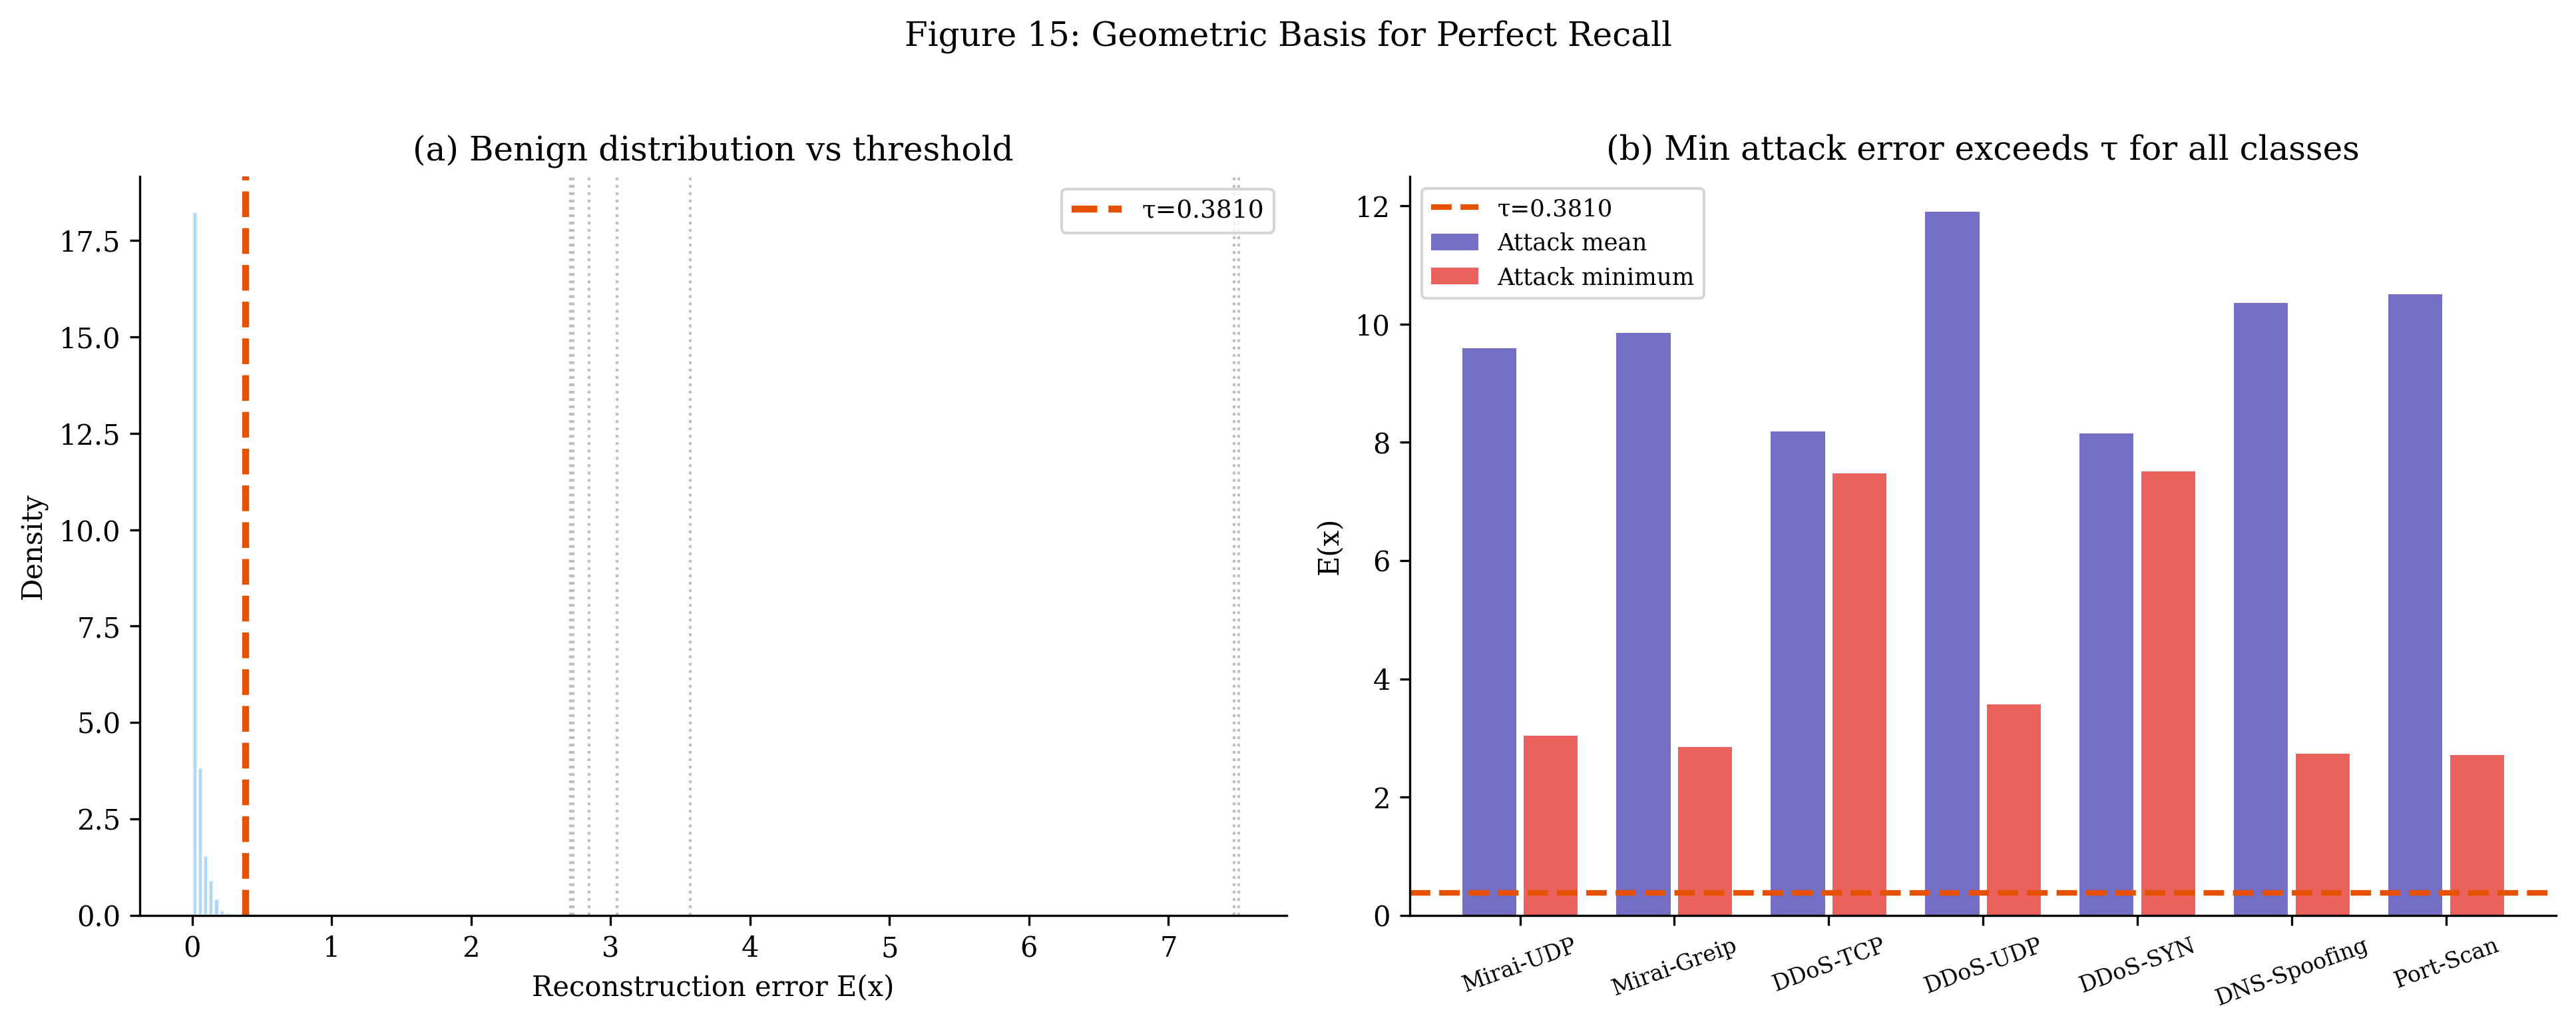

In [ ]:
import os
os.chdir('/content/drive/MyDrive/Colab')

import numpy as np, pandas as pd, torch, torch.nn as nn, joblib, os, json, warnings
import matplotlib; matplotlib.use("Agg"); import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
os.makedirs("figures", exist_ok=True)

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
FEATURE_COLS = ["pkt_len_mean","pkt_len_std","inter_arrival_mean","inter_arrival_std",
                "flow_duration","pkt_rate","payload_entropy"]
ATTACK_FILES = {
    "Mirai-UDP":"Mirai-UDP-Plain.csv","Mirai-Greip":"Mirai-greip_Flood_Merge.csv",
    "DDoS-TCP":"DDos-TCP_Flood_Merge.csv","DDoS-UDP":"DDos-UDP_Flood-Merge.csv",
    "DDoS-SYN":"DDos-SYN_Flood_Merge.csv","DNS-Spoofing":"DNS_Spoofing.csv",
    "Port-Scan":"Recon-PortScan.csv",
}
COLORS = ["#E53935","#FF7043","#8E24AA","#00897B","#F4511E","#039BE5","#43A047"]
plt.rcParams.update({"font.family":"DejaVu Serif","font.size":10,"savefig.dpi":300})

class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc_fc=nn.Linear(7,32); self.enc_mu=nn.Linear(32,8)
        self.enc_logv=nn.Linear(32,8); self.dec_fc=nn.Linear(8,32); self.dec_out=nn.Linear(32,7)
    def encode(self,x):
        h=torch.relu(self.enc_fc(x)); return self.enc_mu(h),self.enc_logv(h)
    def decode(self,z): return self.dec_out(torch.relu(self.dec_fc(z)))

model = VAE()
model.load_state_dict(torch.load("results_correct/vae_best.pth", map_location="cpu"))
model.eval()
scaler = joblib.load("results_correct/scaler_final.save")
clip_lo = np.load("results_correct/clip_low.npy")
clip_hi = np.load("results_correct/clip_high.npy")
TAU = float(np.load("results_correct/tau_final.npy"))
print(f"Using canonical tau = {TAU:.4f}")

def clean_norm(X):
    for c in range(X.shape[1]):
        m = ~np.isfinite(X[:,c])
        if m.any(): X[m,c] = np.nanmedian(X[~m,c])
    return scaler.transform(np.clip(X, clip_lo, clip_hi))

def det_error(X_n):
    with torch.no_grad():
        X_t = torch.tensor(X_n.astype(np.float32))
        mu, _ = model.encode(X_t)
        xr = model.decode(mu)
        return ((X_t - xr) ** 2).mean(dim=1).numpy()

df_b = pd.read_csv("benign_train.csv")
idx = np.random.permutation(len(df_b))
b_val_n = clean_norm(df_b[FEATURE_COLS].values.astype(np.float64)[idx[70000:85000]])
b_te_n  = clean_norm(df_b[FEATURE_COLS].values.astype(np.float64)[idx[85000:]])
b_val_errs = det_error(b_val_n)
b_te_errs  = det_error(b_te_n)

attack_errs = {}
for name, fpath in ATTACK_FILES.items():
    if not os.path.exists(fpath): continue
    df = pd.read_csv(fpath); n = min(3000, len(df)); df = df.sample(n, random_state=SEED)
    attack_errs[name] = det_error(clean_norm(df[FEATURE_COLS].values.astype(np.float64)))

print("Loaded benign + attack errors. Generating figures...\n")

fig, ax = plt.subplots(figsize=(13, 6))
all_data = [b_te_errs] + [attack_errs[n] for n in ATTACK_FILES if n in attack_errs]
all_labels = ["Benign"] + [n for n in ATTACK_FILES if n in attack_errs]
all_colors = ["#2196F3"] + COLORS[:len(attack_errs)]
vp = ax.violinplot(all_data, positions=range(len(all_data)), showmedians=True, showextrema=False, widths=0.7)
for body, color in zip(vp['bodies'], all_colors):
    body.set_facecolor(color); body.set_alpha(0.7); body.set_edgecolor("white")
vp['cmedians'].set_color("black"); vp['cmedians'].set_linewidth(2)
ax.axhline(TAU, color="#E65100", linewidth=2.5, linestyle="--", label=f"Detection threshold τ = {TAU:.4f}")
ax.set_yscale("log")
ax.set_xticks(range(len(all_labels))); ax.set_xticklabels(all_labels, rotation=15, ha="right")
ax.set_ylabel("Reconstruction Error E(x)")
ax.set_title("Figure 3: Reconstruction Error Distributions — Benign vs Attack Classes")
ax.legend(loc="upper left", fontsize=10)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout(); plt.savefig("figures/Fig3_error_distributions.png", dpi=300, bbox_inches="tight"); plt.close()
print("✓ Fig3 saved")

from sklearn.metrics import roc_curve, auc
fig, ax = plt.subplots(figsize=(8, 7))
for i, (name, errs) in enumerate(attack_errs.items()):
    y_true = np.concatenate([np.zeros(len(b_te_errs)), np.ones(len(errs))])
    y_score = np.concatenate([b_te_errs, errs])
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.4f})", color=COLORS[i % len(COLORS)], linewidth=1.8)
ax.plot([0,1],[0,1],"--",color="gray",alpha=0.5,label="Random classifier")
ax.set_ylim(0.97, 1.001); ax.set_xlim(-0.005, 0.15)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("Figure 4: ROC Curves — All Attack Types")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout(); plt.savefig("figures/Fig4_roc_curves.png", dpi=300, bbox_inches="tight"); plt.close()
print("✓ Fig4 saved")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
ax.hist(b_val_errs, bins=80, density=True, alpha=0.7, color="#90CAF9", edgecolor="white", linewidth=0.3)
ax.axvline(b_val_errs.mean(), color="#1565C0", linewidth=1.5, linestyle="--", label=f"Mean={b_val_errs.mean():.4f}")
ax.axvline(TAU, color="#C62828", linewidth=2.5, label=f"τ={TAU:.4f} (99th pct)")
ax.set_xlabel("Reconstruction error E(x)"); ax.set_ylabel("Density")
ax.set_title("(a) Benign error histogram (val set, n=15,000)")
ax.legend(fontsize=9)
ax2 = axes[1]
x_cdf = np.sort(b_val_errs); y_cdf = np.arange(1, len(x_cdf)+1)/len(x_cdf)*100
ax2.plot(x_cdf, y_cdf, color="#1565C0", linewidth=2, label="Empirical CDF")
ax2.axvline(TAU, color="#C62828", linewidth=2.5, linestyle="--", label=f"τ={TAU:.4f}")
ax2.plot(TAU, 99, "o", color="#C62828", markersize=9)
ax2.set_xlabel("Reconstruction error E(x)"); ax2.set_ylabel("Percentile (%)")
ax2.set_title("(b) Empirical CDF — threshold at 99th percentile")
ax2.legend(fontsize=9)
fig.suptitle("Figure 10: Detection Threshold Calibration (validation set only)", fontsize=12, y=1.02)
plt.tight_layout(); plt.savefig("figures/Fig10_threshold_calibration.png", dpi=300, bbox_inches="tight"); plt.close()
print("✓ Fig10 saved")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
ax.hist(b_te_errs, bins=80, density=True, alpha=0.75, color="#90CAF9", edgecolor="white")
ax.axvline(TAU, color="#E65100", linewidth=2.5, linestyle="--", label=f"τ={TAU:.4f}")
for name, errs in attack_errs.items():
    ax.axvline(errs.min(), color="gray", linewidth=1, linestyle=":", alpha=0.5)
ax.set_xlabel("Reconstruction error E(x)"); ax.set_ylabel("Density")
ax.set_title("(a) Benign distribution vs threshold"); ax.legend(fontsize=9)
ax2 = axes[1]
names = list(attack_errs.keys())
means = [attack_errs[n].mean() for n in names]
mins = [attack_errs[n].min() for n in names]
x = np.arange(len(names))
ax2.bar(x-0.2, means, 0.35, color="#534AB7", alpha=0.8, label="Attack mean")
ax2.bar(x+0.2, mins, 0.35, color="#E53935", alpha=0.8, label="Attack minimum")
ax2.axhline(TAU, color="#E65100", linewidth=2, linestyle="--", label=f"τ={TAU:.4f}")
ax2.set_xticks(x); ax2.set_xticklabels(names, rotation=20, fontsize=8)
ax2.set_ylabel("E(x)"); ax2.legend(fontsize=8.5)
ax2.set_title("(b) Min attack error exceeds τ for all classes")
fig.suptitle("Figure 15: Geometric Basis for Perfect Recall", fontsize=12, y=1.02)
plt.tight_layout(); plt.savefig("figures/Fig15_recall_explanation.png", dpi=300, bbox_inches="tight"); plt.close()
print("✓ Fig15 saved")

print("\n✓ All 4 figures regenerated with final tau.")
# Cell-এর একদম শেষে এটা যোগ করুন
from IPython.display import Image, display
display(Image(filename="figures/Fig3_error_distributions.png"))
display(Image(filename="figures/Fig4_roc_curves.png"))
display(Image(filename="figures/Fig10_threshold_calibration.png"))
display(Image(filename="figures/Fig15_recall_explanation.png"))

##21. Load Zip file and Unzip that file and save that on nbaiot folder

In [ ]:
import os
os.chdir('/content/drive/MyDrive/Colab')

# zip ফাইল যেখানে আপলোড হয়েছে (root Colab folder) সেখান থেকে
# nbaiot/ সাবফোল্ডারে extract করছি
os.makedirs('nbaiot', exist_ok=True)
!unzip -o nbaiot_data.zip -d nbaiot/

os.chdir('nbaiot')
print("Current dir:", os.getcwd())
!ls *.benign.csv
!ls *.mirai.*.csv

## 22. Train N-BaIoT VAE (`train_vae_nbaiot.py`)
Independently trains a structurally distinct VAE (115 features, 18,067 parameters) from scratch on benign-only N-BaIoT traffic, validating methodology generalisation across datasets.

**Outputs:** `nbaiot/vae_nbaiot.pt`

In [ ]:
import os
os.chdir('/content/drive/MyDrive/Colab/nbaiot')

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score
import glob, warnings, gc
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

CAP_PER_FILE = 60000  # প্রতি ফাইল থেকে সর্বোচ্চ এতগুলো রো রাখা হবে (মেমরি বাঁচাতে)

# ── 1. BENIGN LOAD (float32, মেমরি সাশ্রয়ী) ──────────────────
print("Loading benign traffic...")
feature_cols = None
benign_arrays = []
for f in sorted(glob.glob('*.benign.csv')):
    df = pd.read_csv(f)
    if feature_cols is None:
        feature_cols = [c for c in df.columns if df[c].dtype in [np.float64, np.float32, np.int64]]
    arr = df[feature_cols].replace([np.inf, -np.inf], np.nan).dropna().values.astype(np.float32)
    benign_arrays.append(arr)
    del df
    gc.collect()

benign_X = np.vstack(benign_arrays)
del benign_arrays
gc.collect()
print(f"  Total benign rows: {len(benign_X):,}")
print(f"\nUsing {len(feature_cols)} features")

# ── 2. ATTACK LOAD — প্রতি TYPE-এ ক্যাপ করে লোড (মেমরি সাশ্রয়ী) ──
print("\nLoading Mirai attack traffic (capped per file)...")
attack_map = {
    'mirai.udp'      : 'Mirai-UDP',
    'mirai.udpplain' : 'Mirai-UDPplain',
    'mirai.syn'      : 'Mirai-SYN',
    'mirai.ack'      : 'Mirai-ACK',
    'mirai.scan'     : 'Mirai-Scan',
}

attack_by_type = {}  # label -> np.array (float32)
for key, label in attack_map.items():
    files = sorted(glob.glob(f'*.{key}.csv'))
    type_arrays = []
    for f in files:
        df = pd.read_csv(f)
        arr = df[feature_cols].replace([np.inf, -np.inf], np.nan).dropna().values.astype(np.float32)
        if len(arr) > CAP_PER_FILE:
            idx_sub = np.random.choice(len(arr), CAP_PER_FILE, replace=False)
            arr = arr[idx_sub]
        type_arrays.append(arr)
        del df
        gc.collect()
    attack_by_type[label] = np.vstack(type_arrays)
    del type_arrays
    gc.collect()
    print(f"  {label:15s}: {len(attack_by_type[label]):,} rows (after per-file cap)")

total_attack_rows = sum(len(v) for v in attack_by_type.values())
print(f"\n  Total attack rows (capped): {total_attack_rows:,}")

# ── 3. TRAIN/VAL/TEST SPLIT ───────────────────────────────────
np.random.seed(SEED)
idx     = np.random.permutation(len(benign_X))
n_train = 70000
n_val   = 15000
n_test  = 15000

X_train       = benign_X[idx[:n_train]]
X_val         = benign_X[idx[n_train:n_train+n_val]]
X_test_benign = benign_X[idx[n_train+n_val:n_train+n_val+n_test]]

print(f"\nTrain : {X_train.shape}")
print(f"Val   : {X_val.shape}")
print(f"Test  : {X_test_benign.shape}")

del benign_X
gc.collect()

# ── 4. CLIP + SCALE ────────────────────────────────────────────
clip_low  = np.percentile(X_train, 1,  axis=0).astype(np.float32)
clip_high = np.percentile(X_train, 99, axis=0).astype(np.float32)

def clip_scale(X, clip_low, clip_high, scaler=None, fit=False):
    X = np.clip(X, clip_low, clip_high)
    if fit:
        scaler = StandardScaler()
        return scaler.fit_transform(X).astype(np.float32), scaler
    return scaler.transform(X).astype(np.float32), scaler

X_train_s, scaler = clip_scale(X_train, clip_low, clip_high, fit=True)
X_val_s,   _      = clip_scale(X_val,   clip_low, clip_high, scaler=scaler)
X_test_b_s,_      = clip_scale(X_test_benign, clip_low, clip_high, scaler=scaler)

del X_train, X_val, X_test_benign
gc.collect()

# ── 5. VAE ──────────────────────────────────────────────────────
INPUT_DIM  = len(feature_cols)
HIDDEN_DIM = 64
LATENT_DIM = 16

class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc_h  = nn.Linear(INPUT_DIM,  HIDDEN_DIM)
        self.fc_mu = nn.Linear(HIDDEN_DIM, LATENT_DIM)
        self.fc_lv = nn.Linear(HIDDEN_DIM, LATENT_DIM)
        self.fc_d1 = nn.Linear(LATENT_DIM, HIDDEN_DIM)
        self.fc_d2 = nn.Linear(HIDDEN_DIM, INPUT_DIM)
        self.relu  = nn.ReLU()

    def encode(self, x):
        h = self.relu(self.fc_h(x))
        return self.fc_mu(h), self.fc_lv(h)

    def reparameterise(self, mu, lv):
        return mu + torch.exp(0.5*lv) * torch.randn_like(mu)

    def decode(self, z):
        return self.fc_d2(self.relu(self.fc_d1(z)))

    def forward(self, x):
        mu, lv = self.encode(x)
        return self.decode(self.reparameterise(mu, lv)), mu, lv

def elbo(x, x_hat, mu, lv):
    recon = nn.functional.mse_loss(x_hat, x, reduction='mean')
    kl    = -0.5 * torch.mean(1 + lv - mu.pow(2) - lv.exp())
    return recon + kl

def recon_error(model, X_np, batch_size=2048):
    model.eval()
    errors = []
    with torch.no_grad():
        for i in range(0, len(X_np), batch_size):
            xb = torch.tensor(X_np[i:i+batch_size], dtype=torch.float32)
            xh, _, _ = model(xb)
            errors.append(torch.mean((xb-xh)**2, dim=1).numpy())
    return np.concatenate(errors)

torch.manual_seed(SEED)
model     = VAE()
optimiser = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimiser, step_size=20, gamma=0.5)
loader    = DataLoader(
                TensorDataset(torch.tensor(X_train_s, dtype=torch.float32)),
                batch_size=256, shuffle=True)

print(f"\nVAE parameters: {sum(p.numel() for p in model.parameters()):,}")
print("Training on benign-only traffic...")

best_val, best_state = float('inf'), None
for epoch in range(1, 51):
    model.train()
    tloss = 0
    for (xb,) in loader:
        optimiser.zero_grad()
        xh, mu, lv = model(xb)
        loss = elbo(xb, xh, mu, lv)
        loss.backward(); optimiser.step()
        tloss += loss.item()
    scheduler.step()

    model.eval()
    with torch.no_grad():
        vt = torch.tensor(X_val_s, dtype=torch.float32)
        vh, mv, lv2 = model(vt)
        vloss = elbo(vt, vh, mv, lv2).item()
    if vloss < best_val:
        best_val   = vloss
        best_state = {k: v.clone() for k,v in model.state_dict().items()}
    if epoch % 10 == 0:
        print(f"  Epoch {epoch:3d} | Train: {tloss/len(loader):.4f}"
              f" | Val: {vloss:.4f}")

model.load_state_dict(best_state)
print(f"✅ Best Val Loss : {best_val:.4f}")
print(f"   Parameters   : {sum(p.numel() for p in model.parameters()):,}")

val_errors = recon_error(model, X_val_s)
tau = np.percentile(val_errors, 99)
print(f"🎯 Threshold τ  : {tau:.4f}")

# ── 6. EVALUATE PER ATTACK TYPE ────────────────────────────────
print("\n" + "="*75)
print(f"{'Attack Type':<18} {'Prec':>7} {'Rec':>7} {'F1':>7} "
      f"{'AUC':>7} {'E_mean':>8} {'E/τ':>7}")
print("="*75)

all_m  = []
atypes = sorted(attack_by_type.keys())

for atype in atypes:
    atk_raw = attack_by_type[atype]
    n       = min(len(atk_raw), 50000)
    np.random.seed(SEED)
    atk_raw = atk_raw[np.random.choice(len(atk_raw), n, replace=False)]
    atk_s,_ = clip_scale(atk_raw, clip_low, clip_high, scaler=scaler)

    X_eval  = np.vstack([X_test_b_s, atk_s])
    y_eval  = np.array([0]*len(X_test_b_s) + [1]*n)
    errors  = recon_error(model, X_eval)
    preds   = (errors > tau).astype(int)

    p  = precision_score(y_eval, preds, zero_division=0)
    r  = recall_score(y_eval, preds, zero_division=0)
    f1 = f1_score(y_eval, preds, zero_division=0)
    au = roc_auc_score(y_eval, errors)
    em = np.mean(errors[y_eval==1])
    all_m.append((p,r,f1,au))

    print(f"{atype:<18} {p:>7.4f} {r:>7.4f} {f1:>7.4f} "
          f"{au:>7.4f} {em:>8.4f} {em/tau:>7.2f}x")

print("="*75)
mp,mr,mf,ma = np.mean(all_m, axis=0)
print(f"{'AVERAGE':<18} {mp:>7.4f} {mr:>7.4f} {mf:>7.4f} {ma:>7.4f}")

fpr = np.mean(recon_error(model, X_test_b_s) > tau)
print(f"\nFPR     : {fpr*100:.2f}%")
print(f"Avg F1  : {mf*100:.2f}%")
print(f"Avg AUC : {ma:.4f}")

torch.save({'model': model.state_dict(),
            'scaler': scaler,
            'clip_low': clip_low,
            'clip_high': clip_high,
            'tau': tau,
            'features': feature_cols}, 'vae_nbaiot.pt')
print("\n✅ Model saved: vae_nbaiot.pt")

Loading benign traffic...
  Total benign rows: 555,932

Using 115 features

Loading Mirai attack traffic (capped per file)...
  Mirai-UDP      : 420,000 rows (after per-file cap)
  Mirai-UDPplain : 410,466 rows (after per-file cap)
  Mirai-SYN      : 420,000 rows (after per-file cap)
  Mirai-ACK      : 417,997 rows (after per-file cap)
  Mirai-Scan     : 372,796 rows (after per-file cap)

  Total attack rows (capped): 2,041,259

Train : (70000, 115)
Val   : (15000, 115)
Test  : (15000, 115)

VAE parameters: 18,067
Training on benign-only traffic...
  Epoch  10 | Train: 0.3504 | Val: 0.3508
  Epoch  20 | Train: 0.3273 | Val: 0.3287
  Epoch  30 | Train: 0.3185 | Val: 0.3210
  Epoch  40 | Train: 0.3141 | Val: 0.3147
  Epoch  50 | Train: 0.3100 | Val: 0.3125
✅ Best Val Loss : 0.3115
   Parameters   : 18,067
🎯 Threshold τ  : 1.3143

Attack Type           Prec     Rec      F1     AUC   E_mean     E/τ
Mirai-ACK           0.9970  0.9993  0.9982  0.9996   3.5878    2.73x
Mirai-SYN           0.9

## 23. N-BaIoT Adversarial Evaluation & Latency Benchmark (`evaluate_nbaiot.py`)

> Add blockquote

> Add blockquote




Applies the same FGSM/PGD adversarial protocol used on CICIoT2023 to the N-BaIoT model, and benchmarks CPU inference latency across batch sizes.

**Outputs:** `nbaiot/nbaiot_adversarial_latency.json`

In [ ]:
import os
os.chdir('/content/drive/MyDrive/Colab/nbaiot')

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score
import glob, time, warnings, gc
warnings.filterwarnings('ignore')

checkpoint   = torch.load('vae_nbaiot.pt', weights_only=False)
feature_cols = checkpoint['features']
scaler       = checkpoint['scaler']
clip_low     = checkpoint['clip_low']
clip_high    = checkpoint['clip_high']
tau          = checkpoint['tau']

INPUT_DIM=len(feature_cols); HIDDEN_DIM=64; LATENT_DIM=16

class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc_h=nn.Linear(INPUT_DIM,HIDDEN_DIM)
        self.fc_mu=nn.Linear(HIDDEN_DIM,LATENT_DIM)
        self.fc_lv=nn.Linear(HIDDEN_DIM,LATENT_DIM)
        self.fc_d1=nn.Linear(LATENT_DIM,HIDDEN_DIM)
        self.fc_d2=nn.Linear(HIDDEN_DIM,INPUT_DIM)
        self.relu=nn.ReLU()
    def encode(self,x):
        h=self.relu(self.fc_h(x))
        return self.fc_mu(h),self.fc_lv(h)
    def reparameterise(self,mu,lv):
        return mu+torch.exp(0.5*lv)*torch.randn_like(mu)
    def decode(self,z):
        return self.fc_d2(self.relu(self.fc_d1(z)))
    def forward(self,x):
        mu,lv=self.encode(x)
        return self.decode(self.reparameterise(mu,lv)),mu,lv

model=VAE()
model.load_state_dict(checkpoint['model'])
model.eval()

print(f"Loaded model. τ = {tau:.4f}")

def clip_scale(X):
    return scaler.transform(np.clip(X,clip_low,clip_high)).astype(np.float32)

def recon_error(X_np,batch_size=2048):
    errors=[]
    with torch.no_grad():
        for i in range(0,len(X_np),batch_size):
            xb=torch.tensor(X_np[i:i+batch_size],dtype=torch.float32)
            xh,_,_=model(xb)
            errors.append(torch.mean((xb-xh)**2,dim=1).numpy())
    return np.concatenate(errors)

SEED=42
np.random.seed(SEED)

attack_map={'mirai.udp':'Mirai-UDP','mirai.udpplain':'Mirai-UDPplain',
            'mirai.syn':'Mirai-SYN','mirai.ack':'Mirai-ACK','mirai.scan':'Mirai-Scan'}

CAP_PER_FILE = 20000  # adversarial eval-এর জন্য ছোট sample যথেষ্ট, মেমরি বাঁচাতে

print("\nLoading benign test set...")
benign_arrays = []
for f in sorted(glob.glob('*.benign.csv')):
    df = pd.read_csv(f)
    arr = df[feature_cols].replace([np.inf,-np.inf], np.nan).dropna().values.astype(np.float32)
    benign_arrays.append(arr)
    del df; gc.collect()
benign_X = np.vstack(benign_arrays)
del benign_arrays; gc.collect()

idx=np.random.permutation(len(benign_X))
X_test_b_s = clip_scale(benign_X[idx[85000:100000]])
del benign_X; gc.collect()

print("Loading attack samples (capped per type)...")
attack_by_type = {}
for key,label in attack_map.items():
    files = sorted(glob.glob(f'*.{key}.csv'))
    type_arrays = []
    for f in files:
        df = pd.read_csv(f)
        arr = df[feature_cols].replace([np.inf,-np.inf], np.nan).dropna().values.astype(np.float32)
        if len(arr) > CAP_PER_FILE:
            sub_idx = np.random.choice(len(arr), CAP_PER_FILE, replace=False)
            arr = arr[sub_idx]
        type_arrays.append(arr)
        del df; gc.collect()
    attack_by_type[label] = np.vstack(type_arrays)
    del type_arrays; gc.collect()

atypes = sorted(attack_by_type.keys())

# ── ADVERSARIAL TABLE ─────────────────────────────────────────
print("\n"+"="*75)
print("Adversarial Robustness (FGSM + PGD Evasion Attack)")
print("="*75)
print(f"{'Attack':<18} {'Orig DR':>8} {'FGSM .1':>8} "
      f"{'FGSM .3':>8} {'PGD .3':>8} {'ASR':>6}")
print("="*75)

all_asr=[]
adv_results = {}
for atype in atypes:
    raw=attack_by_type[atype]
    n=min(len(raw),1000)
    np.random.seed(SEED)
    raw=raw[np.random.choice(len(raw),n,replace=False)]
    atk_t=torch.tensor(clip_scale(raw),dtype=torch.float32)

    with torch.no_grad():
        xh,_,_=model(atk_t)
        orig_dr=float(np.mean(torch.mean((atk_t-xh)**2,dim=1).numpy()>tau))

    def fgsm_ev(x,eps):
        xa=x.clone().requires_grad_(True)
        xh2,_,_=model(xa)
        torch.mean((xa-xh2)**2).backward()
        return (xa-eps*xa.grad.sign()).detach()

    def pgd_ev(x,eps,alpha=0.01,steps=20):
        xa=x.clone()
        for _ in range(steps):
            xa=xa.requires_grad_(True)
            xh2,_,_=model(xa)
            torch.mean((xa-xh2)**2).backward()
            xa=(xa-alpha*xa.grad.sign()).detach()
            xa=torch.clamp(xa,x-eps,x+eps)
        return xa

    drs=[orig_dr]
    for eps in [0.1,0.3]:
        xa=fgsm_ev(atk_t,eps)
        with torch.no_grad():
            xh,_,_=model(xa)
            drs.append(float(np.mean(torch.mean((xa-xh)**2,dim=1).numpy()>tau)))
    xa=pgd_ev(atk_t,0.3)
    with torch.no_grad():
        xh,_,_=model(xa)
        drs.append(float(np.mean(torch.mean((xa-xh)**2,dim=1).numpy()>tau)))

    asr=max(0,orig_dr-min(drs[1:]))
    all_asr.append(asr)
    adv_results[atype] = {"orig_dr":drs[0],"fgsm_0.1":drs[1],"fgsm_0.3":drs[2],"pgd_0.3":drs[3],"asr":asr}
    print(f"{atype:<18} {drs[0]:>8.4f} {drs[1]:>8.4f} "
          f"{drs[2]:>8.4f} {drs[3]:>8.4f} {asr:>6.4f}")

print("="*75)
rs=(1-np.mean(all_asr))*100
print(f"{'Robustness Score':<18} {'':>8} {'':>8} {'':>8} {'':>8} {rs:>5.1f}%")

# ── LATENCY ───────────────────────────────────────────────────
print("\n"+"="*58)
print("Inference Latency (CPU-only)")
print("="*58)
print(f"{'Batch':>8} {'Total ms':>10} {'µs/sample':>12} {'flows/s':>12}")
print("="*58)
dummy=np.random.randn(1000,INPUT_DIM).astype(np.float32)
latency_results = []
for bs in [1,10,50,100,500,1000]:
    x=torch.tensor(dummy[:bs],dtype=torch.float32)
    for _ in range(10):
        with torch.no_grad(): model(x)
    t0=time.perf_counter()
    for _ in range(200):
        with torch.no_grad(): model(x)
    el=(time.perf_counter()-t0)/200*1000
    print(f"{bs:>8} {el:>10.3f} {el/bs*1000:>12.2f} {int(bs/el*1000):>12,}")
    latency_results.append({"batch_size":bs,"total_ms":round(el,3),
                            "us_per_sample":round(el/bs*1000,2),"flows_per_sec":int(bs/el*1000)})
print("="*58)
print(f"\nParameters: {sum(p.numel() for p in model.parameters()):,}")

import json
results = {
    "canonical_tau": round(float(tau),4),
    "adversarial_results": adv_results,
    "robustness_score_pct": round(float(rs),1),
    "latency": latency_results,
    "n_parameters": sum(p.numel() for p in model.parameters()),
}
with open("nbaiot_adversarial_latency.json","w") as f:
    json.dump(results,f,indent=2)
print("\n✅ Saved nbaiot_adversarial_latency.json")
print("✅ Done — copy these tables into your paper!")

Loaded model. τ = 1.3143

Loading benign test set...
Loading attack samples (capped per type)...

Adversarial Robustness (FGSM + PGD Evasion Attack)
Attack              Orig DR  FGSM .1  FGSM .3   PGD .3    ASR
Mirai-ACK            1.0000   0.9980   0.9680   0.9860 0.0320
Mirai-SYN            1.0000   1.0000   1.0000   1.0000 0.0000
Mirai-Scan           0.9990   0.9990   1.0000   1.0000 0.0000
Mirai-UDP            0.9980   0.9980   0.9690   0.9780 0.0290
Mirai-UDPplain       0.5880   0.4500   0.3940   0.3840 0.2040
Robustness Score                                        94.7%

Inference Latency (CPU-only)
   Batch   Total ms    µs/sample      flows/s
       1      0.184       184.08        5,432
      10      0.207        20.69       48,327
      50      0.275         5.49      182,132
     100      0.407         4.07      245,523
     500      1.033         2.07      484,148
    1000      1.843         1.84      542,489

Parameters: 18,067

✅ Saved nbaiot_adversarial_latency.json
✅ Do

## 24. N-BaIoT Adversarial Robustness Figure (Fig. 20)
Generates a bar chart visualising detection rate under FGSM/PGD evasion for each N-BaIoT attack type, annotated with per-attack ASR.

**Outputs:** `figures/Fig20_nbaiot_adversarial.png`

✓ Fig20 saved to figures/Fig20_nbaiot_adversarial.png (and .pdf)

Data used:
  Mirai-ACK       Orig=1.0000  FGSM.1=0.9980  FGSM.3=0.9680  PGD.3=0.9860  ASR=0.0320
  Mirai-SYN       Orig=1.0000  FGSM.1=1.0000  FGSM.3=1.0000  PGD.3=1.0000  ASR=0.0000
  Mirai-Scan      Orig=0.9990  FGSM.1=0.9990  FGSM.3=1.0000  PGD.3=1.0000  ASR=0.0000
  Mirai-UDP       Orig=0.9980  FGSM.1=0.9980  FGSM.3=0.9690  PGD.3=0.9780  ASR=0.0290
  Mirai-UDPplain  Orig=0.5880  FGSM.1=0.4500  FGSM.3=0.3940  PGD.3=0.3840  ASR=0.2040


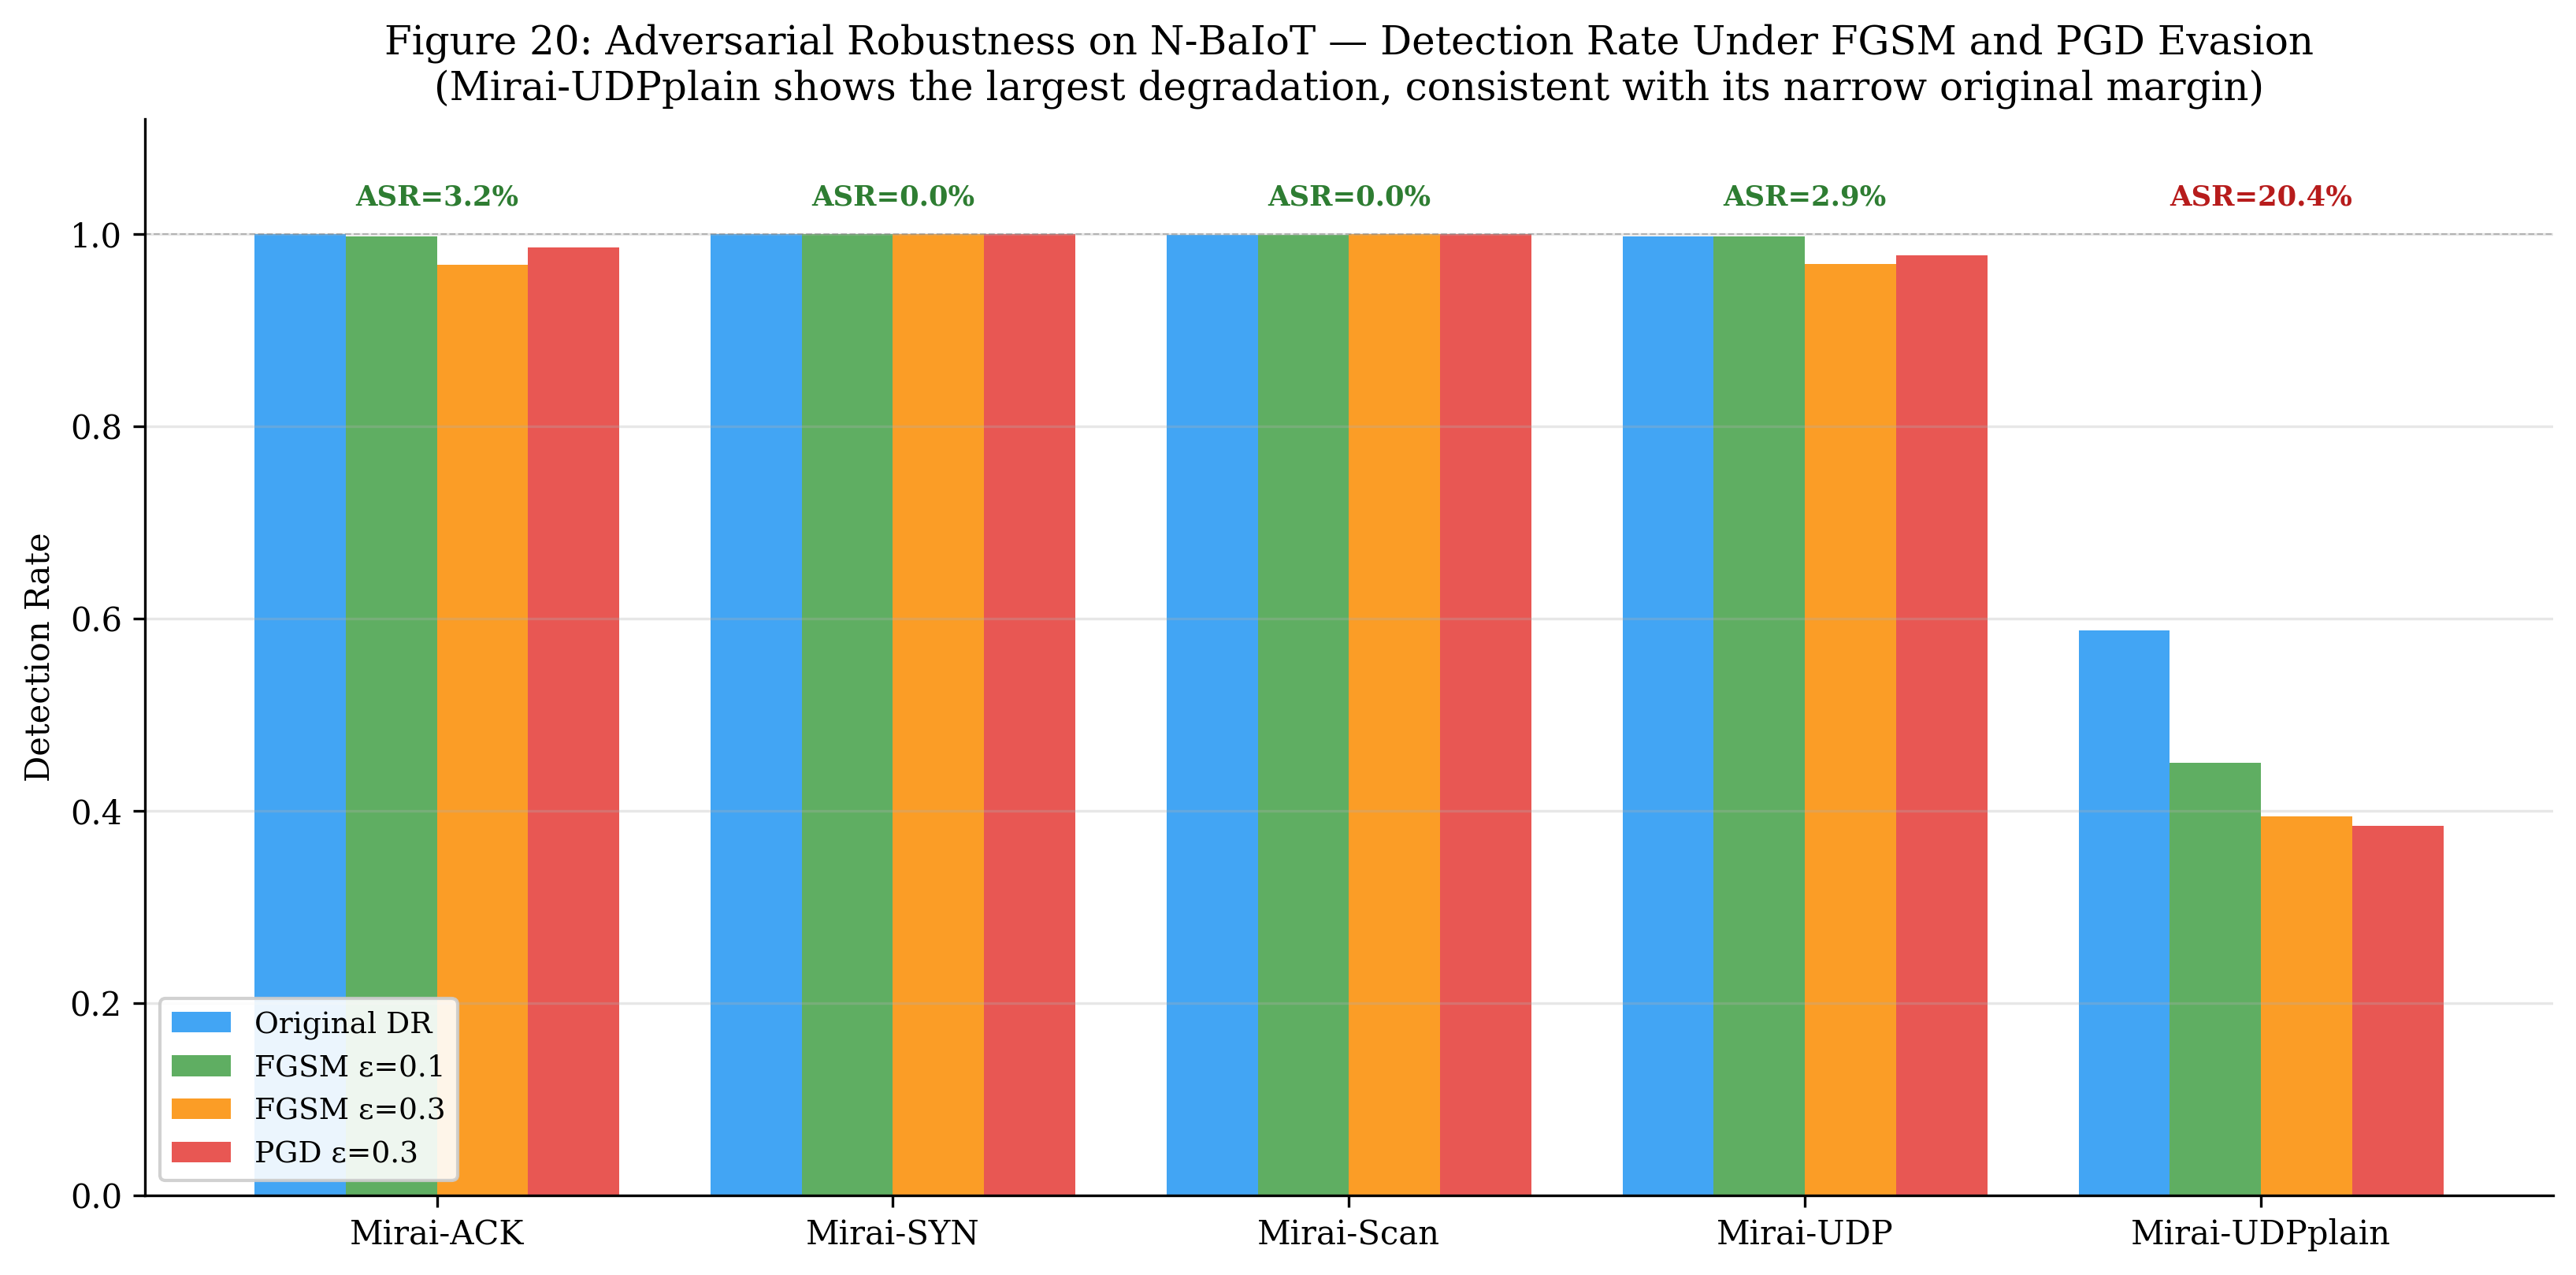

In [ ]:
import os
os.chdir('/content/drive/MyDrive/Colab/nbaiot')

import json
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# আগের রান থেকে সেভ করা adversarial ফলাফল লোড করুন
with open("nbaiot_adversarial_latency.json") as f:
    data = json.load(f)

adv = data["adversarial_results"]
attack_names = list(adv.keys())

orig_dr   = [adv[a]["orig_dr"]   for a in attack_names]
fgsm_01   = [adv[a]["fgsm_0.1"]  for a in attack_names]
fgsm_03   = [adv[a]["fgsm_0.3"]  for a in attack_names]
pgd_03    = [adv[a]["pgd_0.3"]   for a in attack_names]
asr_vals  = [adv[a]["asr"]       for a in attack_names]

plt.rcParams.update({"font.family":"DejaVu Serif","font.size":10,
                     "savefig.dpi":300,"axes.spines.top":False,"axes.spines.right":False})

fig, ax = plt.subplots(figsize=(11, 5.5))

x = np.arange(len(attack_names))
w = 0.2

colors = {
    "orig": "#2196F3",
    "fgsm01": "#43A047",
    "fgsm03": "#FB8C00",
    "pgd03": "#E53935",
}

bars1 = ax.bar(x - 1.5*w, orig_dr, w, label="Original DR", color=colors["orig"], alpha=0.85)
bars2 = ax.bar(x - 0.5*w, fgsm_01, w, label="FGSM ε=0.1",  color=colors["fgsm01"], alpha=0.85)
bars3 = ax.bar(x + 0.5*w, fgsm_03, w, label="FGSM ε=0.3",  color=colors["fgsm03"], alpha=0.85)
bars4 = ax.bar(x + 1.5*w, pgd_03,  w, label="PGD ε=0.3",   color=colors["pgd03"], alpha=0.85)

# প্রতিটা attack-এর উপরে ASR% annotate করা
for i, asr in enumerate(asr_vals):
    ax.text(x[i], 1.03, f"ASR={asr*100:.1f}%", ha="center", fontsize=8.5,
             color="#B71C1C" if asr > 0.05 else "#2E7D32", fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(attack_names, fontsize=10)
ax.set_ylabel("Detection Rate")
ax.set_ylim([0, 1.12])
ax.set_title("Figure 20: Adversarial Robustness on N-BaIoT — Detection Rate Under FGSM and PGD Evasion\n"
             "(Mirai-UDPplain shows the largest degradation, consistent with its narrow original margin)")
ax.legend(loc="lower left", fontsize=9, frameon=True, framealpha=0.9)
ax.grid(axis="y", alpha=0.3)
ax.axhline(1.0, color="gray", linewidth=0.5, linestyle="--", alpha=0.5)

plt.tight_layout()
os.makedirs("../figures", exist_ok=True)
fig.savefig("../figures/Fig20_nbaiot_adversarial.png", dpi=300, bbox_inches="tight")
fig.savefig("../figures/Fig20_nbaiot_adversarial.pdf", bbox_inches="tight")
plt.close()

print("✓ Fig20 saved to figures/Fig20_nbaiot_adversarial.png (and .pdf)")
print("\nData used:")
for a in attack_names:
    print(f"  {a:15s} Orig={adv[a]['orig_dr']:.4f}  FGSM.1={adv[a]['fgsm_0.1']:.4f}  "
          f"FGSM.3={adv[a]['fgsm_0.3']:.4f}  PGD.3={adv[a]['pgd_0.3']:.4f}  ASR={adv[a]['asr']:.4f}")

from IPython.display import Image, display
display(Image(filename="../figures/Fig20_nbaiot_adversarial.png"))

In [1]:
# Colab-এ একটা cell-এ
!pip show torch numpy pandas scikit-learn joblib

Name: torch
Version: 2.11.0+cpu
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org
Author: 
Author-email: PyTorch Team <packages@pytorch.org>
License: BSD-3-Clause
Location: /usr/local/lib/python3.12/dist-packages
Requires: filelock, fsspec, jinja2, networkx, setuptools, sympy, typing-extensions
Required-by: accelerate, fastai, peft, sentence-transformers, timm, torchdata, torchvision
---
Name: numpy
Version: 2.0.2
Summary: Fundamental package for array computing in Python
Home-page: https://numpy.org
Author: Travis E. Oliphant et al.
Author-email: 
License: Copyright (c) 2005-2024, NumPy Developers.
All rights reserved.

Redistribution and use in source and binary forms, with or without
modification, are permitted provided that the following conditions are
met:

    * Redistributions of source code must retain the above copyright
       notice, this list of conditions and the following disclaimer.

    * Redistributions i